# Projet de Machine Learning 

In [109]:
# Chargement des librairies nécessaires
library(ggplot2)      # Création de graphiques
library(tidyverse)    # Ensemble de packages pour manipuler, nettoyer et visualiser les données (inclut ggplot2, dplyr, tidyr...)
library(gridExtra)    # Permet d'afficher plusieurs graphiques sur une même page 
library(GGally)       # Extension de ggplot2 pour explorer les relations entre variables (ex : matrices de graphiques avec ggpairs)
library(plotly)       # Transformation de graphiques en versions interactives (zoom, survol, 3D)
library(corrplot)     # Visualisation des matrices de corrélation entre variables
library(reshape2)     # Transformation des données (format large ↔ format long)
library(FactoMineR)   # Réalisation d’analyses multivariées (ACP, AFC, clustering...)
library(factoextra)   # Visualisation des résultats des analyses faites avec FactoMineR
library(glmnet)       # Modèles de régression avec régularisation (Lasso, Ridge)
library(ggfortify)    # Visualisation simplifiée des modèles statistiques avec ggplot2
library(pROC)         # Calcul et tracé des courbes ROC + AUC pour évaluer un modèle
library(ROCR)         # Évaluation des performances de modèles de classification (ROC, précision, rappel...)
library(e1071)        # SVM
library(caret)        # SVM deuxieme option
library(MASS)         # Analyse discriminante
library(class)        # kNN
library(rpart)        # Arbres de décision
library(rpart.plot)   # Visualisation des arbres de décision créés avec rpart
library(partykit)     # Arbres de décision alternatifs à rpart
library(gbm)          # Gradient Boosting Machine
library(randomForest) # Forêts aléatoires

library(nnet)

In [2]:
# Pour installer les packages si besoin

#install.packages("ggplot2")
#install.packages("tidyverse")
#install.packages("gridExtra")
#install.packages("GGally")

#install.packages("corrpolt")

#install.packages("FactoMineR")
#install.packages("factoextra")


#install.packages("MASS")
#install.packages("dplyr")

#install.packages("stats")
#install.packages("graphics")
#install.packages("pROC")







#packages <- c("ggplot2","tidyverse","gridExtra","GGally","plotly","corrplot","reshape2","FactoMineR","factoextra","glmnet","ggfortify","pROC","ROCR")

# 1. Introduction


## Présentation du jeu de données 


Dans ce projet, nous nous intéressons à un jeu de données synthétique comprenant 15 000 dossiers de patients, intégrant des variables démographiques, physiologiques et comportementales (âge, IMC, pression artérielle, cholestérol, habitudes de vie, etc.). Bien que ces données soient artificielles, elles ont été construites de manière à reproduire des corrélations réalistes observées en pratique médicale.

L’objectif principal est de prédire le risque de maladie cardiovasculaire (Heart_Disease_Risk) à partir de l’ensemble des variables explicatives, en mobilisant différentes méthodes de machine learning. Dans un second temps, nous chercherons également à prédire le taux de cholestérol LDL, indicateur clé du risque cardiovasculaire.

Pour répondre à ces objectifs, nous commencerons par une analyse exploratoire approfondie des données afin de mieux comprendre leur structure et les relations entre variables. Nous comparerons ensuite plusieurs modèles de prédiction, en évaluant leurs performances et leur capacité d’interprétation. Enfin, nous discuterons la cohérence des résultats obtenus au regard de l’analyse descriptive initiale.

Les données sont extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [3]:
# Lecture des données
# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Affiche les premières lignes du jeu de données 
head(data)
# Vérification du contenu
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [4]:
# données "propres", sans trous, bien codées et de petites tailles ?

In [5]:
# Conversion des variables qualitatives en facteur 

data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])

# est ce que on compte stress level en quali ou quanti ? Stress_Level : niveau de stress auto-déclaré : échelle de 1 à 10 ; 

# 2. Analyse exploratoire des données

Étapes descriptives préliminaires uni- et multidimensionnelle visant à repérer les incohérences, les variables non significatives ou de distribution exotique, les individus non concernés ou atypiques... et à étudier les structures des données. Ce peut être aussi la longue étape de construction de variables, attributs ou features spécifiques des données.

### Analyse descriptive unidimensionnelles

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."


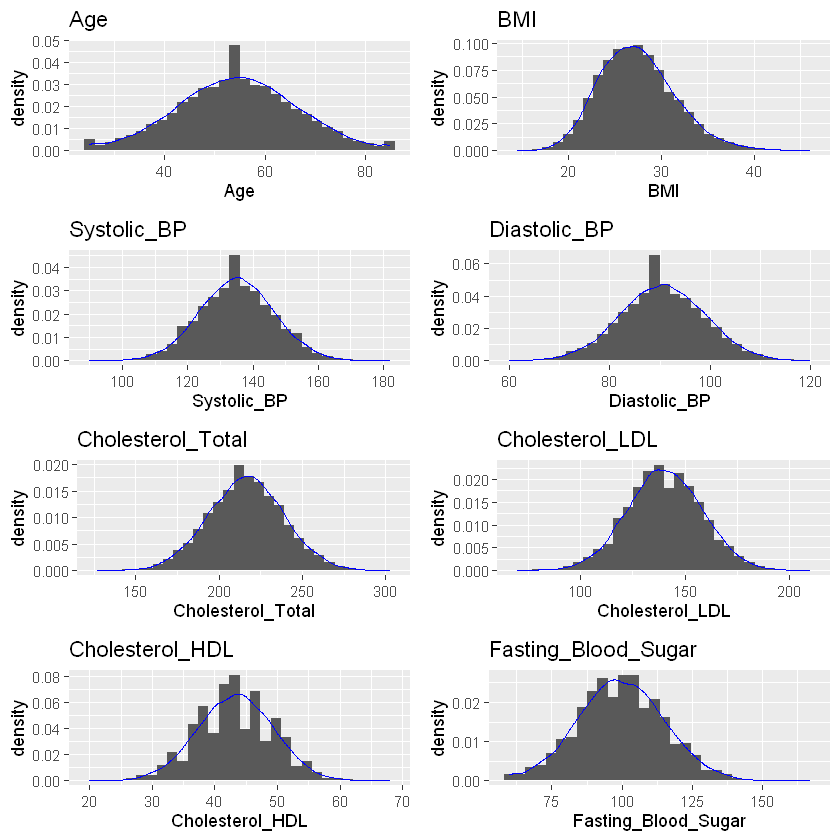

In [6]:
# Histogrammes des variables quantitaives

vars <- c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
          "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
          "Fasting_Blood_Sugar")

plots <- lapply(vars, function(v) {
  ggplot(data, aes_string(x = v)) +
    geom_histogram(aes(y = after_stat(density)), bins = 30) +
    geom_density(alpha = .2, col = "blue") +
    ggtitle(v)
})

grid.arrange(grobs = plots, ncol = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe des densités symétriques (donc plutôt gaussiennes) cela sera nécessaire pour certaines méthodes à venir de modélisation (linéaires), mais pas pour toutes (arbres).
</div>

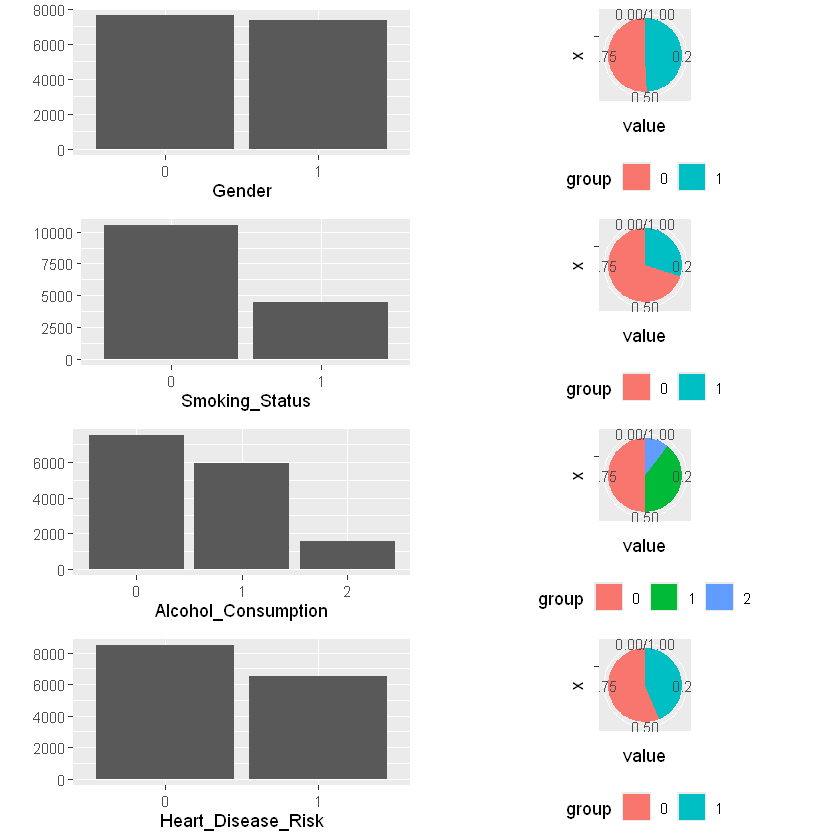

In [7]:
# Statistiques descriptives des variables qualitatives

# Gender
df1 <- data.frame(
  group = levels(as.factor(data$Gender)),
  value = as.vector(table(data$Gender)) / nrow(data)
)

g1 <- ggplot(data, aes(x = Gender)) + 
  geom_bar() +
  ylab("")

g2 <- ggplot(df1, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Smoking_Status
df2 <- data.frame(
  group = levels(as.factor(data$Smoking_Status)),
  value = as.vector(table(data$Smoking_Status)) / nrow(data)
)

g3 <- ggplot(data, aes(x = Smoking_Status)) + 
  geom_bar() +
  ylab("")

g4 <- ggplot(df2, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Alcohol_Consumption
df3 <- data.frame(
  group = levels(as.factor(data$Alcohol_Consumption)),
  value = as.vector(table(data$Alcohol_Consumption)) / nrow(data)
)

g5 <- ggplot(data, aes(x = Alcohol_Consumption)) + 
  geom_bar() +
  ylab("")

g6 <- ggplot(df3, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Heart_Disease_Risk
df4 <- data.frame(
  group = levels(as.factor(data$Heart_Disease_Risk)),
  value = as.vector(table(data$Heart_Disease_Risk)) / nrow(data)
)

g7 <- ggplot(data, aes(x = Heart_Disease_Risk)) + 
  geom_bar() +
  ylab("")

g8 <- ggplot(df4, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Affichage
grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, ncol = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La variable genre est équilibrée mais les variables Alcohol_Consumption et Smoking_Status sont fortement déséquilibrées. La variable Heart_Disease_Risk est ??? 
</div>

### Analyse descriptive bidimensionnelles


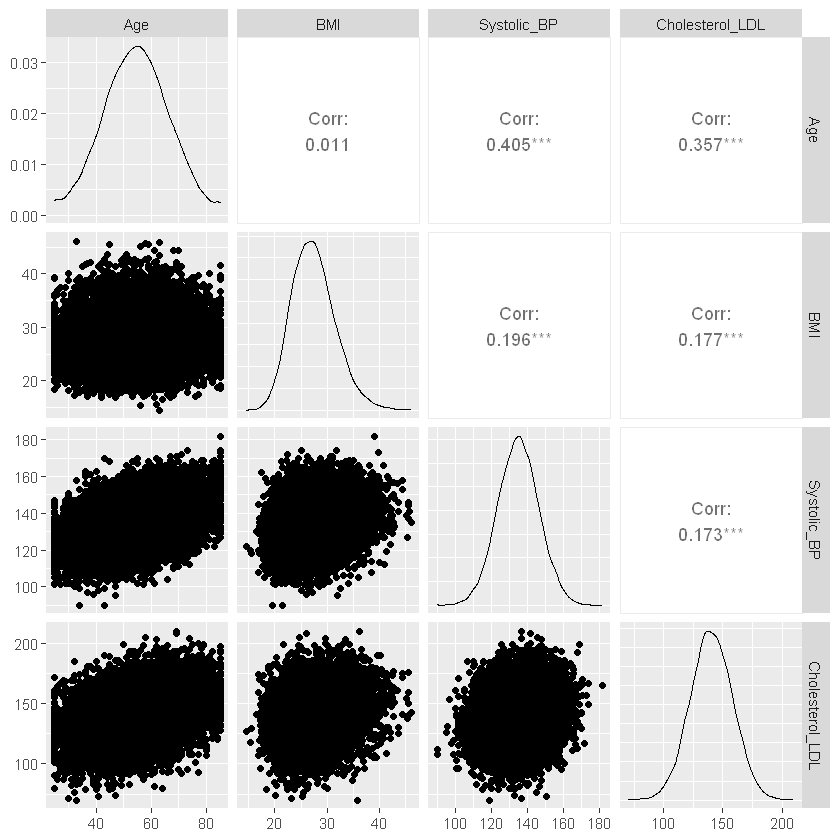

In [8]:
# Corrélations des variables quantitatives

ggpairs(data[, c("Age", "BMI", "Systolic_BP", "Cholesterol_LDL")])

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La plus forte corrélation observée est entre l'âge et la pression artérielle systolique (Systolic_BP), puis entre l'âge et la quantité de lipoprotéines de basse densité "mauvais cholestérol (Cholesterol_LDL).
</div>

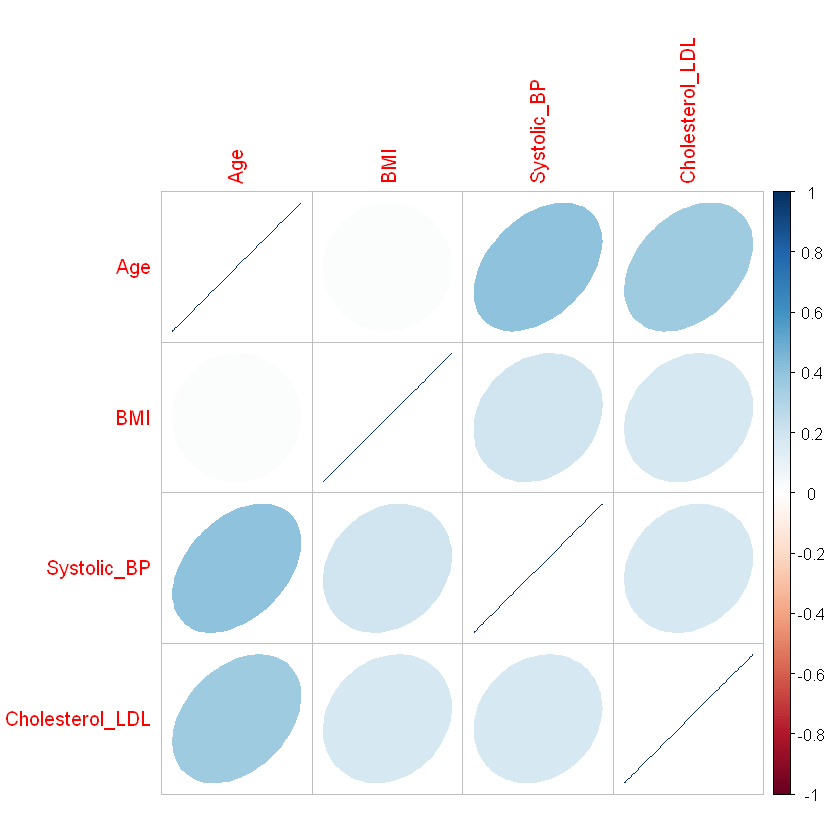

In [9]:
# On fait la même chose avec corrplot pour comparer

corrplot(cor(data[, c("Age", "BMI", "Systolic_BP", "Cholesterol_LDL")]),method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Attention, ici on ne mesure que des corrélations linéaires entre les variables quantitatives. Pour étudier la corrélation entre les variables quantitatives et qualitatives il faut calculer le coefficient "éta carré".
</div>

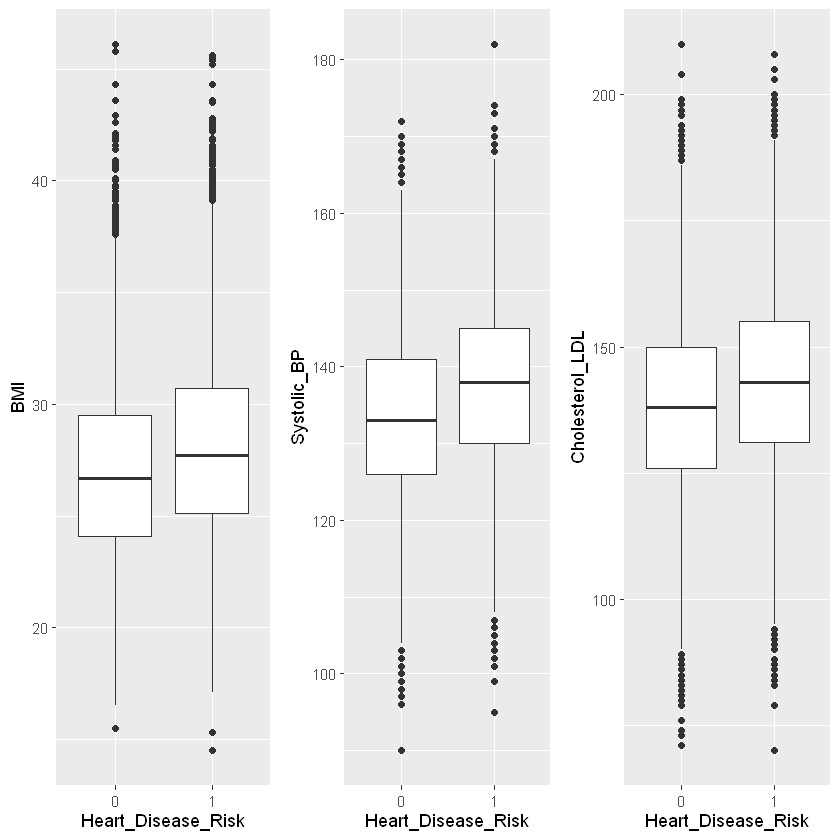

In [10]:
# Analyse bidimensionnelle des variables quantitatives et qualitatives

g1 <- ggplot(data, aes(x = Heart_Disease_Risk, y = BMI)) +
  geom_boxplot()

g2 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Systolic_BP)) +
  geom_boxplot()

g3 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_LDL)) +
  geom_boxplot()

grid.arrange(g1, g2, g3, ncol = 3)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Ici on regarde le risque d’accident cardiaque en fonction de 3 variables : l'indice de masse corporelle (BMI), la pression artérielle systolique (Systolic_BP) et la quantité de lipoprotéines de basse densité "mauvais cholestérol" (Cholesterol_LDL). On observe pas de forte corrélation avec l'une de ces variables.
</div>

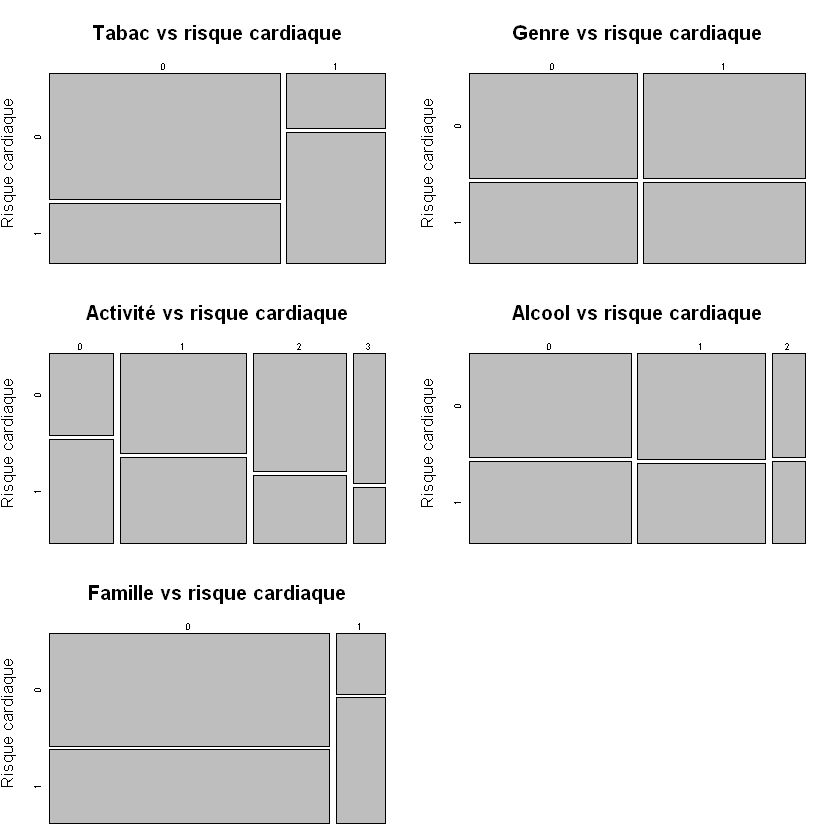

In [11]:
# Mettre 2 lignes et 3 colonnes pour afficher plusieurs plots sur une seule fenêtre
par(mfrow = c(3, 2), mar = c(1, 2, 4, 1), cex.axis = 1.2, cex.lab = 1.3, cex.main = 1.5) # 'mar' ajuste les marges pour que ce soit plus compact

# Mosaic plots
mosaicplot(
  table(data$Smoking_Status, data$Heart_Disease_Risk),
  xlab = "Statut tabagisme",
  ylab = "Risque cardiaque",
  main = "Tabac vs risque cardiaque"
)

mosaicplot(
  table(data$Gender, data$Heart_Disease_Risk),
  xlab = "Genre",
  ylab = "Risque cardiaque",
  main = "Genre vs risque cardiaque"
)

mosaicplot(
  table(data$Physical_Activity_Level, data$Heart_Disease_Risk),
  xlab = "Activité physique",
  ylab = "Risque cardiaque",
  main = "Activité vs risque cardiaque"
)

mosaicplot(
  table(data$Alcohol_Consumption, data$Heart_Disease_Risk),
  xlab = "Consommation alcool",
  ylab = "Risque cardiaque",
  main = "Alcool vs risque cardiaque"
)

mosaicplot(
  table(data$Family_History, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Famille vs risque cardiaque"
)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe que les non-fumeurs ont majoritairement un faible risque cardiaque, tandis que les fumeurs présentent une proportion plus grande de risque élevé, ce qui est cohérent avec les effets connus du tabac sur la santé cardiovasculaire. La variable décrivant l'histoire familiale se comporte de la même façon : les personnes ayant des antécédents familiaux de maladie cardiaque présentent une proportion plus grande de risque élevé.
    Le genre et la consommation d'alcool ne semblent pas corrélés au risque cardiaque. 
    Le niveau d'activité physique semble corrélé linéairement au risuqe cardiaque.  
</div>

### ACP

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


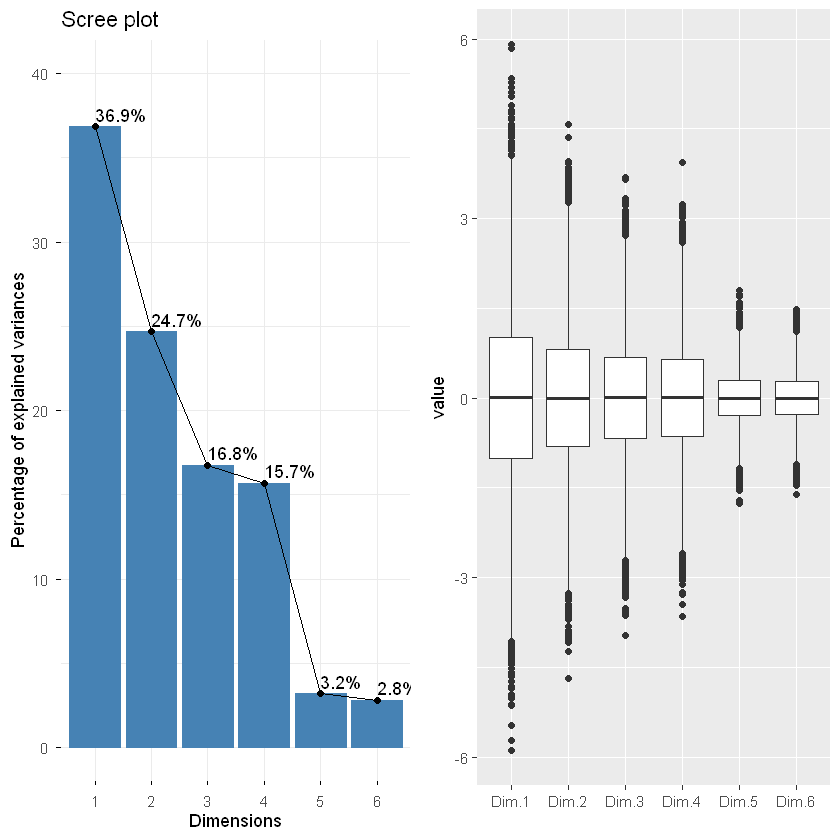

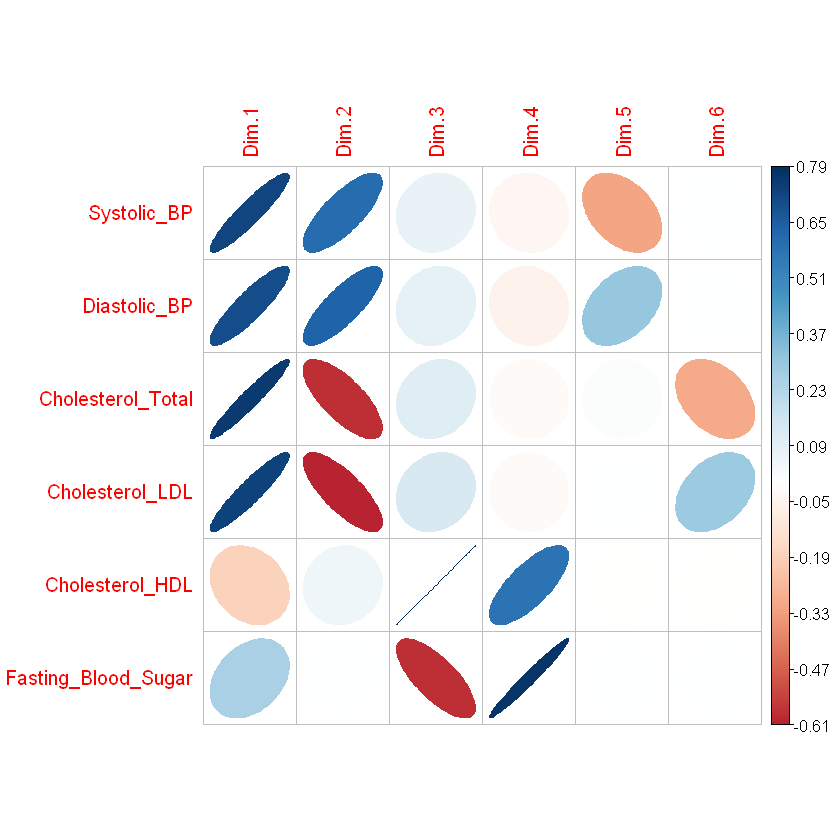

In [12]:
# ACP sur les variables quantitatives. Par ailleurs la variable à modéliser (Heart_Disease_Risk) n'est pas utilisée.

acp <- PCA(data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
          "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
          "Fasting_Blood_Sugar")], scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
library(factoextra)
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
library(reshape2)
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  Ici la première composante principale représente 36.9% des données. D'après le coude observé sur le premier garphe on pourrait garder 2 ou 4 dimensions. Les 4 variables : "Systolic_BP", "Diastolic_BP", "Cholesterol_Total" et "Cholesterol_LDL" semblent fortement corrélées à la dimension 1. 
</div>

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>."


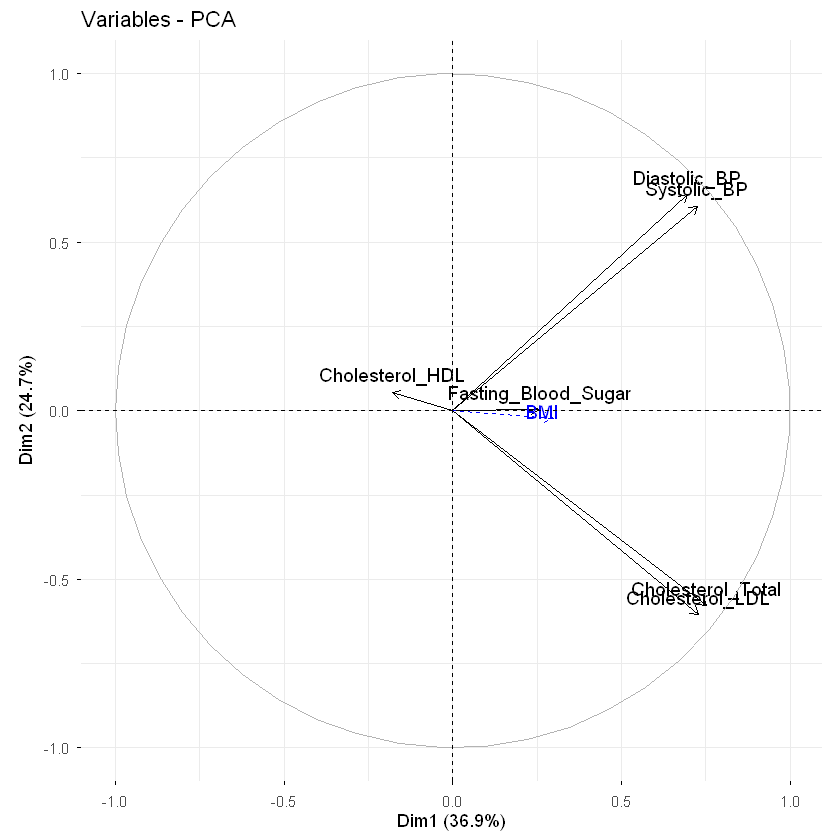

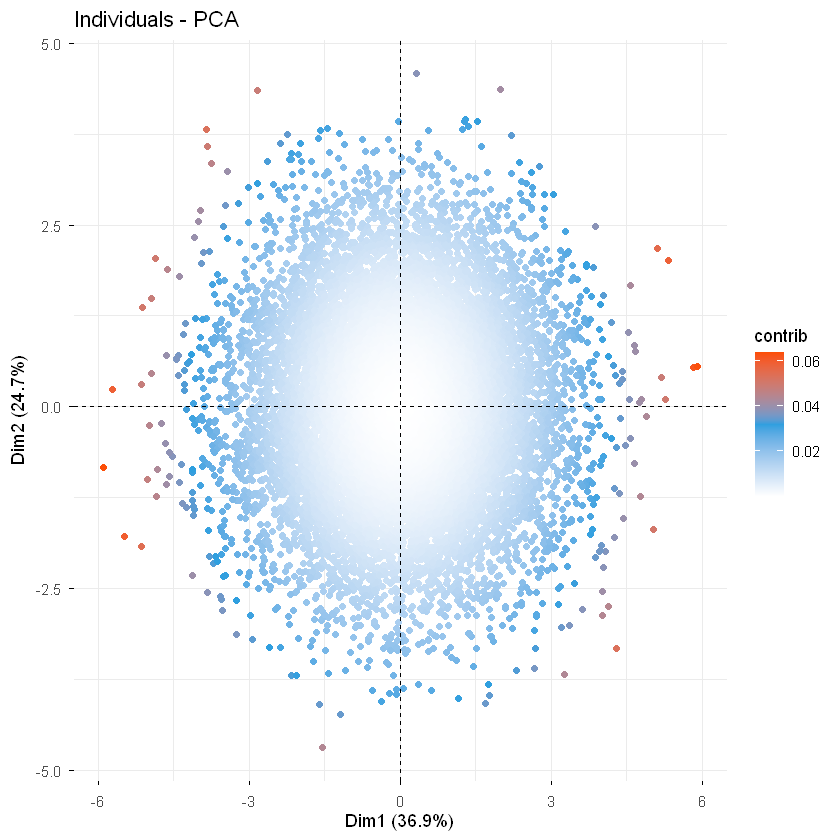

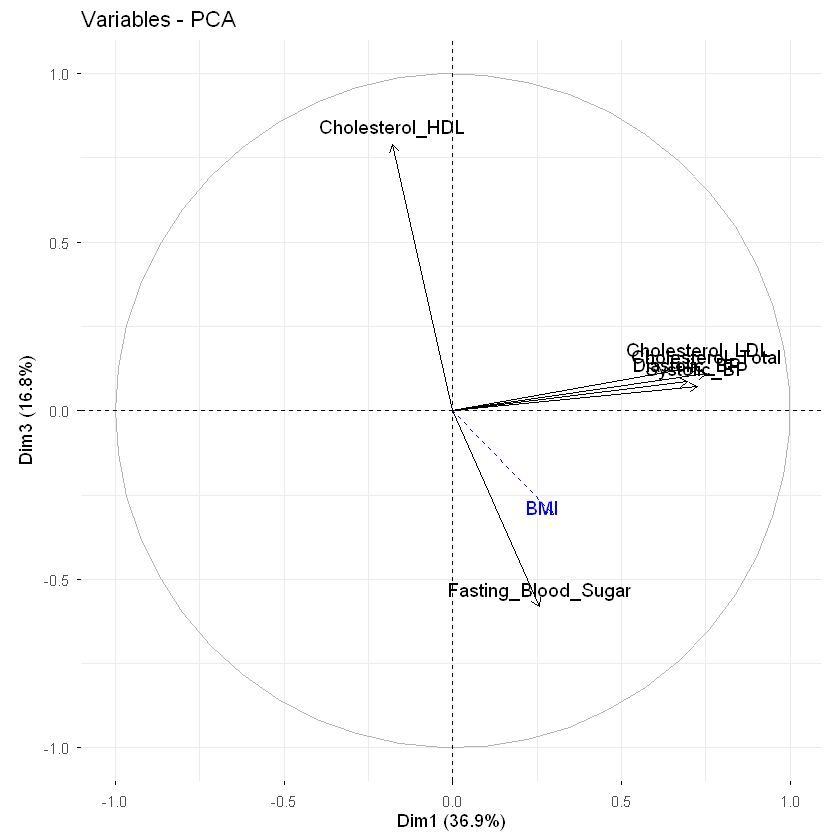

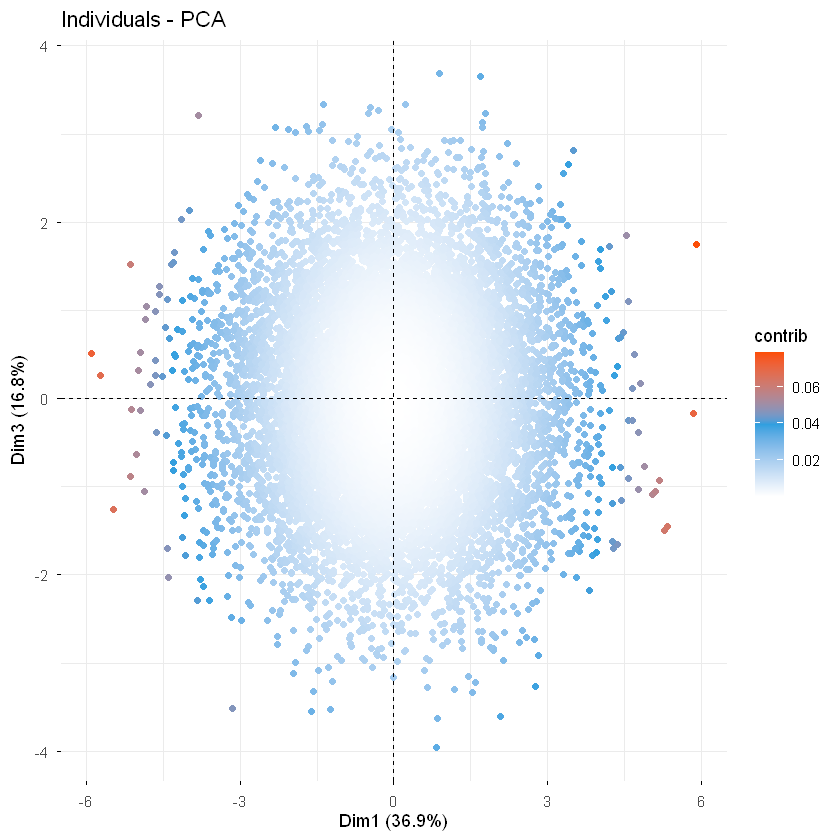

In [13]:
fviz_pca_var(acp)
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
fviz_pca_var(acp,axes=c(1,3))
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

<div style="border-left:5px solid orange; padding:15px; background-color:#fff8e1; border-radius:5px; font-family:Arial, sans-serif; line-height:1.6;">
  <strong>Interprétation :</strong><br><br>

  <em>Premier graphe (dim 1 et dim 2) :</em><br>
  - <strong>Systolic_BP</strong> et <strong>Diastolic_BP</strong> sont fortement corrélées.<br>
  - <strong>Cholesterol_Total</strong> et <strong>Cholesterol_LDL</strong> sont corrélés positivement.<br>
  - <strong>Cholesterol_HDL</strong> et <strong>BMI</strong> sont corrélés négativement.<br>
  - <strong>Fasting_Blood_Sugar</strong> et <strong>BMI</strong> présentent une légère corrélation positive.<br><br>

  <em>Deuxième graphe (dim 2 et dim 3) :</em><br>
  - À part <strong>BMI</strong>, <strong>Fasting_Blood_Sugar</strong> et <strong>Cholesterol_HDL</strong>, les variables sont fortement corrélées entre elles.
</div>

### Clustering

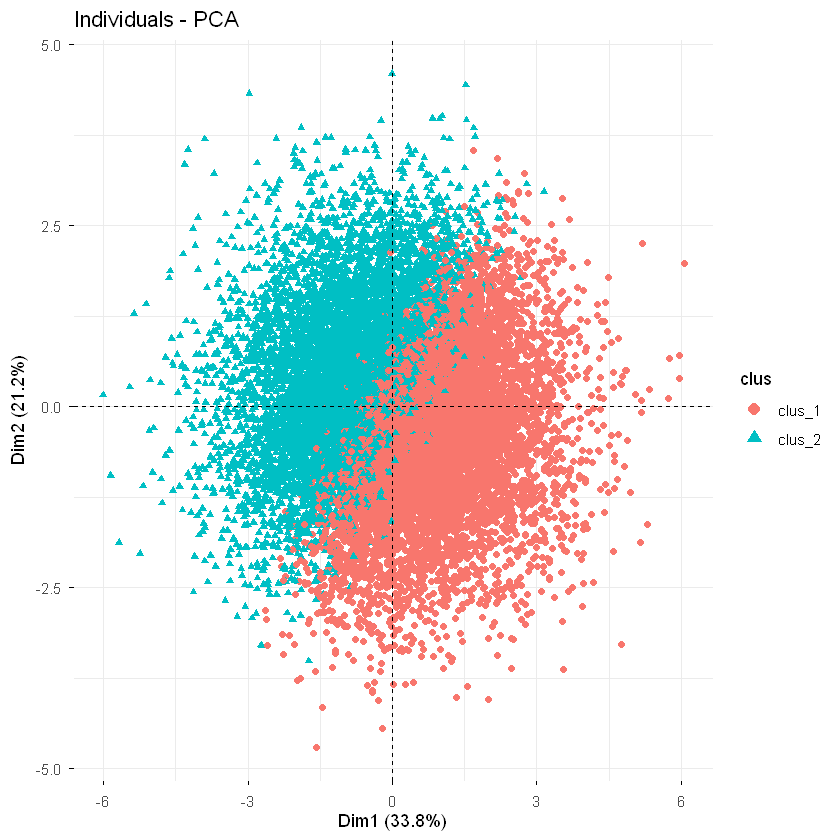

In [14]:
km.data <- kmeans(data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP","Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL", "Fasting_Blood_Sugar")],
  centers = 2)
# Représentation dans les coordonnées de l'acp
acp2 <- PCA(cbind(clus = as.factor(km.data$cluster),
          data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
                 "Cholesterol_Total", "Cholesterol_LDL",
                 "Cholesterol_HDL", "Fasting_Blood_Sugar")]), scale.unit = TRUE,
          graph = FALSE, quali.sup = 1:2, ncp = 7)
fviz_pca_ind(acp2, label="none", habillage="clus")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  
</div>

# 3. Prédiction du risque d’accident cardiaque : variable Heart_Disease_Risk

###  3.0 Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pour évaluer correctement un modèle, on divise le jeu de données en échantillon d’apprentissage (80%) et échantillon test (20%). L’échantillon d’apprentissage sert à entraîner le modèle, tandis que l’échantillon test permet de mesurer ses performances sur des données jamais vues. Cette étape est nécessaire pour éviter le surapprentissage et obtenir une estimation réaliste de la capacité du modèle à généraliser à de nouvelles données.

In [15]:
set.seed(111) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
testi <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appri <- setdiff(1:npop, testi) 

Construction des échantillons pour la régression: prévision du risque d’accident cardiaque "Heart_Disease_Risk".

In [ ]:
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -which(names(data) %in% c("Heart_Disease_Risk", "Patient_ID"))] # on retire la colonne "Heart_Disease_Risk"

# construction de l'échantillon test
datestr0 <- data[testi, -which(names(data) %in% c("Heart_Disease_Risk", "Patient_ID"))] 

# on récupère la variable cible 
y_train <- data$Heart_Disease_Risk[appri]
y_test  <- data$Heart_Disease_Risk[testi] 

# vérification
# str(datappr0)
# str(datestr0)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])

# on normalise l'échantillon test à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# Encoder les var quali
X_train <- as.data.frame(model.matrix(~ ., data = datappr)[, -1])
X_test  <- as.data.frame(model.matrix(~ ., data = datestr)[, -1])

# vérification
str(datappr)
str(datestr)

'data.frame':	12000 obs. of  17 variables:
 $ Age                    : num  0.455 -0.13 0.622 1.541 -0.214 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  -2.006 -0.384 1.021 0.868 -0.623 ...
 $ Weight_kg              : num  -1.701 0.104 1.232 -0.445 -1.059 ...
 $ BMI                    : num  -0.882 0.463 0.707 -1.103 -0.907 ...
 $ Systolic_BP            : num  0.4318 -0.6293 0.5202 0.0781 -0.0987 ...
 $ Diastolic_BP           : num  -0.181 -1.125 1.118 0.646 0.173 ...
 $ Cholesterol_Total      : num  0.034 -0.583 -1.904 -1.023 0.386 ...
 $ Cholesterol_LDL        : num  0.593 -1.189 -0.911 -1.301 0.815 ...
 $ Cholesterol_HDL        : num  1.461 -0.889 0.286 0.286 0.789 ...
 $ Fasting_Blood_Sugar    : num  -1.094 1.074 -0.634 -1.226 0.22 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Act

In [76]:
# construction de l'échantillon d'apprentissage
datappq0 <- data[appri, -which(names(data) %in% c("Patient_ID"))]

# construction de l'échantillon test
datestq0 <- data[testi, -which(names(data) %in% c("Patient_ID"))] 

# vérification
str(datappq0)
str(datestq0)

# on identifie les colonnes numériques
num_cols <- sapply(datappq0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappq <- datappq0
datappq[, num_cols] <- scale(datappq0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestq <- datestq0
datestq[, num_cols] <- scale(
  datestq0[, num_cols],
  center = sapply(datappq0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappq0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
summary(datappq)
summary(datestq)

'data.frame':	12000 obs. of  18 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  217 203 173 193 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $

      Age           Gender     Height_cm          Weight_kg       
 Min.   :-2.46911   0:6083   Min.   :-2.91995   Min.   :-2.95670  
 1st Qu.:-0.71488   1:5917   1st Qu.:-0.74279   1st Qu.:-0.71629  
 Median : 0.03694            Median :-0.06788   Median :-0.09554  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.70522            3rd Qu.: 0.73767   3rd Qu.: 0.61796  
 Max.   : 2.54298            Max.   : 3.53532   Max.   : 5.34851  
      BMI           Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504   Min.   :-3.70977  
 1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311   1st Qu.:-0.67073  
 Median :-0.0753   Median :-0.01033   Median : 0.05535   Median : 0.03397  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573   3rd Qu.: 0.69463  
 Max.   : 4.4984   Max.   : 4.14536   Max.   : 3.47959   Max.   : 3.73367  

      Age            Gender     Height_cm           Weight_kg       
 Min.   :-2.469112   0:1539   Min.   :-2.919954   Min.   :-2.52147  
 1st Qu.:-0.631343   1:1461   1st Qu.:-0.742795   1st Qu.:-0.70202  
 Median :-0.046599            Median :-0.067876   Median :-0.05987  
 Mean   :-0.008228            Mean   : 0.007207   Mean   : 0.04050  
 3rd Qu.: 0.621681            3rd Qu.: 0.715902   3rd Qu.: 0.66791  
 Max.   : 2.542985            Max.   : 3.567980   Max.   : 4.54939  
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total  
 Min.   :-2.59448   Min.   :-3.547092   Min.   :-3.132733   Min.   :-3.929990  
 1st Qu.:-0.71121   1st Qu.:-0.629264   1st Qu.:-0.653114   1st Qu.:-0.670732  
 Median :-0.05084   Median :-0.010330   Median :-0.003690   Median :-0.010071  
 Mean   : 0.04674   Mean   : 0.000368   Mean   : 0.005914   Mean   : 0.004258  
 3rd Qu.: 0.65845   3rd Qu.: 0.697022   3rd Qu.: 0.645734   3rd Qu.: 0.650589  
 Max.   : 4.57174   Max.   : 2.995917

In [17]:
# code pour trouver les variables numeric mais inutile 
# str(datappr0)  # regarde le type de chaque colonne
# sapply(datappr0, class)  # renvoie le type

In [23]:
#Enfin, avant de passer aux différents algorithmes, définissons une fonction traçant le graphe des résidus avec des couleurs et des échelles fixes sur les axes.
#c'était dans le TP à voir si c'est utile

gplot.res <- function(x, y, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(0, 250)+ylim(-155, 155)+
    ylab("Résidus")+ xlab("Valeurs prédites")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

consigne : Comparez les performances d’un modèle linéaire (éventuellement généralisé) avec/sans sélection de vari
ables, avec/sans pénalisation, d’un SVR/SVM, d’un arbre optimal, d’une forêt aléatoire, du boosting,
et de réseaux de neurones. Justifiez vos choix (par exemple le noyau pour le SVR/SVM), identifiez les
hyperparamètres de chaque modèle et ajustez-les soigneusement (par validation croisée). Interprétez les
résultats et quantifiez l’amélioration éventuelle apportée par les modèles non linéaires.

### 3.1 Prévisions par modèles linéaires généralisés

Cette section compare plusieurs approches de régression logistique :
 - Modèle complet (toutes les variables)
 - Sélection de variables par stepwise (critères AIC et BIC)
 - Pénalisation Ridge (alpha = 0)
 - Pénalisation Lasso (alpha = 1)
 - Pénalisation Elastic Net (alpha = 0.5)
   

In [24]:
train_df <- data.frame(datappr, Heart_Disease_Risk = y_train)
test_df  <- data.frame(datestr, Heart_Disease_Risk = y_test)

#### 3.1.1 Régression Logistique Complète 

La régression logistique (GLM avec lien logit) modélise la probabilité d'appartenir à la classe 1 (risque élevé) en fonction de toutes les variables explicatives. C'est le modèle de référence (notre baseline).
On utilise toutes les variables sans sélection ni pénalisation.

In [26]:
# estimation du modèle complet
set.seed(111)
log.lm <- glm(Heart_Disease_Risk ~ ., data = train_df, family = binomial)
 
# significativité des paramètres
anova(log.lm, test = "Chisq")
 
# résumé des coefficients
summary(log.lm)

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,3.539542e+02,11998,16098.58,5.835412e-79
Gender,1,6.280797e-02,11997,16098.52,8.021116e-01
Height_cm,1,4.706908e+00,11996,16093.81,3.004164e-02
Weight_kg,1,1.950638e+02,11995,15898.75,2.495108e-44
BMI,1,9.667457e-01,11994,15897.78,3.254931e-01
Systolic_BP,1,1.579788e+02,11993,15739.80,3.127980e-36
Diastolic_BP,1,3.286212e-01,11992,15739.47,5.664721e-01
Cholesterol_Total,1,2.488697e+01,11991,15714.58,6.079200e-07



Call:
glm(formula = Heart_Disease_Risk ~ ., family = binomial, data = train_df)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.38078    0.06236  -6.106 1.02e-09 ***
Age                       0.24163    0.02653   9.107  < 2e-16 ***
Gender1                  -0.11720    0.06514  -1.799    0.072 .  
Height_cm                -0.03494    0.14603  -0.239    0.811    
Weight_kg                 0.17387    0.23754   0.732    0.464    
BMI                       0.04635    0.19151   0.242    0.809    
Systolic_BP               0.35188    0.03864   9.106  < 2e-16 ***
Diastolic_BP             -0.02222    0.03683  -0.603    0.546    
Cholesterol_Total        -0.04648    0.04074  -1.141    0.254    
Cholesterol_LDL           0.22559    0.03922   5.752 8.80e-09 ***
Cholesterol_HDL          -0.02160    0.02590  -0.834    0.404    
Fasting_Blood_Sugar       0.31628    0.02282  13.862  < 2e-16 ***
Smoking_Status1           1.99069    0.05027  

Interprétation : Le test du Chi² confirme que la majorité des variables contribuent significativement à réduire la déviance du modèle. Les variables les plus importantes sont Smoking_Status (réduction de 1644), Family_History (633), Physical_Activity_Level (385) et Stress_Level (191). En revanche, Gender, BMI, Diastolic_BP et Cholesterol_HDL ont des p-values largement supérieures à 0.05 et n'apportent pas d'information significative, ce qui motive la sélection de variables.

La déviance résiduelle (12655) est nettement inférieure à la déviance nulle (16453), confirmant que le modèle apporte une information réelle par rapport à un classifieur trivial.

In [27]:
# matrice de confusion sur l'échantillon d'apprentissage (erreur apparente)
table(log.lm$fitted.values > 0.5, train_df$Heart_Disease_Risk)

       
           0    1
  FALSE 5463 1865
  TRUE  1277 3395

In [28]:
# accuracy et AUC sur le test
pred.lm <- predict(log.lm, newdata = test_df, type = "response")
table(pred.lm > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy :", round(mean((pred.lm > 0.5) == (as.numeric(as.character(y_test)) == 1)), 4))
roc.lm <- roc(test_df$Heart_Disease_Risk, pred.lm, quiet = TRUE)
paste("AUC :", round(auc(roc.lm), 4))

       
           0    1
  FALSE 1383  428
  TRUE   337  852

[1] "Accuracy : 0.745"

[1] "AUC : 0.8084"

Interprétation : 

Le modèle logistique complet, entraîné sur l'ensemble des variables explicatives, obtient une accuracy de 0.745 et une AUC de 0.808 sur l'échantillon test, c'est notre baseline de référence. La déviance résiduelle (12655) nettement inférieure à la déviance nulle (16453) confirme que le modèle apporte une information réelle par rapport à un classifieur trivial. L'absence d'écart significatif entre les performances train et test indique qu'il n'y a pas de surapprentissage.

L'examen des coefficients et du test du Chi² permettent d'identifier les variables les plus influentes. Plusieurs ressortent comme significativement associées au risque cardiaque (p < 0.001) : **l'âge, la pression artérielle systolique, la glycémie à jeun, le tabagisme, le cholestérol LDL, le niveau d'activité physique, les antécédents familiaux, le niveau de stress et le nombre d'heures de sommeil**. Ces résultats sont cohérents avec les connaissances médicales et confirment les tendances observées lors de l'analyse exploratoire. Notons en particulier que **Smoking_Status** est de loin la variable qui réduit le plus la déviance (1644), suivie de **Family_History** (633).


En revanche, **Gender, BMI, Diastolic_BP, Cholesterol_HDL, Cholesterol_Total, Alcohol_Consumption, Height_cm et Weight_kg** s'avèrent non significatifs (p > 0.05). Leur présence n'apporte pas d'information discriminante supplémentaire, ce qui motive l'étape suivante de sélection de variables.

#### 3.1.2 Séléction de Variables par Stepwise (AIC et BIC)

Le stepwise part du modèle complet et ajoute/retire des variables une à une en minimisant le critère AIC (ou BIC). On compare les deux critères :
 - AIC (Akaike) : pénalisation plus légère → tend à garder plus de variables
 - BIC (Bayesian) : pénalisation plus forte → modèle plus parcimonieux

Obj : un modèle avec moins de variables mais performances similaires est préférable pour le principe de parcimonie / rasoir d'Occam. 

In [29]:
# Stepwise AIC : 
# part du modèle complet, direction both = ajoute et retire des variables
# minimise le critère AIC (k=2) : pénalisation légère
set.seed(111)
log.lm.step.aic <- step(log.lm, direction = "both", trace = FALSE)


# variables retenues et leur significativité
anova(log.lm.step.aic, test = "Chisq")
cat("Variables retenues AIC :", paste(names(coef(log.lm.step.aic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(log.lm.step.aic)) - 1, "\n")

# erreur apparente (train)
table(log.lm.step.aic$fitted.values > 0.5, train_df$Heart_Disease_Risk)

# accuracy et AUC sur le test
pred.step.aic <- predict(log.lm.step.aic, newdata = test_df, type = "response")
table(pred.step.aic > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy AIC :", round(mean((pred.step.aic > 0.5) == (as.numeric(as.character(y_test)) == 1)), 4))
paste("AUC AIC      :", round(auc(roc(test_df$Heart_Disease_Risk, pred.step.aic, quiet = TRUE)), 4))


,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,3.539542e+02,11998,16098.58,5.835412e-79
Gender,1,6.280797e-02,11997,16098.52,8.021116e-01
Height_cm,1,4.706908e+00,11996,16093.81,3.004164e-02
Weight_kg,1,1.950638e+02,11995,15898.75,2.495108e-44
Systolic_BP,1,1.585337e+02,11994,15740.21,2.366047e-36
Cholesterol_LDL,1,5.152876e+01,11993,15688.68,7.055576e-13
Fasting_Blood_Sugar,1,1.562559e+02,11992,15532.43,7.443090e-36
Smoking_Status,1,1.644649e+03,11991,13887.78,0.000000e+00


Variables retenues AIC : Age, Gender1, Height_cm, Weight_kg, Systolic_BP, Cholesterol_LDL, Fasting_Blood_Sugar, Smoking_Status1, Physical_Activity_Level1, Physical_Activity_Level2, Physical_Activity_Level3, Family_History1, Stress_Level, Sleep_Hours 
Nombre de variables    : 14 


       
           0    1
  FALSE 5453 1864
  TRUE  1287 3396

       
           0    1
  FALSE 1384  429
  TRUE   336  851

[1] "Accuracy AIC : 0.745"

[1] "AUC AIC      : 0.8082"

Interprétation : 

Le stepwise AIC retient 14 variables et élimine **BMI, Diastolic_BP, Cholesterol_Total, Cholesterol_HDL et Alcohol_Consumption** toutes non significatives dans le modèle complet. Toutes les variables retenues sont significatives au seuil 0.05 selon l'anova. Les performances sont quasi identiques au modèle complet : **accuracy 0.745, AUC 0.8082**, avec des résultats train/test stables confirmant l'absence de surapprentissage.

In [30]:
# Stepwise BIC : 
# même procédure mais k = log(n) : pénalisation plus forte → modèle plus parcimonieux que AIC
log.lm.step.bic <- step(log.lm, direction = "both",
                         k = log(nrow(train_df)), trace = FALSE)

anova(log.lm.step.bic, test = "Chisq")
cat("Variables retenues BIC :", paste(names(coef(log.lm.step.bic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(log.lm.step.bic)) - 1, "\n")

# erreur apparente (train)
table(log.lm.step.bic$fitted.values > 0.5, train_df$Heart_Disease_Risk)

# accuracy et AUC sur le test
pred.step.bic <- predict(log.lm.step.bic, newdata = test_df, type = "response")
table(pred.step.bic > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy BIC :", round(mean((pred.step.bic > 0.5) == (as.numeric(as.character(y_test)) == 1)), 4))
paste("AUC BIC      :", round(auc(roc(test_df$Heart_Disease_Risk, pred.step.bic, quiet = TRUE)), 4))

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,353.954194,11998,16098.58,5.835412e-79
Height_cm,1,1.844362,11997,16096.73,1.744405e-01
Weight_kg,1,195.181271,11996,15901.55,2.352065e-44
Systolic_BP,1,159.049768,11995,15742.50,1.825014e-36
Cholesterol_LDL,1,51.274355,11994,15691.23,8.031805e-13
Fasting_Blood_Sugar,1,156.425786,11993,15534.80,6.833209e-36
Smoking_Status,1,1645.541360,11992,13889.26,0.000000e+00
Physical_Activity_Level,3,385.249691,11989,13504.01,3.467581e-83


Variables retenues BIC : Age, Height_cm, Weight_kg, Systolic_BP, Cholesterol_LDL, Fasting_Blood_Sugar, Smoking_Status1, Physical_Activity_Level1, Physical_Activity_Level2, Physical_Activity_Level3, Family_History1, Stress_Level, Sleep_Hours 
Nombre de variables    : 13 


       
           0    1
  FALSE 5461 1859
  TRUE  1279 3401

       
           0    1
  FALSE 1383  432
  TRUE   337  848

[1] "Accuracy BIC : 0.7437"

[1] "AUC BIC      : 0.8089"

Interprétation : 

Le BIC, avec sa pénalisation plus forte, va plus loin et retire également **Gender**, don un modèle à 13 variables. Les performances restent stables : **accuracy 0.7437, AUC 0.8089**. L'AUC est même légèrement supérieure au modèle complet.

CONCLUSION: 

Les deux critères convergent vers le même constat : supprimer 4 à 5 variables non informatives ne dégrade pas les performances. Le BIC, plus parcimonieux avec 13 variables, donne même la meilleure AUC (0.8089). C'est l'illustration du principe de parcimonie : un modèle plus simple avec des performances équivalentes est préférable car plus interprétable et plus robuste sur de nouvelles données. **Le stepwise BIC sera donc notre modèle de référence parmi les approches sans pénalisation.**

#### 3.1.3 Pénalisation Ridge, Lasse, Elastic Net

Avec glmnet, on pénalise les coefficients pour éviter le surapprentissage et/ou sélectionner automatiquement les variables (Lasso).
Le paramètre alpha contrôle le type de pénalisation :
- alpha = 0   → Ridge    : réduit tous les coefficients vers 0, mais aucun exactement à 0
- alpha = 1   → Lasso    : met certains coefficients exactement à 0 (sélection)
- alpha = 0.5 → Elastic Net : compromis entre les deux

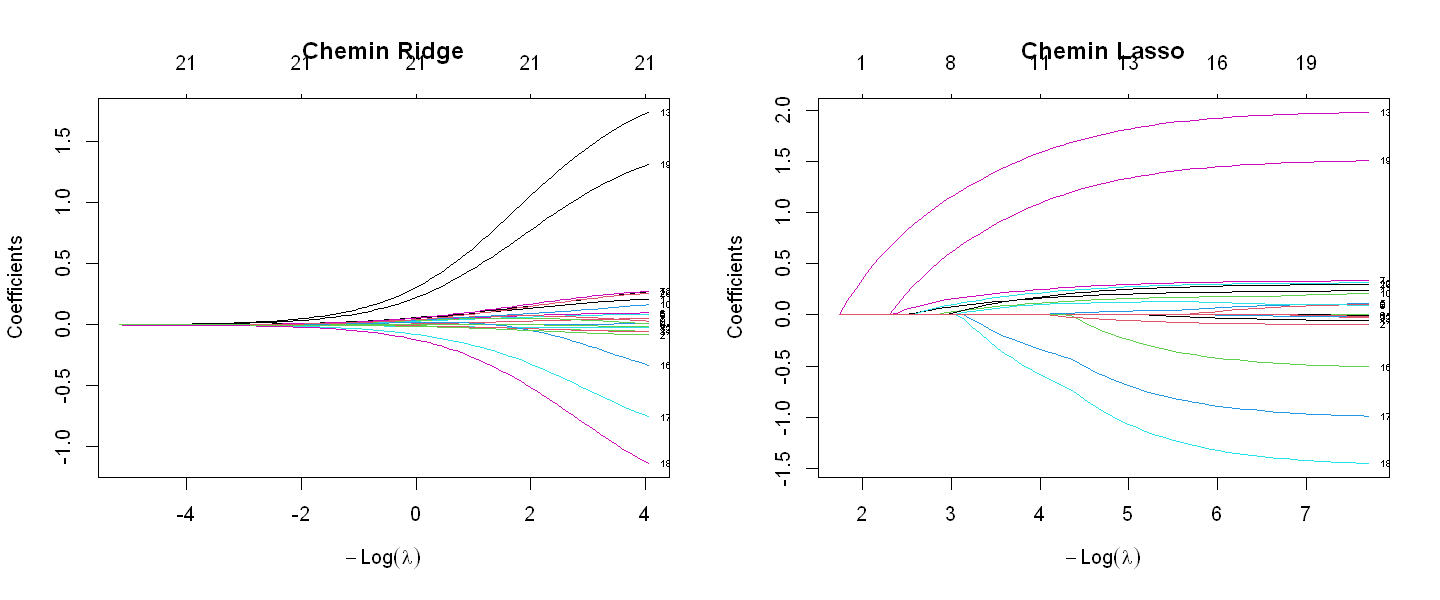

In [31]:
library(glmnet)

# matrice d'expériences avec model.matrix (-1 pour retirer l'intercept)
x.mat      <- model.matrix(Heart_Disease_Risk ~ . - 1, data = train_df)
x.mat.test <- model.matrix(Heart_Disease_Risk ~ . - 1, data = test_df)
y.train.num <- as.numeric(as.character(y_train))
y.test.num  <- as.numeric(as.character(y_test))

# Chemins de régularisation : 
# Ridge (alpha=0) : tous les coef décroissent vers 0 sans être annulés
# Lasso (alpha=1) : certains coef atteignent exactement 0 → sélection de variables
reg.ridge <- glmnet(y = y.train.num, x = x.mat, alpha = 0, family = "binomial")
reg.lasso <- glmnet(y = y.train.num, x = x.mat, alpha = 1, family = "binomial")

options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1, 2))
plot(reg.ridge, xvar = "lambda", label = TRUE, main = "Chemin Ridge")
plot(reg.lasso, xvar = "lambda", label = TRUE, main = "Chemin Lasso")
par(mfrow = c(1, 1))

Interprétation: 

Les chemins confirment le comportement attendu des deux méthodes. Sous Ridge, tous les coefficients décroissent progressivement vers 0 sans jamais être annulés. Sous Lasso, les variables entrent une à une dans le modèle. Les deux courbes roses dominant dès le début correspondent à Smoking_Status et Family_History, confirmant leur rôle prépondérant.



[1] "Ridge -lambda.min : 0.0175  lambda.1se : 0.03684"

[1] "Lasso - lambda.min : 0.00126  lambda.1se : 0.00978"

[1] "CV estimate of lambda     : 0.00126"

22 x 1 sparse Matrix of class "dgCMatrix"
                            lambda.min
(Intercept)              -5.175679e-01
Age                       2.279195e-01
Gender0                   7.495527e-02
Gender1                  -8.419247e-16
Height_cm                 .           
Weight_kg                 9.271363e-02
BMI                       1.042536e-01
Systolic_BP               3.269295e-01
Diastolic_BP              .           
Cholesterol_Total         .           
Cholesterol_LDL           1.839802e-01
Cholesterol_HDL          -1.068365e-02
Fasting_Blood_Sugar       3.073301e-01
Smoking_Status1           1.954148e+00
Alcohol_Consumption1     -4.467656e-02
Alcohol_Consumption2      .           
Physical_Activity_Level1 -4.721748e-01
Physical_Activity_Level2 -9.482777e-01
Physical_Activity_Level3 -1.399095e+00
Family_History1           1.481208e+00
Stress_Level              2.903709e-01
Sleep_Hours              -8.973754e-02

[1] "CV estimate of lambda 1se : 0.00978"

22 x 1 sparse Matrix of class "dgCMatrix"
                          lambda.1se
(Intercept)              -0.69419841
Age                       0.19145794
Gender0                   .         
Gender1                   .         
Height_cm                 .         
Weight_kg                 0.02783443
BMI                       0.11782266
Systolic_BP               0.28307406
Diastolic_BP              .         
Cholesterol_Total         .         
Cholesterol_LDL           0.14681925
Cholesterol_HDL           .         
Fasting_Blood_Sugar       0.25657981
Smoking_Status1           1.74581284
Alcohol_Consumption1      .         
Alcohol_Consumption2      .         
Physical_Activity_Level1 -0.12541993
Physical_Activity_Level2 -0.55858120
Physical_Activity_Level3 -0.89758259
Family_History1           1.26389056
Stress_Level              0.22834166
Sleep_Hours              -0.03812180

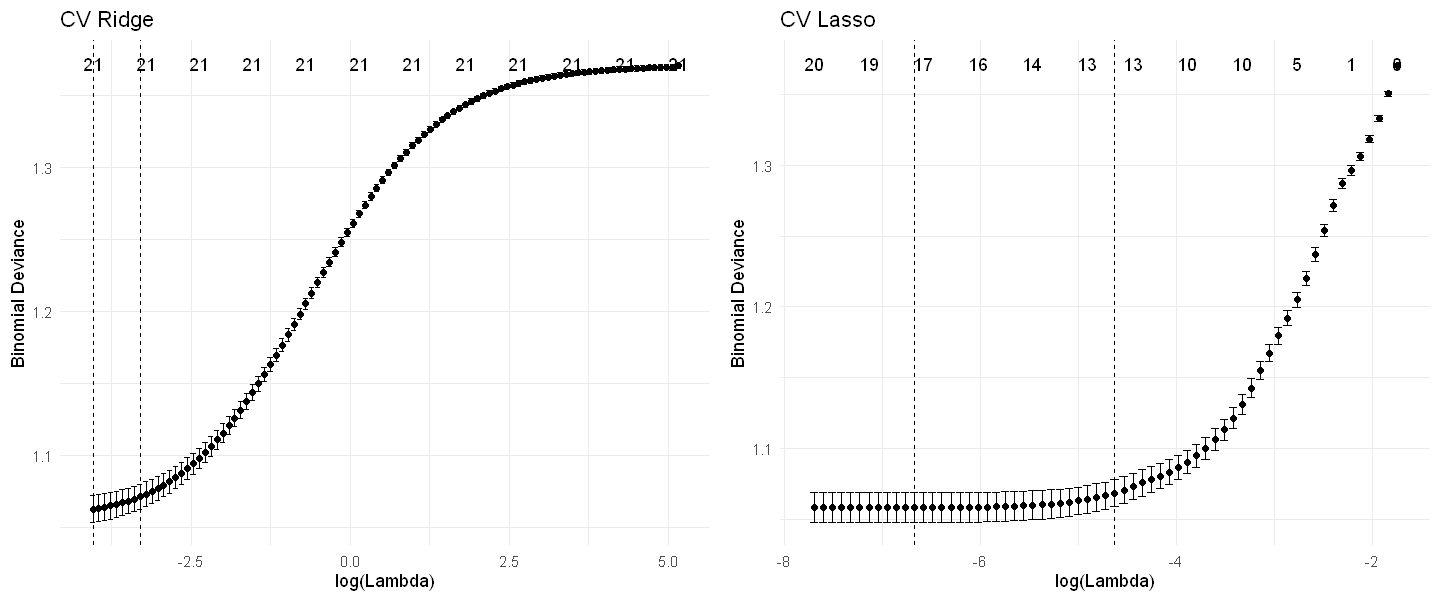

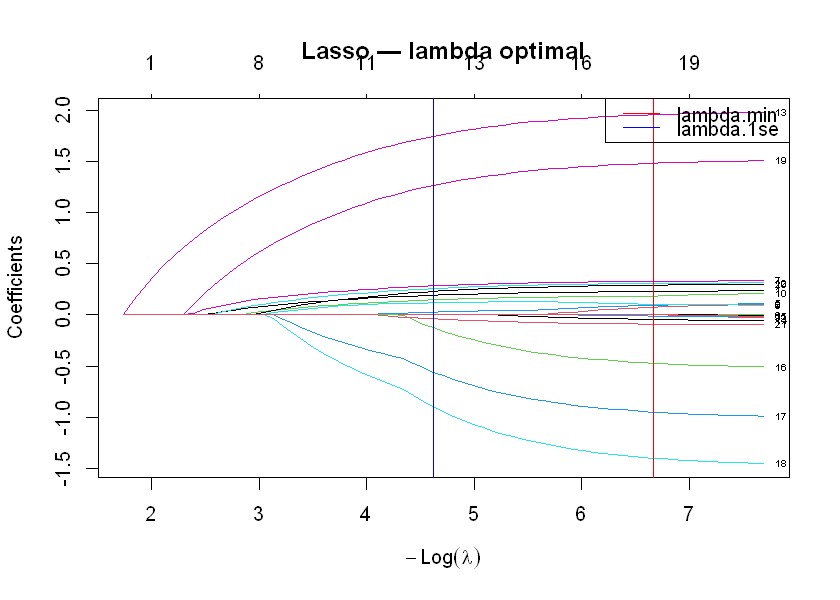

In [32]:
# Sélection de lambda par validation croisée 10-fold : 
# lambda.min : minimise l'erreur CV
# lambda.1se : erreur dans 1 écart-type du min → modèle plus simple
set.seed(111)
reg.ridge.cv <- cv.glmnet(y = y.train.num, x = x.mat, alpha = 0, family = "binomial", nfolds = 10)


set.seed(111)
reg.lasso.cv <- cv.glmnet(y = y.train.num, x = x.mat,alpha = 1, family = "binomial", nfolds = 10)

# visualisation de la validation croisée Ridge et Lasso
options(repr.plot.width = 12, repr.plot.height = 5)
p1 <- autoplot(reg.ridge.cv) + ggtitle("CV Ridge") + theme_minimal()
p2 <- autoplot(reg.lasso.cv) + ggtitle("CV Lasso") + theme_minimal()
grid.arrange(p1, p2, ncol = 2)

# valeurs de lambda retenues
paste("Ridge -lambda.min :", round(reg.ridge.cv$lambda.min, 5), " lambda.1se :", round(reg.ridge.cv$lambda.1se, 5))
paste("Lasso - lambda.min :", round(reg.lasso.cv$lambda.min, 5), " lambda.1se :", round(reg.lasso.cv$lambda.1se, 5))

# coefficients Lasso à lambda.min et lambda.1se
paste("CV estimate of lambda     :", round(reg.lasso.cv$lambda.min, 5))
coef(reg.lasso.cv, s = "lambda.min")
paste("CV estimate of lambda 1se :", round(reg.lasso.cv$lambda.1se, 5))
coef(reg.lasso.cv, s = "lambda.1se")

# visualisation du lambda choisi sur le chemin Lasso
options(repr.plot.width = 7, repr.plot.height = 5)
plot(reg.lasso, xvar = "lambda", label = TRUE, main = "Lasso — lambda optimal")
abline(v = -log(reg.lasso.cv$lambda.min), col = "red")
abline(v = -log(reg.lasso.cv$lambda.1se), col = "blue")
legend("topright", legend = c("lambda.min", "lambda.1se"),
       col = c("red", "blue"), lty = 1)

Interprétation : 

- À lambda.min, le Lasso retient 17 variables en annulant Height_cm, Diastolic_BP et Cholesterol_Total : cohérent avec le stepwise. 
- À lambda.1se, il adopte un modèle plus parcimonieux en éliminant également Gender, Cholesterol_HDL et Alcohol_Consumption, soit 13 variables retenues : identique au stepwise BIC.

   alpha  cv_error      lambda
1    0.0 0.2636667 0.025390248
2    0.1 0.2629167 0.006003497
3    0.2 0.2632500 0.012118111
4    0.3 0.2632500 0.014117829
5    0.4 0.2630000 0.011620725
6    0.5 0.2631667 0.010202985
7    0.6 0.2630000 0.007058915
8    0.7 0.2630000 0.007998402
9    0.8 0.2630833 0.001902632
10   0.9 0.2630833 0.005164767
11   1.0 0.2631667 0.004648290


[1] "Alpha retenu : 0.1"

[1] "Lambda retenu: 0.006"

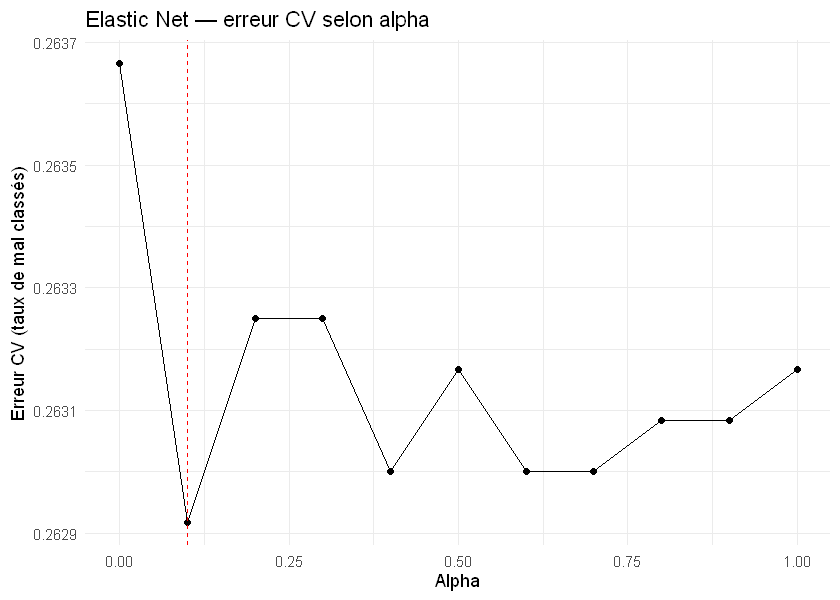

In [33]:
# Elastic Net : optimisation de alpha ET lambda par CV : 
# On teste une grille de valeurs d'alpha entre 0 (Ridge) et 1 (Lasso)
# et on retient le couple (alpha, lambda) qui minimise le taux de mal classés
set.seed(111)
alphas <- seq(0, 1, by = 0.1)
results.enet <- data.frame(alpha = alphas, cv_error = NA, lambda = NA)

for (i in seq_along(alphas)) {
  set.seed(111)
  cv_fit <- cv.glmnet(x.mat, y.train.num,
                      family = "binomial",
                      alpha = alphas[i],
                      nfolds = 10,
                      type.measure = "class")
  results.enet$cv_error[i]<- min(cv_fit$cvm)
  results.enet$lambda[i]   <- cv_fit$lambda.min
}

print(results.enet)

best.alpha  <- results.enet$alpha[which.min(results.enet$cv_error)]
best.lambda <- results.enet$lambda[which.min(results.enet$cv_error)]
paste("Alpha retenu :", best.alpha)
paste("Lambda retenu:", round(best.lambda, 5))

# visualisation de l'erreur CV selon alpha
options(repr.plot.width = 7, repr.plot.height = 5)
ggplot(results.enet, aes(x = alpha, y = cv_error)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = best.alpha, col = "red", lty = 2) +
  labs(title = "Elastic Net — erreur CV selon alpha",
       x = "Alpha", y = "Erreur CV (taux de mal classés)") +
  theme_minimal()

# modèle final Elastic Net avec le meilleur alpha
set.seed(111)
reg.enet.cv <- cv.glmnet(x.mat, y.train.num,
                          family = "binomial",
                          alpha  = best.alpha,
                          nfolds = 10)

Interprétation : 

Le graphique montre que les erreurs CV sont très proches quelle que soit la valeur d'alpha (fourchette 0.2629 à 0.2637), ce qui indique que Ridge et Lasso donnent des résultats similaires sur ce dataset. L'alpha retenu est 0.1, très proche de Ridge, avec lambda = 0.006.

In [34]:
# Erreur apparente (train) : 
fit.ridge.train <- predict(reg.ridge.cv, s = "lambda.min", newx = x.mat, type = "response")[, 1]
fit.lasso.train<- predict(reg.lasso.cv, s = "lambda.min", newx = x.mat, type = "response")[, 1]
fit.enet.train  <-predict(reg.enet.cv,  s = "lambda.min", newx = x.mat, type = "response")[, 1]

table(fit.ridge.train > 0.5, train_df$Heart_Disease_Risk)
table(fit.lasso.train > 0.5, train_df$Heart_Disease_Risk)
table(fit.enet.train > 0.5, train_df$Heart_Disease_Risk)

       
           0    1
  FALSE 5510 1911
  TRUE  1230 3349

       
           0    1
  FALSE 5474 1878
  TRUE  1266 3382

       
           0    1
  FALSE 5468 1871
  TRUE  1272 3389

In [35]:
# Matrices de confusion et performances sur le test : 
pred.ridge<- predict(reg.ridge.cv, newx = x.mat.test, s = "lambda.min", type = "response")[, 1]
pred.lasso<- predict(reg.lasso.cv, newx = x.mat.test, s = "lambda.min",type = "response")[, 1]
pred.enet  <-predict(reg.enet.cv,newx = x.mat.test,s = "lambda.min", type = "response")[, 1]

table(pred.ridge > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy Ridge :", round(mean((pred.ridge > 0.5) == (y.test.num == 1)), 4))
paste("AUC Ridge :", round(auc(roc(y.test.num, pred.ridge, quiet = TRUE)),4))

table(pred.lasso > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy Lasso :", round(mean((pred.lasso > 0.5) == (y.test.num == 1)), 4))
paste("AUC Lasso :", round(auc(roc(y.test.num, pred.lasso, quiet = TRUE)),4))

table(pred.enet > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy Enet :", round(mean((pred.enet > 0.5) == (y.test.num == 1)), 4))
paste("AUC Enet :", round(auc(roc(y.test.num, pred.enet, quiet = TRUE)),4))

       
           0    1
  FALSE 1393  451
  TRUE   327  829

[1] "Accuracy Ridge : 0.7407"

[1] "AUC Ridge : 0.808"

       
           0    1
  FALSE 1384  435
  TRUE   336  845

[1] "Accuracy Lasso : 0.743"

[1] "AUC Lasso : 0.8086"

       
           0    1
  FALSE 1383  430
  TRUE   337  850

[1] "Accuracy Enet : 0.7443"

[1] "AUC Enet : 0.8085"

Interprétation performances Ridge / Lasso / Elastic Net : 

- Ridge : accuracy 0.7407, AUC 0.808
- Lasso : accuracy 0.743, AUC 0.8086
- Elastic Net (alpha=0.1) : accuracy 0.7443, AUC 0.8085

Les trois modèles sont comparables. L'erreur apparente train/test est stable pour les trois, confirmant **l'absence de surapprentissage.**

CONCLUSION :

Les trois méthodes de pénalisation donnent des performances quasi identiques, avec une AUC stable autour de 0.808. Le lambda optimal très faible pour Ridge (0.0175) et la quasi-platitude de la courbe Elastic Net selon alpha confirment que la pénalisation n'apporte pas de gain significatif sur ce dataset : les variables redondantes ont un impact marginal et le modèle logistique simple est déjà proche de son optimum. Le Lasso reste néanmoins intéressant pour sa capacité de sélection automatique, cohérente avec les résultats du stepwise.

#### 3.1.4 Courbes ROC et comparaison finale 

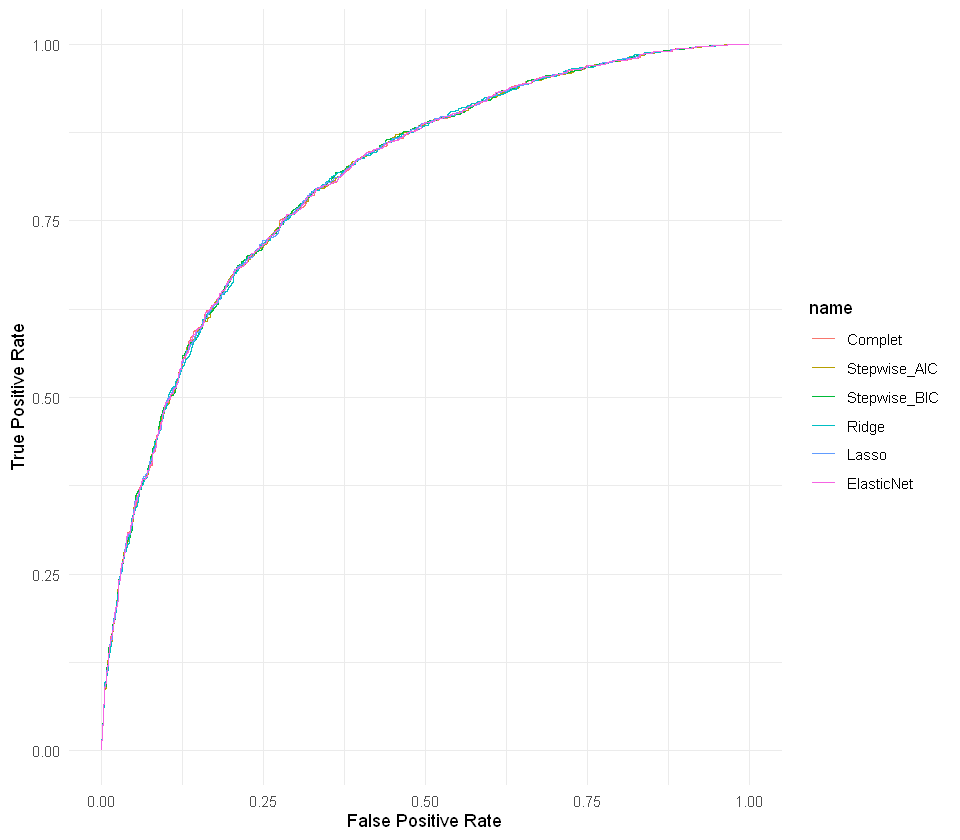

In [36]:
library(pROC)

# calcul des objets ROC pour tous les modèles
roc.aic <- roc(test_df$Heart_Disease_Risk, pred.step.aic, quiet = TRUE)
roc.bic <- roc(test_df$Heart_Disease_Risk, pred.step.bic, quiet = TRUE)
roc.ridge <- roc(y.test.num, pred.ridge, quiet = TRUE)
roc.lasso <- roc(y.test.num, pred.lasso, quiet = TRUE)
roc.enet <- roc(y.test.num, pred.enet, quiet = TRUE)

# graph courbes ROC superposées
options(repr.plot.width = 8, repr.plot.height = 7)
ggroc(list(
  Complet = roc.lm,
  Stepwise_AIC = roc.aic,
  Stepwise_BIC = roc.bic,
  Ridge = roc.ridge,
  Lasso = roc.lasso,
  ElasticNet = roc.enet
), legacy.axes = TRUE) +
  xlab("False Positive Rate") +
  ylab("True Positive Rate") +
  theme_minimal()

Interprétation : 

Les six courbes sont quasi superposées, ce qui confirme visuellement que tous les modèles linéaires ont **une capacité discriminante identique**. Aucune méthode ne se démarque des autres, que ce soit en termes de sélection de variables ou de pénalisation.

In [37]:
# tableau récapitulatif trié par AUC décroissante
resultats <- data.frame(
  Modele = c("Logistique complet", "Stepwise AIC", "Stepwise BIC","Ridge", "Lasso", "Elastic Net"),
  Nb_variables = c(
    length(coef(log.lm)) - 1,
    length(coef(log.lm.step.aic)) - 1,
    length(coef(log.lm.step.bic)) - 1,
    NA,
    sum(coef(reg.lasso.cv, s = "lambda.min") != 0) - 1,
    NA),
  Accuracy_train = round(c(
    mean((log.lm$fitted.values > 0.5) == (y.train.num == 1)),
    mean((log.lm.step.aic$fitted.values > 0.5) == (y.train.num == 1)),
    mean((log.lm.step.bic$fitted.values > 0.5) == (y.train.num == 1)),
    mean((fit.ridge.train > 0.5) == (y.train.num == 1)),
    mean((fit.lasso.train > 0.5) == (y.train.num == 1)),
    mean((fit.enet.train > 0.5) == (y.train.num == 1))
  ), 4),
  Accuracy_test = round(c(
    mean((pred.lm > 0.5) == (y.test.num == 1)),
    mean((pred.step.aic > 0.5) == (y.test.num == 1)),
    mean((pred.step.bic > 0.5) == (y.test.num == 1)),
    mean((pred.ridge > 0.5) == (y.test.num == 1)),
    mean((pred.lasso > 0.5) == (y.test.num == 1)),
    mean((pred.enet > 0.5) == (y.test.num == 1))
  ), 4),
  AUC = round(c(
    auc(roc.lm), auc(roc.aic), auc(roc.bic),
    auc(roc.ridge), auc(roc.lasso), auc(roc.enet)
  ), 4))

resultats[order(-resultats$AUC), ]

,Modele,Nb_variables,Accuracy_train,Accuracy_test,AUC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
3,Stepwise BIC,13,0.7385,0.7437,0.8089
5,Lasso,17,0.7380,0.7430,0.8086
6,Elastic Net,NA,0.7381,0.7443,0.8085
1,Logistique complet,20,0.7382,0.7450,0.8084
2,Stepwise AIC,14,0.7374,0.7450,0.8082
4,Ridge,NA,0.7382,0.7407,0.8080


Interprétation : 

Les accuracy train et test sont très proches pour tous les modèles, confirmant l'absence de surapprentissage.

CONCLUSION : 

L'ensemble des modèles linéaires converge vers une AUC d'environ 0.808 et une accuracy d'environ 0.74, indépendamment de la méthode utilisée. Ce résultat stable suggère que la frontière de décision est essentiellement linéaire sur ce problème, et que ni la sélection de variables ni la pénalisation n'apportent de gain significatif en termes de performance prédictive.
Si on ajoute une contrainte d'interprétabilité, le Stepwise BIC est le modèle à retenir : meilleure AUC (0.8089) avec seulement 13 variables, dont toutes sont médicalement interprétables via leurs odds ratios.
Ces résultats seront à comparer avec les modèles non linéaires du groupe pour quantifier l'éventuel gain apporté par des approches plus complexes.

#### 3.1.5 Interprétation des coefs 

(Intercept)                      Age                Height_cm 
               0.6285333                1.2632171                0.8987726 
               Weight_kg              Systolic_BP          Cholesterol_LDL 
               1.2659289                1.3978990                1.2090882 
     Fasting_Blood_Sugar          Smoking_Status1 Physical_Activity_Level1 
               1.3717251                7.3217840                0.5880970 
Physical_Activity_Level2 Physical_Activity_Level3          Family_History1 
               0.3625559                0.2269547                4.5545807 
            Stress_Level              Sleep_Hours 
               1.3506076                0.9065624

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),0.5703760,0.6924593
Age,1.2011720,1.3286779
Height_cm,0.8514754,0.9486240
Weight_kg,1.1971287,1.3389002
Systolic_BP,1.3318254,1.4675957
Cholesterol_LDL,1.1540707,1.2669000
Fasting_Blood_Sugar,1.3118915,1.4346079
Smoking_Status1,6.6381724,8.0836760
Physical_Activity_Level1,0.5243353,0.6594274
Physical_Activity_Level2,0.3202287,0.4102529


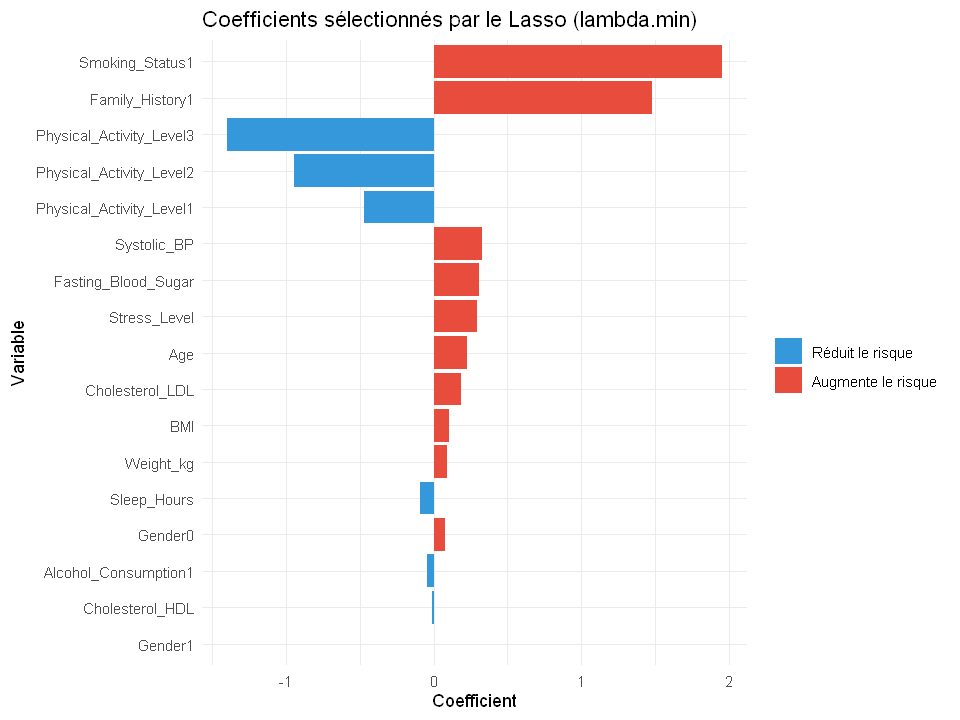

In [38]:
# odds ratios du modèle BIC (le plus parcimonieux)
# OR > 1 : augmente le risque cardiaque
# OR < 1 : réduit le risque cardiaque
exp(coef(log.lm.step.bic))
exp(confint(log.lm.step.bic))

# coefficients non nuls du Lasso à lambda.min 
# lambda.min pour la performance, lambda.1se pour la parcimonie et comme la parcimonie est déjà gérée par le BIC dans notre comparaison, 
# lambda.min est le choix cohérent pour les modèles pénalisés.
coef.lasso <- as.data.frame(as.matrix(coef(reg.lasso.cv, s = "lambda.min")))
colnames(coef.lasso) <- "Coefficient"
coef.lasso$Variable <- rownames(coef.lasso)
coef.lasso <- coef.lasso[coef.lasso$Coefficient != 0 & coef.lasso$Variable != "(Intercept)", ]
coef.lasso <- coef.lasso[order(abs(coef.lasso$Coefficient), decreasing = TRUE), ]

# graphique des coefficients
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(coef.lasso, aes(x = reorder(Variable, abs(Coefficient)),
y = Coefficient,
fill = Coefficient > 0)) +
geom_col() +
coord_flip() +
scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"),
labels = c("TRUE" = "Augmente le risque", "FALSE" = "Réduit le risque")) +
labs(title = "Coefficients sélectionnés par le Lasso (lambda.min)",
x = "Variable", y = "Coefficient", fill = "") +
  theme_minimal()

Interprétation : 

Les odds ratios confirment et quantifient les résultats déjà observés :

- Smoking_Status1 (OR = 7.32, IC : [6.38 ; 8.08]) : un fumeur a 7 fois plus de risque qu'un non-fumeur — variable la plus discriminante du dataset, avec un intervalle de confiance très resserré
- Family_History1 (OR = 4.55, IC : [4.03 ; 5.15]) : les antécédents familiaux multiplient le risque par 4.5
- Physical_Activity_Level3 (OR = 0.23, IC : [0.19 ; 0.27]) : le niveau d'activité physique le plus élevé divise le risque par plus de 4. c'est donc un fort effet protecteur
- Age, Systolic_BP, Fasting_Blood_Sugar, Stress_Level augmentent modérément le risque (OR entre 1.26 et 1.40)
- Sleep_Hours (OR = 0.91) et Height_cm (OR = 0.90) ont un léger effet protecteur

Tous les intervalles de confiance excluent 1, confirmant la significativité de chaque variable retenue


Interprétation graphique : 
Le graphique confirme la hiérarchie des variables. 
- Smoking_Status1 et Family_History1 dominent largement avec les coefficients les plus élevés en valeur absolue.
- Les variables en bas du graphique (Gender1, Cholesterol_HDL, Alcohol_Consumption1) ont des coefficients quasi nuls, le Lasso les conserve à peine, ce qui est cohérent avec leur non-significativité dans le modèle complet.

CONCLUSION : 

Les résultats sont pleinement cohérents avec l'analyse exploratoire et les connaissances médicales établies. **Le tabagisme et les antécédents familiaux** sont les facteurs de risque les plus forts, tandis que l'activité physique est le principal facteur protecteur. Cette interprétabilité directe via les odds ratios est un avantage clé des modèles linéaires par rapport aux approches non linéaires du groupe, et constitue une réponse concrète à la question des consignes : quel modèle retenir si on ajoute une contrainte d'interprétabilité ?
**le Stepwise BIC**


#### 3.1.6 Conclusion Finale - Modèles Linéaires Généralisés

L'ensemble des modèles linéaires obtient des performances homogènes, avec une AUC comprise entre **0.808 et 0.809** et une accuracy autour de **0.74 sur l'échantillon test**. La comparaison des accuracy train et test ne révèle pas de surapprentissage significatif : les performances sont stables entre les deux échantillons, ce qui confirme la robustesse des modèles.

Concernant le choix de lambda.min plutôt que lambda.1se pour Ridge, Lasso et Elastic Net : dans un objectif de maximisation des performances prédictives, **lambda.min** est préféré car il minimise directement l'erreur de validation croisée. lambda.1se serait retenu si la priorité était la parcimonie maximale du modèle, ce que le stepwise BIC couvre déjà mieux dans notre cas.

La sélection de variables (stepwise BIC, Lasso) confirme les résultats de l'analyse exploratoire : les variables les plus discriminantes sont **le tabagisme, les antécédents familiaux, le niveau d'activité physique, la glycémie à jeun et la pression systolique.** Les variables morphologiques (taille, IMC, poids) et biologiques redondantes (cholestérol total, HDL, pression diastolique) apportent peu d'information supplémentaire.

(La comparaison avec les modèles non linéaires du groupe (SVM : AUC ≈ 0.796, LDA : AUC ≈ 0.735) montre que les modèles linéaires sont compétitifs, voire supérieurs sur ce jeu de données. Cela suggère que la frontière de décision est essentiellement linéaire et que la complexité additionnelle des modèles non linéaires n'apporte pas de gain significatif ici. Le tableau de comparaison global sera complété en fin de projet avec l'ensemble des résultats du groupe.) 
**A mettre en CCL finale**

### 3.2 Prévision par Support Vector Machine : SVC pour Heart_Disease_Risk

Dans cette partie, l’objectif est de prédire s’il existe un risque de maladie cardiaque (variable Heart_Disease_Risk) avec la méthode SVM. Il s’agit d’un problème de classification binaire.

Nous testerons d'abord des SVC (Support Vecteur Classification) avec 4 noyaux différents : gaussien, linéaire, polynomial et radial; pour déterminer la meilleure méthode de classification à l'aide de l'accurancy et de l'AUC (Area Under the Curve).
Ensuite nous réaliserons quelques autres modèles d’apprentissage automatique : LDA (Analyse Discriminante Linéaire), QDA (Analyse Discriminante Quadratique), kNN (k plus proches voisins), afin d’analyser leurs performances respectives sur ce problème de prédiction et de les comparer avec les SVC.

#### 3.2.0 Test sur plusieurs noyaux

**SVM : Noyau Gaussien**

In [ ]:
set.seed(111) # initialisation du générateur
# Ajouter y_train pour svm()
datappq$Heart_Disease_Risk <- y_train
datappq_small <- datappq[sample(nrow(datappq), 5000), ] #15 000 dossiers en tout

[1] "Valeur de cost retenu : 1"


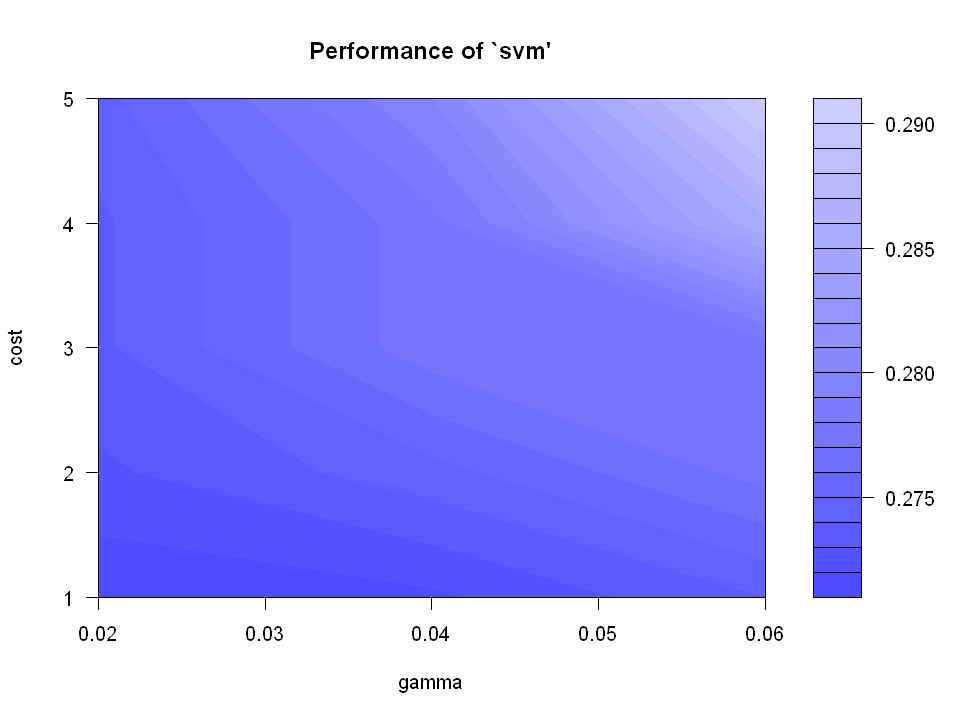

In [ ]:
set.seed(111) 
# SVM avec noyau gaussien (RBF) : tune des hyperparamètres
QUICK <- FALSE

if (!QUICK){
    svm.tune <- tune.svm(
       Heart_Disease_Risk ~ .,
       data  = datappq_small, # si datappq_small, on test sur un sous-échantillon pour aller plus vite
       cost  = c(1, 2, 3, 4, 5),
       gamma = seq(0.02, 0.06, by = 0.02),
       tunecontrol = tune.control(cross = 10) # pour aller un peu plus vite on réduit la valeur
     )
    plot(svm.tune)
    print(paste("Valeur de cost retenu : ", svm.tune$best.parameters$cost, sep=""))
} else {
  svm.tune <- list(best.parameters = list(cost = 1))
}

In [ ]:
set.seed(111) 
# Modèle avec paramètres optimaux
svm.fit <- svm(
  Heart_Disease_Risk ~ .,
  data  = datappq,
  cost  = svm.tune$best.parameters$cost,
  gamma = svm.tune$best.parameters$gamma,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm <- predict(svm.fit, newdata = datestppq, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm == y_test))) # accuracy


[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1402  480
        1  318  800

[1] "Accuracy du modèle : 0.734"


**SVM : Noyau Linéaire**

[1] "Valeur de cost retenu : 1"


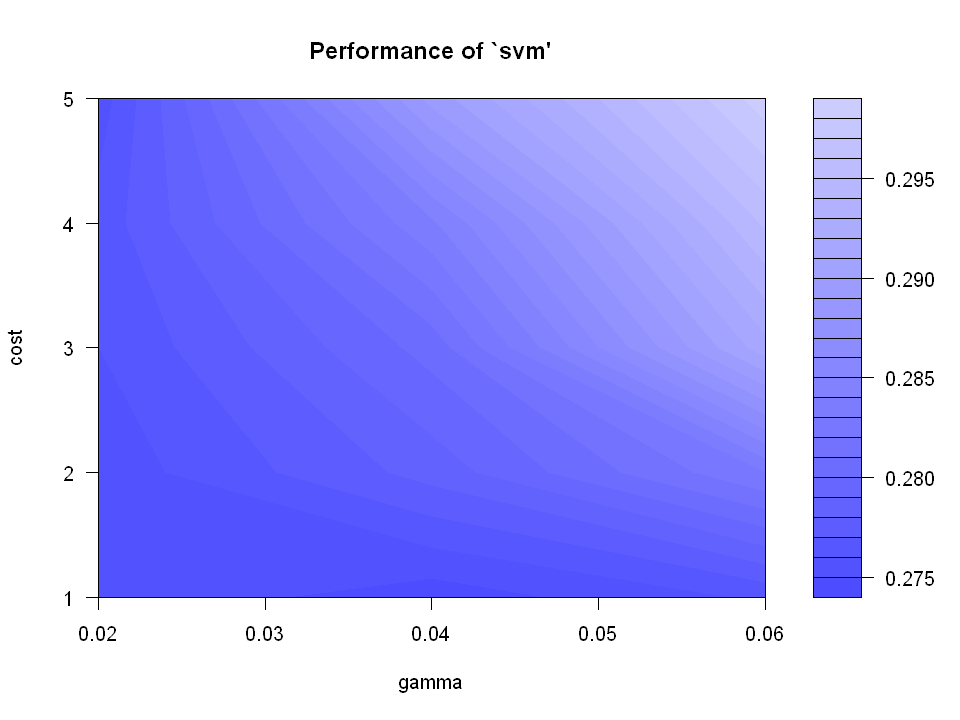

In [ ]:
set.seed(111) 
datappq_small <- datappq[sample(nrow(datappq), 5000), ] #15 000 dossiers en tout

# noyau linéaire 
QUICK <- FALSE

if (!QUICK) {
    svm.lin.tune <- tune.svm(
        Heart_Disease_Risk ~ .,
        data  = datappq_small, # si datappq_small, on test sur un sous-échantillon pour aller plus vite
        cost  = c(1, 2, 3, 4, 5),
        gamma = seq(0.02, 0.06, by = 0.02),
        tunecontrol = tune.control(cross = 10) # pour aller un peu plus vite on réduit la valeur
    )
    plot(svm.lin.tune)
    print(paste("Valeur de cost retenu : ", svm.lin.tune$best.parameters$cost, sep=""))
} else {
  svm.lin.tune <- list(best.parameters = list(cost = 1, gamma = 0.02))
}


In [ ]:
set.seed(111) 
svm.lin <- svm(
  Heart_Disease_Risk ~ .,
  data = datappq_small,
  kernel = "linear",
  cost = svm.lin.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.lin <- predict(svm.lin, newdata = datestppq, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.lin, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.lin == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1375  436
        1  345  844

[1] "Accuracy du modèle : 0.739666666666667"


**SVM : Noyau polynomial**

[1] "Valeur de cost retenu : 4"
[1] "Valeur de gamma retenu : 0.02"
[1] "Valeur de degree retenu : 3"
[1] "Valeur de coef0 retenu : 0"


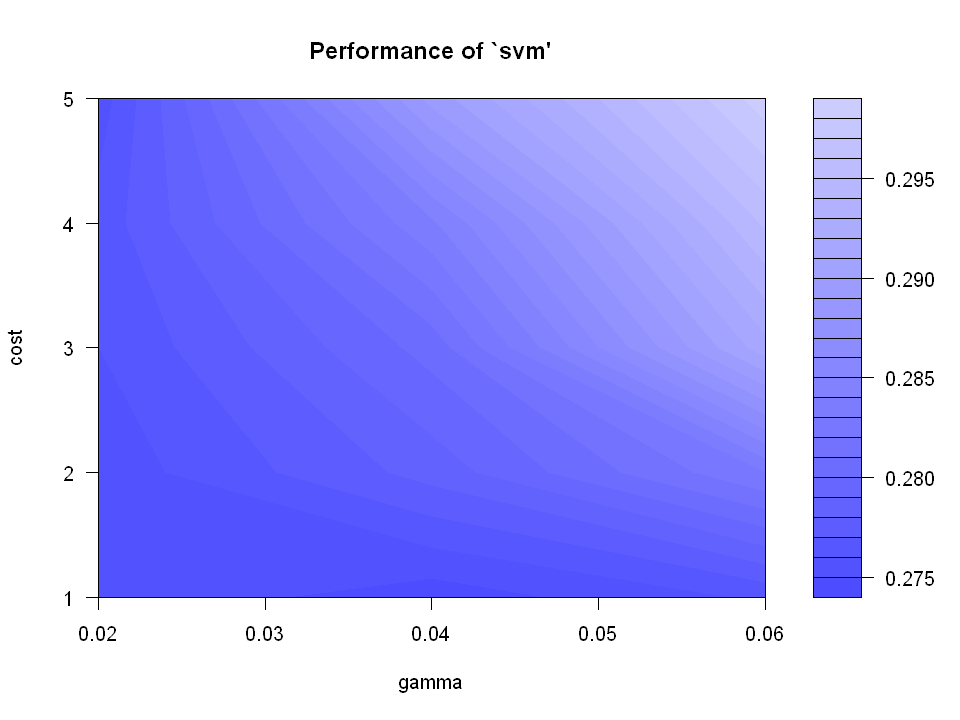

In [ ]:
set.seed(111) 
datappq_small <- datappq[sample(nrow(datappq), 5000), ] #15 000 dossiers en tout

QUICK <- FALSE

if (!QUICK) {
  # Ajustement du modèle avec validation croisée
  svm.pol.tune <- tune.svm(Heart_Disease_Risk ~ ., 
                           data = datappq_small,
                           coef0 = c(0, 0.5, 1, 2),
                           degree = c(2, 3),
                           cost  = c(1, 2, 3, 4, 5),
                           gamma = seq(0.02, 0.06, by = 0.02),
                           tunecontrol = tune.control(cross = 10), # pour aller un peu plus vite on réduit la valeur
                           kernel = "polynomial"
    )
  print(paste("Valeur de cost retenu : ", svm.pol.tune$best.parameters$cost, sep=""))
  print(paste("Valeur de gamma retenu : ", svm.pol.tune$best.parameters$gamma, sep=""))
  print(paste("Valeur de degree retenu : ", svm.pol.tune$best.parameters$degree, sep=""))
  print(paste("Valeur de coef0 retenu : ", svm.pol.tune$best.parameters$coef0, sep=""))
  plot(svm.lin.tune) 
} else {
  svm.pol.tune <- list(best.parameters = list(cost = 1, gamma = 0.02, coef0=1, degree=2)) 
}

############################################
# YA PAS UN SOUCIS DANS plot(svm.lin.tune) ?
# C'EST LE TUNE DU SVM LINÉAIRE PAS DU POLYNOMIAL
############################################

In [ ]:
set.seed(111) 
svm.pol <- svm(
  Heart_Disease_Risk ~ .,
  data = datappq_small,
  kernel = "polynomial",
  cost = svm.pol.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.pol <- predict(svm.pol, newdata = datestppq, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.pol, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.pol == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1376  535
        1  344  745

[1] "Accuracy du modèle : 0.707"


**SVM : Noyau radial**

[1] "Valeur de cost retenu : 1"
[1] "Valeur de gamma retenu : 0.04"


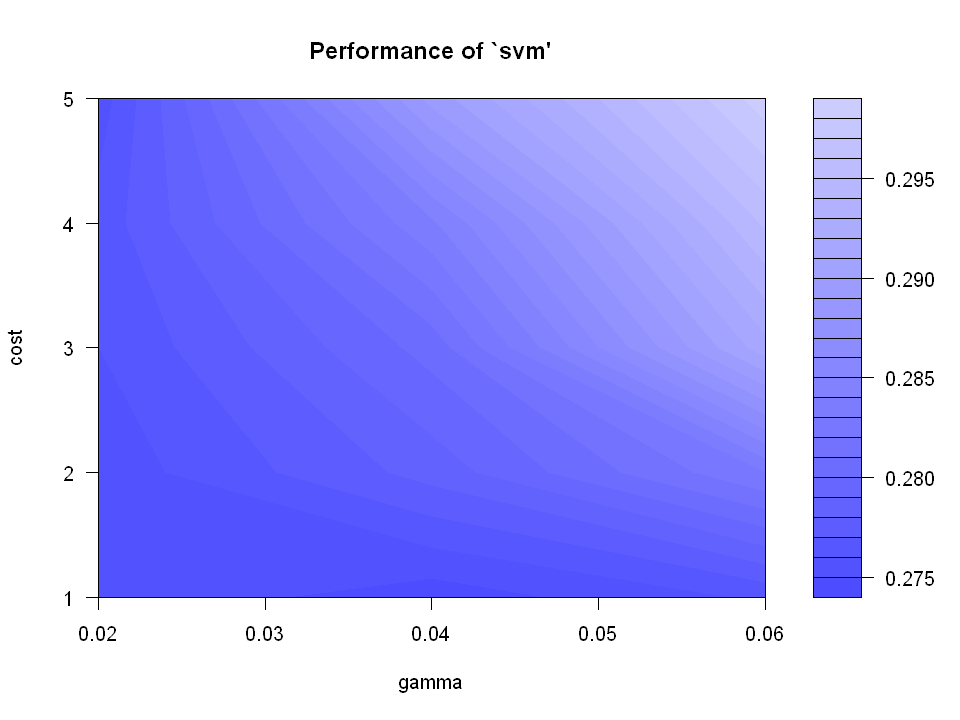

In [ ]:
set.seed(111) 
datappq_small <- datappq[sample(nrow(datappq), 5000), ] #15 000 dossiers en tout

QUICK <- FALSE

if (!QUICK) {
    svm.rad.tune <- tune.svm(
      Heart_Disease_Risk ~ .,
      data  = datappq_small, # si datappq_small, on test sur un sous-échantillon pour aller plus vite
      cost  = c(1, 2, 3, 4, 5),
      gamma = seq(0.02, 0.06, by = 0.02),
      tunecontrol = tune.control(cross = 10), # pour aller un peu plus vite on réduit la valeur
      kernel = "radial"
    )
    plot(svm.rad.tune)
    print(paste("Valeur de cost retenu : ", svm.rad.tune$best.parameters$cost, sep=""))
    print(paste("Valeur de gamma retenu : ", svm.rad.tune$best.parameters$gamma, sep=""))

} else {
  svm.rad.tune <- list(best.parameters = list(cost = 1, gamma = 0.02))
}

In [ ]:
set.seed(111) 
svm.rad <- svm(
  Heart_Disease_Risk ~ .,
  data = datappq_small,
  kernel = "radial",
  cost = svm.rad.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.rad <- predict(svm.rad, newdata = datestppq, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.rad, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.rad == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1365  465
        1  355  815

[1] "Accuracy du modèle : 0.726666666666667"


**Courbes ROC**

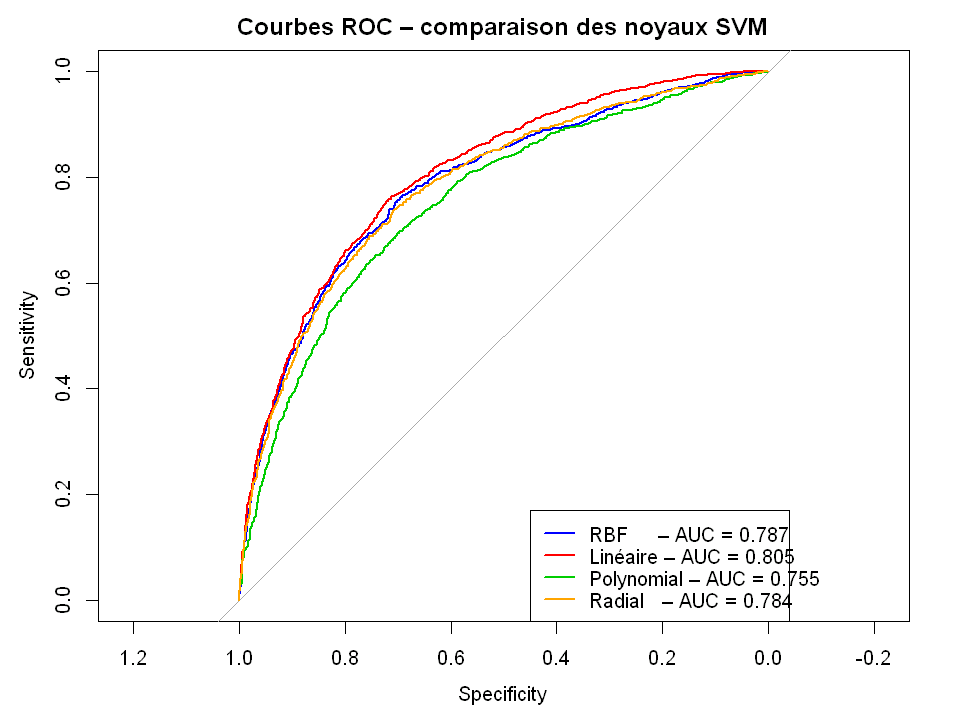

In [53]:
set.seed(111) 
# Probabilités de chaque modèle
proba_rbf  <- attr(pred_svm,     "probabilities")[, "1"]
proba_lin  <- attr(pred_svm.lin, "probabilities")[, "1"]
proba_pol  <- attr(pred_svm.pol, "probabilities")[, "1"]
proba_rad  <- attr(pred_svm.rad, "probabilities")[, "1"]

# ROC
roc_rbf <- roc(response = y_test, predictor = proba_rbf, levels = c("0","1"), direction = "<")
roc_lin <- roc(response = y_test, predictor = proba_lin, levels = c("0","1"), direction = "<")
roc_pol <- roc(response = y_test, predictor = proba_pol, levels = c("0","1"), direction = "<")
roc_rad <- roc(response = y_test, predictor = proba_rad, levels = c("0","1"), direction = "<")

# Plot
plot(roc_rbf, col = "blue",   lwd = 2, main = "Courbes ROC – comparaison des noyaux SVM")
plot(roc_lin, col = "red",    lwd = 2, add = TRUE)
plot(roc_pol, col = "green3", lwd = 2, add = TRUE)
plot(roc_rad, col = "orange", lwd = 2, add = TRUE)

legend("bottomright",
  legend = c(
    paste0("RBF     – AUC = ", round(auc(roc_rbf), 3)),
    paste0("Linéaire – AUC = ", round(auc(roc_lin), 3)),
    paste0("Polynomial – AUC = ", round(auc(roc_pol), 3)),
    paste0("Radial   – AUC = ", round(auc(roc_rad), 3))
  ),
  col = c("blue","red","green3","orange"),
  lwd = 2
)

#### 3.2.1 Choix du noyau : 

L'ensemble des codes ci-dessus permet de comparer les classifications des SVC avec différents noyaux à l'aide de l'**AUC**, qui mesure la capacité du modèle à distinguer les deux classes sur l'ensemble des seuils de décision. Contrairement à l'**accuracy**, qui ne représente que la proportion globale de prédictions correctes à un seuil fixe, l'AUC est un critère plus fiable car elle reste indépendante du seuil de classification choisi. Cette robustesse est cruciale dans un contexte médical où l'objectif est de limiter les faux négatifs (patients malades non détectés), rendant l'AUC souvent plus pertinente qu'un simple taux de réussite global.

Le modèle avec la meilleure précision (accuracy) est le modèle avec noyau gaussien : "Accuracy du modèle : 0.734", sa matrice de confusion a moins d'individus mal classés (hors diagonale).
En regardant l'AUC, c'est le noyau linéaire qui donne les meilleures performances, mais les AUC restent proches entre les modèles. On pourrait donc aussi choisir le noyau gaussien.

#### 3.2.2 Analyse supplémentaire : 

Maintenant, nous allons aussi évaluer et comparer plusieurs autres modèles d’apprentissage automatique : LDA (Analyse Discriminante Linéaire), QDA (Analyse Discriminante Quadratique), kNN (k plus proches voisins), afin d’analyser leurs performances respectives sur ce problème de prédiction.

**1. Analyse discriminante linéaire**

Cette méthode cherche à projeter les données dans un espace de plus faible dimension tout en maximisant la séparation entre les classes, en supposant que chaque classe suit une distribution gaussienne avec une même matrice de covariance. La LDA n'offre pas de possibilité d'ajustement avec des hyperparamètres. Nous pouvons tout de même avoir accès à sa précision, et le *Cohen’s Kappa* (qui compare la précision du modèle à ce qu’on obtiendrait par un classement aléatoire).

In [ ]:
set.seed(111) 
# analyse discriminante linéaire
lda_model <- lda(Heart_Disease_Risk ~ ., data = datappq_small)

pred_lda <- predict(lda_model, datestppq)$class

# matrice de confusion correcte
table(Predicted = pred_lda, Actual = y_test)

# accuracy
print(paste("Accuracy du modèle :", mean(pred_lda == y_test))) 

         Actual
Predicted    0    1
        0 1369  432
        1  351  848

[1] "Accuracy du modèle : 0.739"


**2. Analyse discriminante quadratique**

Nous comparons ensuite les performances de l'Analyse Discriminante Quadratique (QDA). Contrairement au LDA, le QDA relaxe l'hypothèse d'une covariance commune et autorise des frontières de décision quadratiques, ce qui lui permet de modéliser des structures de données plus complexes et non linéaires.

In [ ]:
set.seed(111) 
# analyse discriminante quadratique 
qda_model <- qda(Heart_Disease_Risk ~ ., data = datappq_small)

pred_qda <- predict(qda_model, datestppq)$class

# matrice de confusion correcte
table(Predicted = pred_qda, Actual = y_test)

# accuracy
print(paste("Accuracy du modèle :", mean(pred_qda == y_test))) 

         Actual
Predicted    0    1
        0 1296  411
        1  424  869

[1] "Accuracy du modèle : 0.721666666666667"


**3. k plus proches voisins**

Enfin, nous testons l'algorithme des k plus proches voisins (kNN). Il s'agit d'une approche non paramétrique qui classe une nouvelle observation en fonction de la majorité des étiquettes de ses k voisins les plus proches dans l'espace des caractéristiques, sans construire de modèle explicite préalable.

In [ ]:
set.seed(111) 
train_x <- datappq_small[, -which(names(datappq_small) == "Heart_Disease_Risk")] # train features
test_x <- datestppq # test features
train_y <- datappq_small$Heart_Disease_Risk # train target

# prédiction KNN
pred_knn <- knn(
  train = train_x,
  test  = test_x,
  cl    = train_y,
  k = 10
)

# matrice de confusion
table(Predicted = pred_knn, Actual = y_test)

# accuracy
print(paste("Accuracy du modèle :", mean(pred_knn == y_test))) 

         Actual
Predicted    0    1
        0 1315  643
        1  405  637

[1] "Accuracy du modèle : 0.650666666666667"


In [57]:
set.seed(111) 
# Prédictions de classe (les predict() sans probability retournent directement les classes)
acc_rbf <- mean(pred_svm     == y_test)
acc_lin <- mean(pred_svm.lin == y_test)
acc_pol <- mean(pred_svm.pol == y_test)
acc_rad <- mean(pred_svm.rad == y_test)
acc_lda <- mean(pred_lda     == y_test)
acc_qda <- mean(pred_qda     == y_test)
acc_knn <- mean(pred_knn     == y_test)

# Tableau récapitulatif
resultats <- data.frame(
  Modèle   = c("SVM – RBF (gaussien)", "SVM – Linéaire", 
                "SVM – Polynomial", "SVM – Radial",
                "LDA", "QDA", "kNN (k=10)"),
  Accuracy  = round(c(acc_rbf, acc_lin, acc_pol, acc_rad,
                       acc_lda, acc_qda, acc_knn), 4),
  AUC       = round(c(auc(roc_rbf), auc(roc_lin), auc(roc_pol), auc(roc_rad),
                       NA, NA, NA), 4)  # AUC non calculée pour LDA/QDA/kNN ici
)

# Tri du meilleur au moins bon
resultats <- resultats[order(-resultats$Accuracy), ]

print(resultats)

                Modèle Accuracy    AUC
2       SVM – Linéaire   0.7397 0.8051
5                  LDA   0.7390     NA
1 SVM – RBF (gaussien)   0.7340 0.7870
4         SVM – Radial   0.7267 0.7839
6                  QDA   0.7217     NA
3     SVM – Polynomial   0.7070 0.7552
7           kNN (k=10)   0.6507     NA


Le tableau des résultats montre que la SVC avec noyau linéaire est la plus performante selon l'AUC, ce qui signifie qu'elle distingue le mieux les deux classes dans l'ensemble. Cependant, cette même méthode obtient l'accuracy la plus faible (0,707), tandis que les autres modèles atteignent jusqu'à 0,735.

En résumé, le noyau linéaire est plus fiable pour la discrimination globale, mais il fait plus d'erreurs de classification à un seuil fixe que les autres algorithmes.


**nb :** Il existe une deuxième méthode plus concise pour la sélection du noyau avec la librairie caret : 

In [ ]:
# Pour datappq_small (en utilisant y_train)
datappq_small$Heart_Disease_Risk <- factor(
  y_train, 
  levels = c(0, 1), 
  labels = c("No", "Yes")
)

# Pour datappq_test (en utilisant y_test)
datappq_test$Heart_Disease_Risk <- factor(
  y_test, 
  levels = c(0, 1), 
  labels = c("No", "Yes")
)

In [ ]:
set.seed(111) 

# Recréer un data.frame complet pour caret
set.seed(111)
idx <- sample(nrow(datappq), 5000)

datappq_caret <- datappq[idx, ]

datappq_caret$Heart_Disease_Risk <- factor(
  y_train[idx],
  levels = c(0, 1),
  labels = c("No", "Yes")
)

datappq_caret <- na.omit(datappq_caret) # car certaines combinaisons d’hyperparamètres ne convergent pas correctement dans kernlab

# Contrôle CV
cvControl <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  summaryFunction = twoClassSummary
)

# Grilles
methodes_svm <- list(
  list(method = "svmRadial", tuneGrid = expand.grid(
    sigma = c(0.001, 0.005),
    C = c(0.5, 1)
  )),
  list(method = "svmLinear", tuneGrid = expand.grid(
    C = c(0.5, 1, 2)
  )),
  list(method = "svmPoly", tuneGrid = expand.grid(
    degree = c(2),
    scale = c(0.01),
    C = c(0.5, 1)
  ))
)

# Entraînement
resultats <- lapply(methodes_svm, function(m) {
  set.seed(111)
  
  fit <- train(
  Heart_Disease_Risk ~ .,
  data      = datappq_caret,
  method    = m$method,
  tuneGrid  = m$tuneGrid,
  trControl = cvControl,
  metric    = "ROC",
  preProcess = c("center", "scale")
)
  
  list(
    method = m$method,
    best   = fit$bestTune,
    auc    = max(fit$results$ROC)
  )
})

# Tableau comparatif
res_df <- do.call(rbind, lapply(resultats, function(r)
  data.frame(
    Noyau = r$method,
    AUC   = round(r$auc, 4)
  )
))

print(res_df)

line search fails -1.360547 -0.0910251 2.074404e-05 3.478137e-06 -4.212842e-08 -1.44804e-08 -9.242784e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class prediction calculations failed; returning NAs"
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class probability calculations failed; returning NAs"
Warning message in data.frame(..., check.names = FALSE):
"les noms de lignes sont trouvés dans une variable courte et ont été éliminés"


line search fails -1.369394 -0.09575002 1.6378e-05 2.879643e-06 -3.408671e-08 -1.186949e-08 -5.924521e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class prediction calculations failed; returning NAs"
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class probability calculations failed; returning NAs"
Warning message in data.frame(..., check.names = FALSE):
"les noms de lignes sont trouvés dans une variable courte et ont été éliminés"


line search fails -1.248431 -0.04764406 1.421591e-05 2.604253e-06 -2.469866e-08 -8.890614e-09 -3.742674e-13

...

line search fails -1.260489 -0.04770212 1.400011e-05 2.279448e-06 -2.461311e-08 -8.354858e-09 -3.636308e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class prediction calculations failed; returning NAs"
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class probability calculations failed; returning NAs"
Warning message in data.frame(..., check.names = FALSE):
"les noms de lignes sont trouvés dans une variable courte et ont été éliminés"
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
"There were missing values in resampled performance measures."


line search fails -1.1801 -0.03381819 1.197073e-05 2.051235e-06 -1.892326e-08 -6.841053e-09 -2.405577e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class prediction calculations failed; returning NAs"
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
"kernlab class probability calculations failed; returning NAs"
Warning message in data.frame(..., check.names = FALSE):
"les noms de lignes sont trouvés dans une variable courte et ont été éliminés"
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
"There were missing values in resampled performance measures."


      Noyau    AUC
1 svmRadial 0.8024
2 svmLinear 0.8052
3   svmPoly 0.8032


Les résultats obtenus avec la librairie caret confirment ceux de l'analyse précédente, tout en offrant un temps d'exécution nettement réduit. Le noyau linéaire se distingue légèrement avec une AUC d'environ 0,805, bien que les trois noyaux affichent des performances globalement comparables. Il est à noter que le noyau polynomial est moins stable numériquement par rapport aux deux autres.

L'optimisation des hyperparamètres (Tuning) a déjà été faite précédemment : best_cost = 1 et best_gamma = 0.02.

In [ ]:
best_cost    <- 1
best_gamma   <- 0.02

# Entrainement final (sur tout datappq avec les meilleurs paramètres)

cat("\n>>> Entraînement final du SVM linéaire...\n")

svm.lin.final <- svm(
  Heart_Disease_Risk ~ .,
  data        = datappq,  # Entraînement sur tout le jeu d'entraînement
  kernel      = "linear",
  cost        = best_cost,
  gamma       = best_gamma,
  probability = TRUE
)

cat(">>> Modèle entraîné.\n")
print(summary(svm.lin.final))


>>> Entraînement final du SVM linéaire...
>>> Modèle entraîné.

Call:
svm(formula = Heart_Disease_Risk ~ ., data = X_train, kernel = "linear", 
    cost = best_cost, gamma = best_gamma, probability = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  linear 
       cost:  1 

Number of Support Vectors:  7211

 ( 3608 3603 )


Number of Classes:  2 

Levels: 
 No Yes






>>> Évaluation sur le jeu de test...

--- Matrice de confusion ---
Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1383  462
       Yes  337  818
                                          
               Accuracy : 0.7337          
                 95% CI : (0.7175, 0.7494)
    No Information Rate : 0.5733          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4487          
                                          
 Mcnemar's Test P-Value : 1.15e-05        
                                          
            Sensitivity : 0.8041          
            Specificity : 0.6391          
         Pos Pred Value : 0.7496          
         Neg Pred Value : 0.7082          
             Prevalence : 0.5733          
         Detection Rate : 0.4610          
   Detection Prevalence : 0.6150          
      Balanced Accuracy : 0.7216          
                                          

Setting direction: controls < cases




>>> AUC : 0.8051 


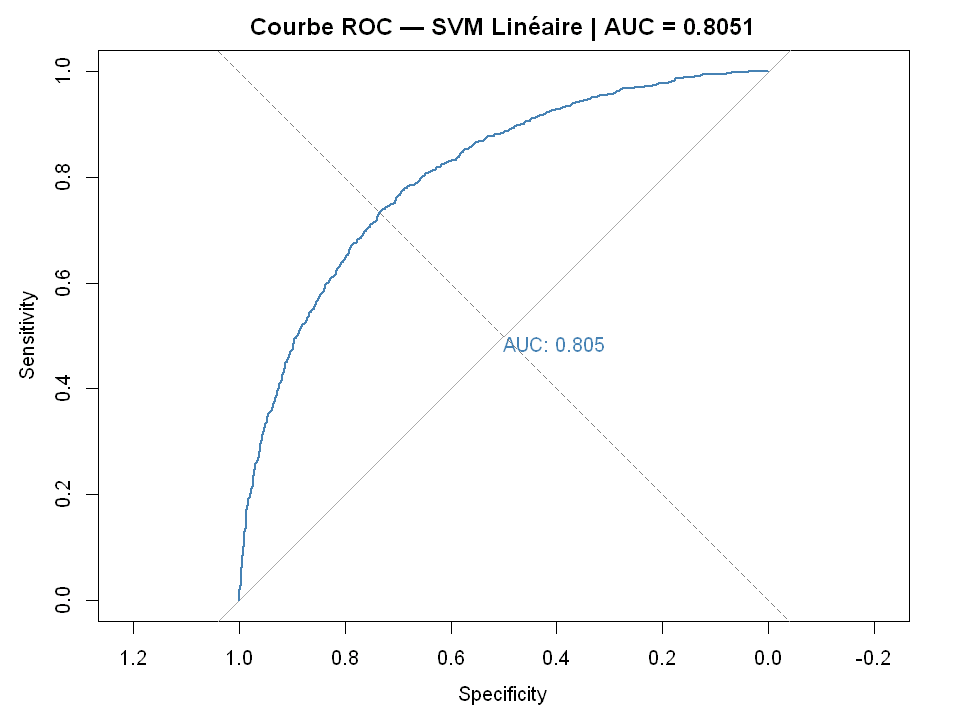

In [ ]:
cat("\n>>> Évaluation sur le jeu de test...\n")

# 1. On aligne les labels de y_test avec ceux du modèle
y_test_factor <- factor(
  y_test,
  levels = c(0, 1),
  labels = c("No", "Yes")
)

# Prédictions (classes + probabilités)
pred_svm.lin       <- predict(svm.lin.final, newdata = datestppq, probability = TRUE)
pred_svm.lin.proba <- attr(pred_svm.lin, "probabilities")

# Matrice de confusion
cat("\n--- Matrice de confusion ---\n")
conf_matrix <- confusionMatrix(
  pred_svm.lin,    # Déjà sous forme "No"/"Yes"
  y_test_factor    # Converti en "No"/"Yes"
)
print(conf_matrix)

# Métriques détaillées
accuracy  <- conf_matrix$overall["Accuracy"]
precision <- conf_matrix$byClass["Pos Pred Value"]
recall    <- conf_matrix$byClass["Sensitivity"]
f1        <- conf_matrix$byClass["F1"]
kappa     <- conf_matrix$overall["Kappa"]

cat("\n--- Métriques de performance ---\n")
cat(paste("Accuracy  :", round(accuracy,  4), "\n"))
cat(paste("Precision :", round(precision, 4), "\n"))
cat(paste("Recall    :", round(recall,    4), "\n"))
cat(paste("F1-Score  :", round(f1,        4), "\n"))
cat(paste("Kappa     :", round(kappa,     4), "\n"))

# Courbe ROC & AUC
# On récupère la probabilité de la classe positive ("Yes")
pos_class      <- levels(y_test_factor)[2]
proba_positive <- pred_svm.lin.proba[, pos_class]

roc_svm.lin <- roc(
  response  = y_test_factor,
  predictor = proba_positive,
  levels    = levels(y_test_factor)
)

cat(paste("\n>>> AUC :", round(auc(roc_svm.lin), 4), "\n"))

plot(roc_svm.lin,
     col  = "steelblue",
     lwd  = 2,
     main = paste("Courbe ROC — SVM Linéaire | AUC =", round(auc(roc_svm.lin), 4)),
     print.auc = TRUE)
abline(a = 0, b = 1, lty = 2, col = "gray50")

### 3.3 Prévision par arbre binaire de discrimination

Nous allons réaliser une prévision par **arbre de décision binaire (CART)**. Puisque `Heart_Disease_Risk` est une variable qualitative binaire, on estime un **arbre de discrimination**.

> **Note :** Les arbres sont invariants aux changements d'échelle. On utilise `datappq` / `datestq` pour la cohérence avec les autres modèles du notebook.

#### 3.3.1 Estimation et élagage de l'arbre de discrimination

##### 3.3.1.1 Critère : indice de Gini

On construit d'abord un arbre complet (paramètre `cp` très petit), puis on l'**élague par validation croisée** en sélectionnant le `cp` qui minimise l'erreur CV estimée (`xerror`).

In [77]:
set.seed(111)

# Arbre complet (critère Gini)
# cp=0.001 : arbre peu contraint (grand), méthode "class" pour la discrimination
tree.dis.full <- rpart(
  Heart_Disease_Risk ~ .,
  data    = datappq,
  method  = "class",
  parms   = list(split = "gini"),
  control = rpart.control(cp = 0.001)
)

# Tableau de complexité : colonnes nsplit, rel error, xerror (erreur CV), xstd
printcp(tree.dis.full)


Classification tree:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, method = "class", 
    parms = list(split = "gini"), control = rpart.control(cp = 0.001))

Variables actually used in tree construction:
 [1] Age                     BMI                     Cholesterol_HDL        
 [4] Cholesterol_LDL         Cholesterol_Total       Diastolic_BP           
 [7] Family_History          Fasting_Blood_Sugar     Height_cm              
[10] Physical_Activity_Level Sleep_Hours             Smoking_Status         
[13] Stress_Level            Systolic_BP             Weight_kg              

Root node error: 5260/12000 = 0.43833

n= 12000 

          CP nsplit rel error  xerror      xstd
1  0.2815589      0   1.00000 1.00000 0.0103335
2  0.0374525      1   0.71844 0.71844 0.0096733
3  0.0066540      2   0.68099 0.68099 0.0095300
4  0.0050063      3   0.67433 0.68517 0.0095467
5  0.0047529      6   0.65932 0.68042 0.0095277
6  0.0045627      7   0.65456 0.67814 0.0095185
7  0.0039449 

Nombre de feuilles : 47 


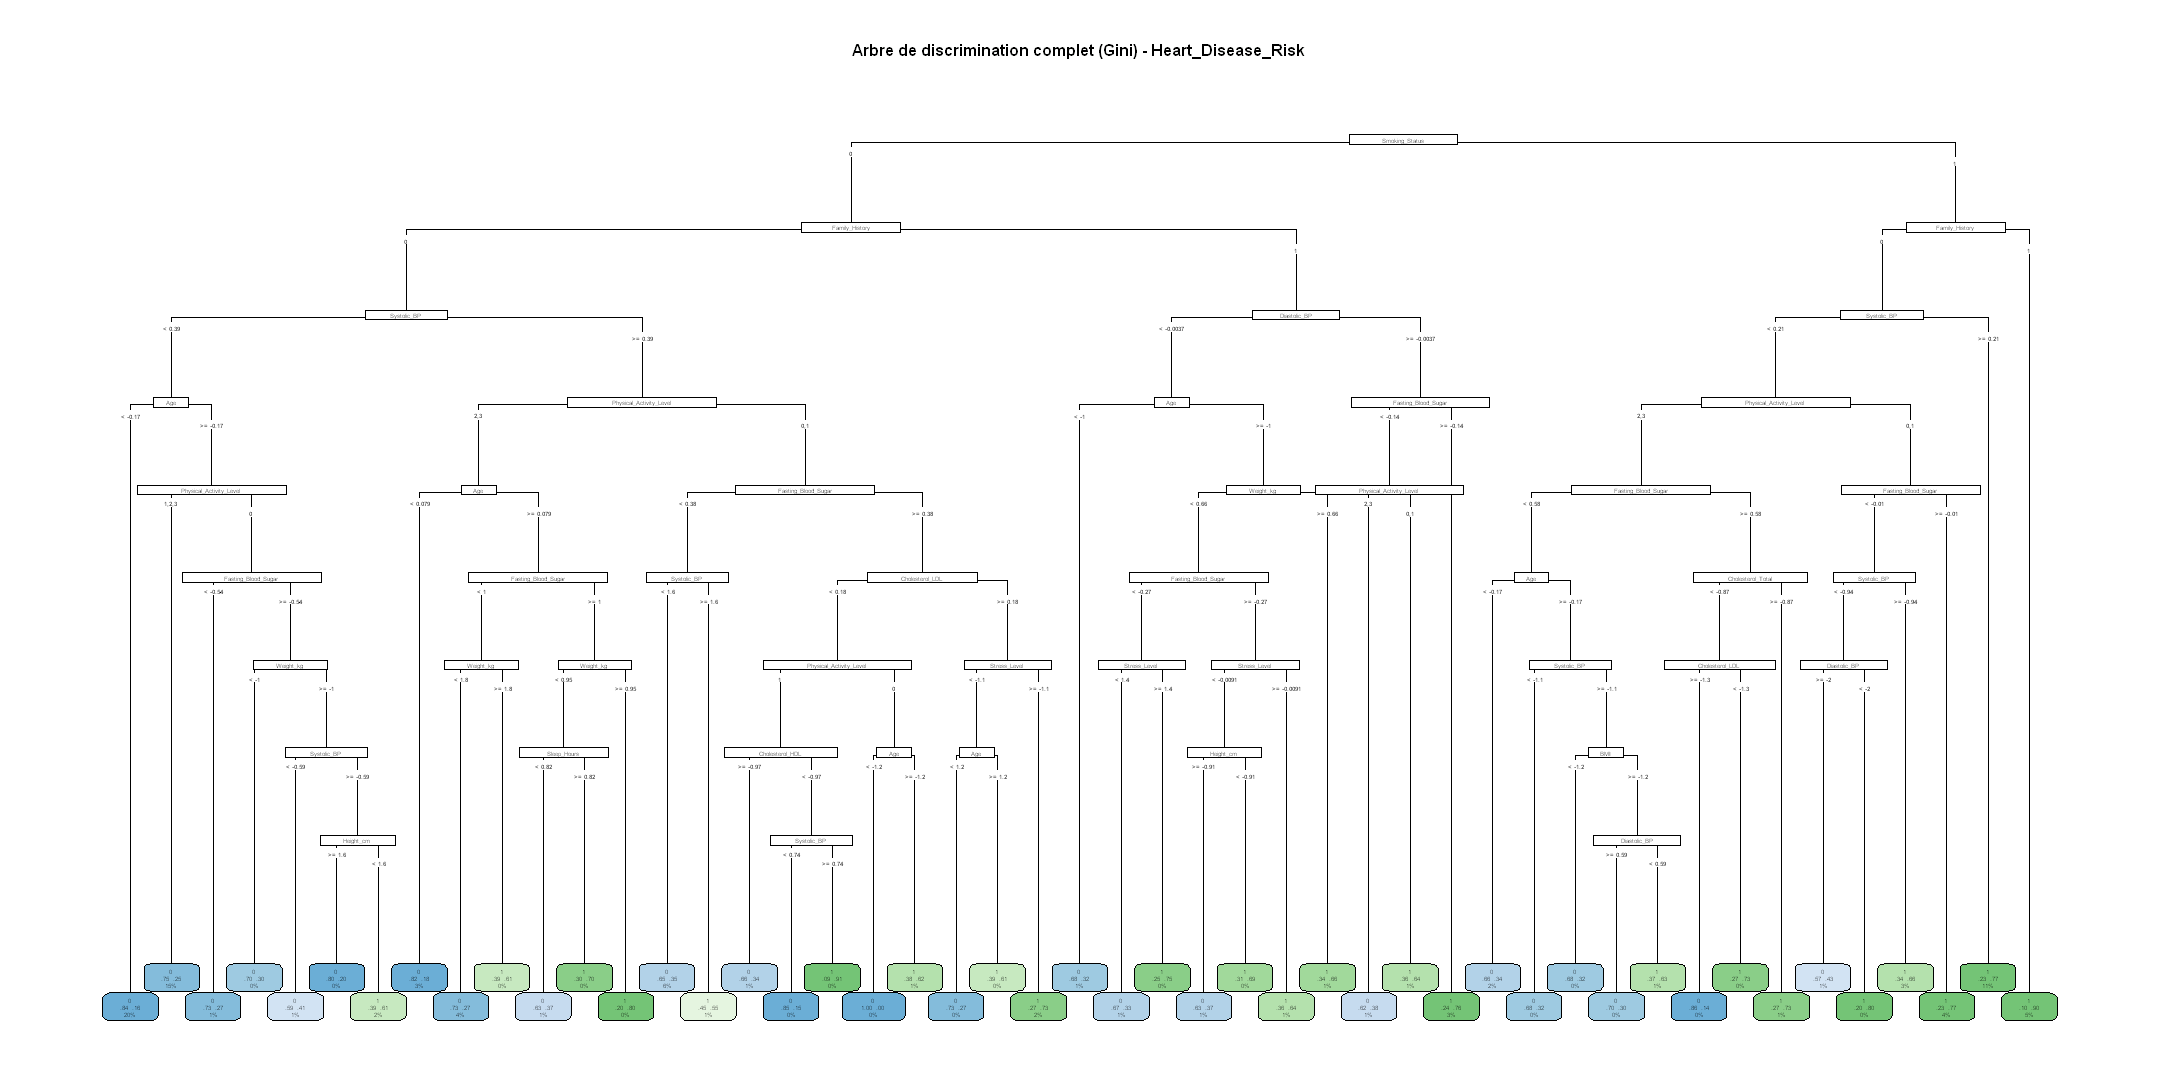

In [78]:
cat("Nombre de feuilles :", sum(tree.dis.full$frame$var == "<leaf>"), "\n") # 47 feuilles

# Visualisation de l'arbre complet (47 feuilles)
# type=5 : affiche la probabilité de classe ; extra=104 : proba + effectif
options(repr.plot.width = 18, repr.plot.height = 9)
rpart.plot( # 47 feuilles
  tree.dis.full,
  type  = 5,
  extra = 104,
  main  = "Arbre de discrimination complet (Gini) - Heart_Disease_Risk"
)

cp optimal (Gini) : 0.001330798 
Nombre de feuilles : 29 


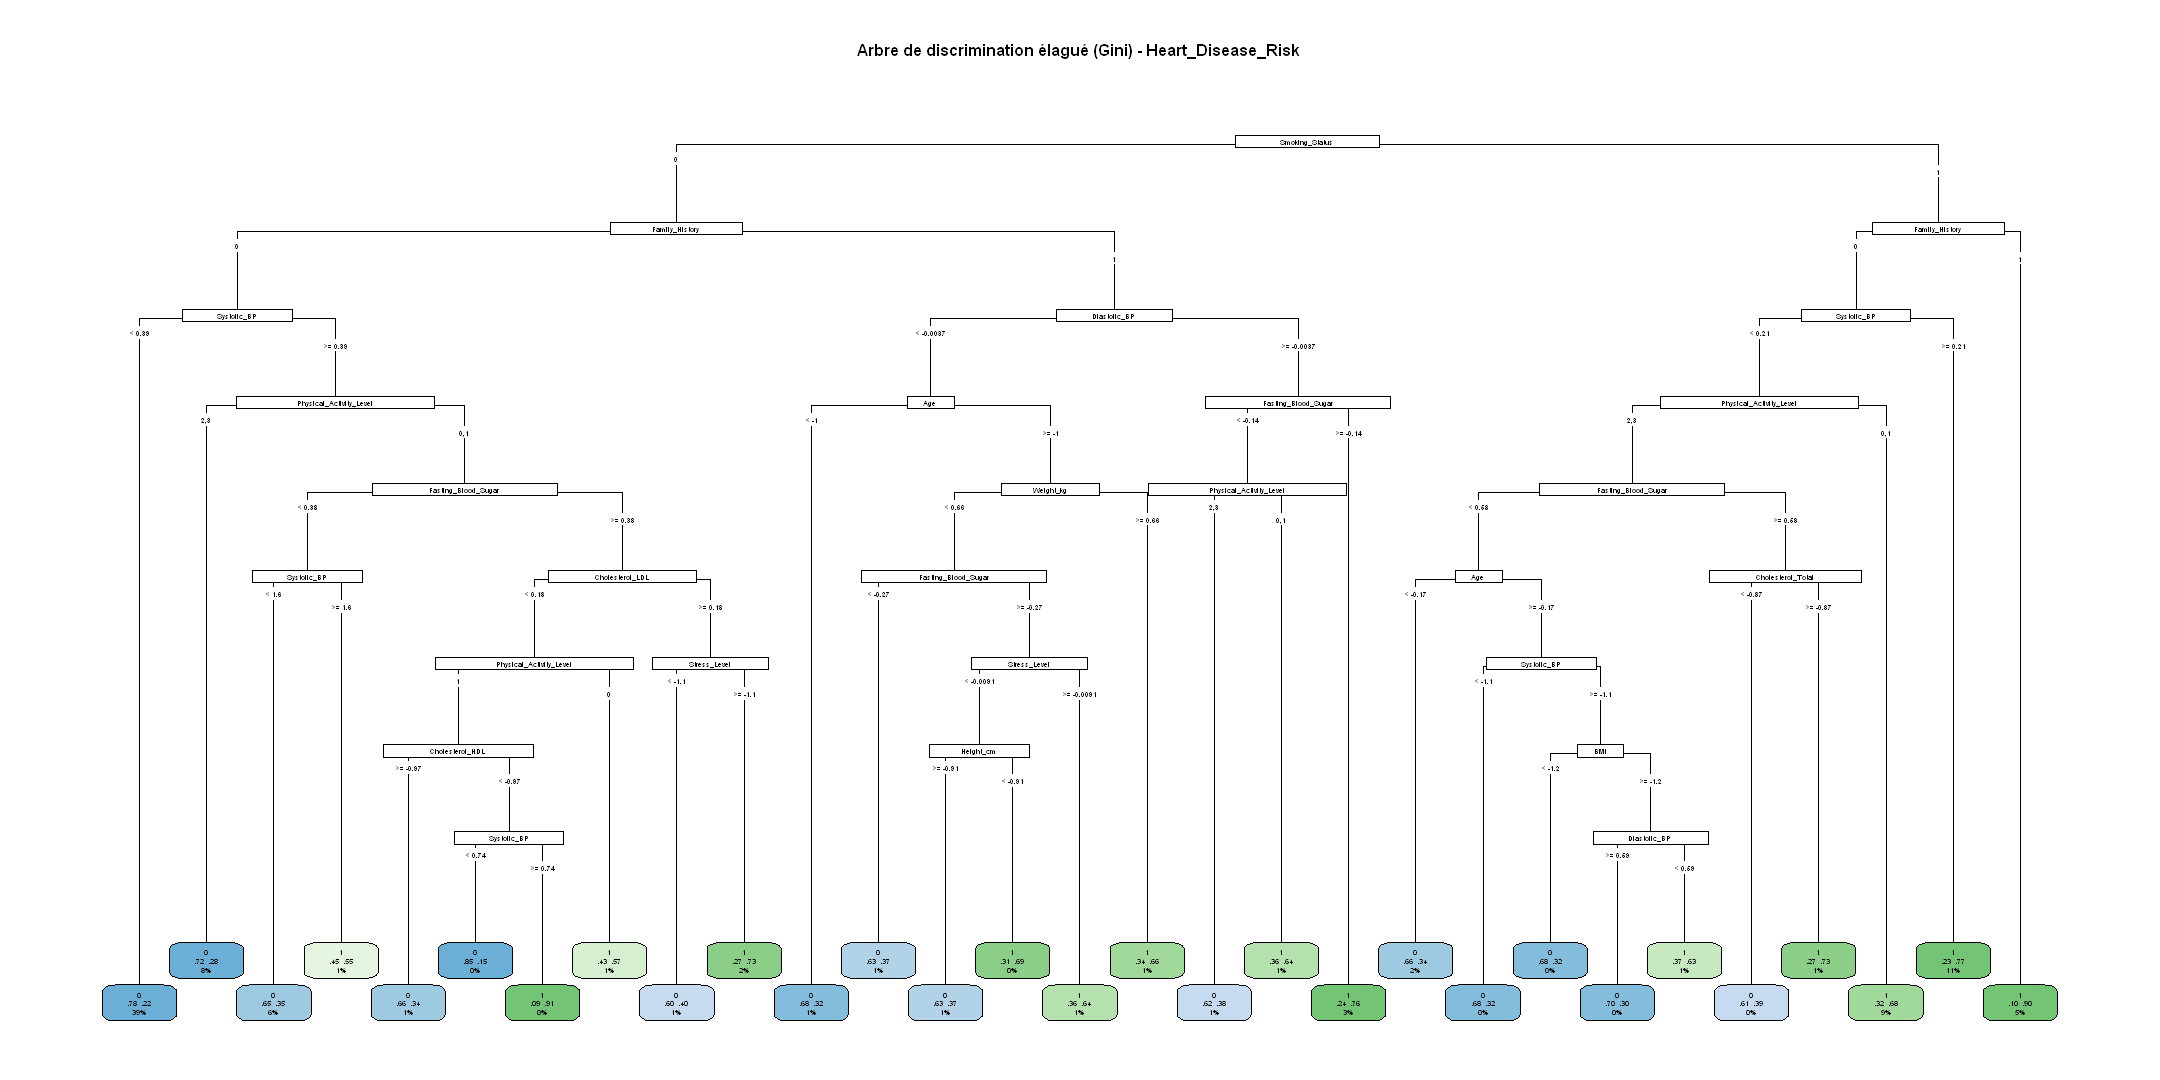

In [79]:
# Élagage par validation croisée
# On sélectionne le cp qui minimise l'erreur de validation croisée (xerror)
opt_cp_dis <- tree.dis.full$cptable[which.min(tree.dis.full$cptable[, "xerror"]), "CP"]
cat("cp optimal (Gini) :", opt_cp_dis, "\n")

# Élagage de l'arbre
tree.dis.gini <- prune(tree.dis.full, cp = opt_cp_dis)

cat("Nombre de feuilles :", sum(tree.dis.gini$frame$var == "<leaf>"), "\n") # 29 feuilles

# Visualisation de l'arbre élagué
# type=5 : affiche la probabilité de classe ; extra=104 : proba + effectif
options(repr.plot.width = 18, repr.plot.height = 9)
rpart.plot(
  tree.dis.gini,
  type  = 5,
  extra = 104,
  main  = "Arbre de discrimination élagué (Gini) - Heart_Disease_Risk"
)

##### 3.3.1.2 Critère : entropie (information gain)

On refait l'estimation avec le critère d'**entropie** pour le comparer à Gini.

cp optimal (Entropie) : 0.001140684 
Nombre de feuilles : 34 


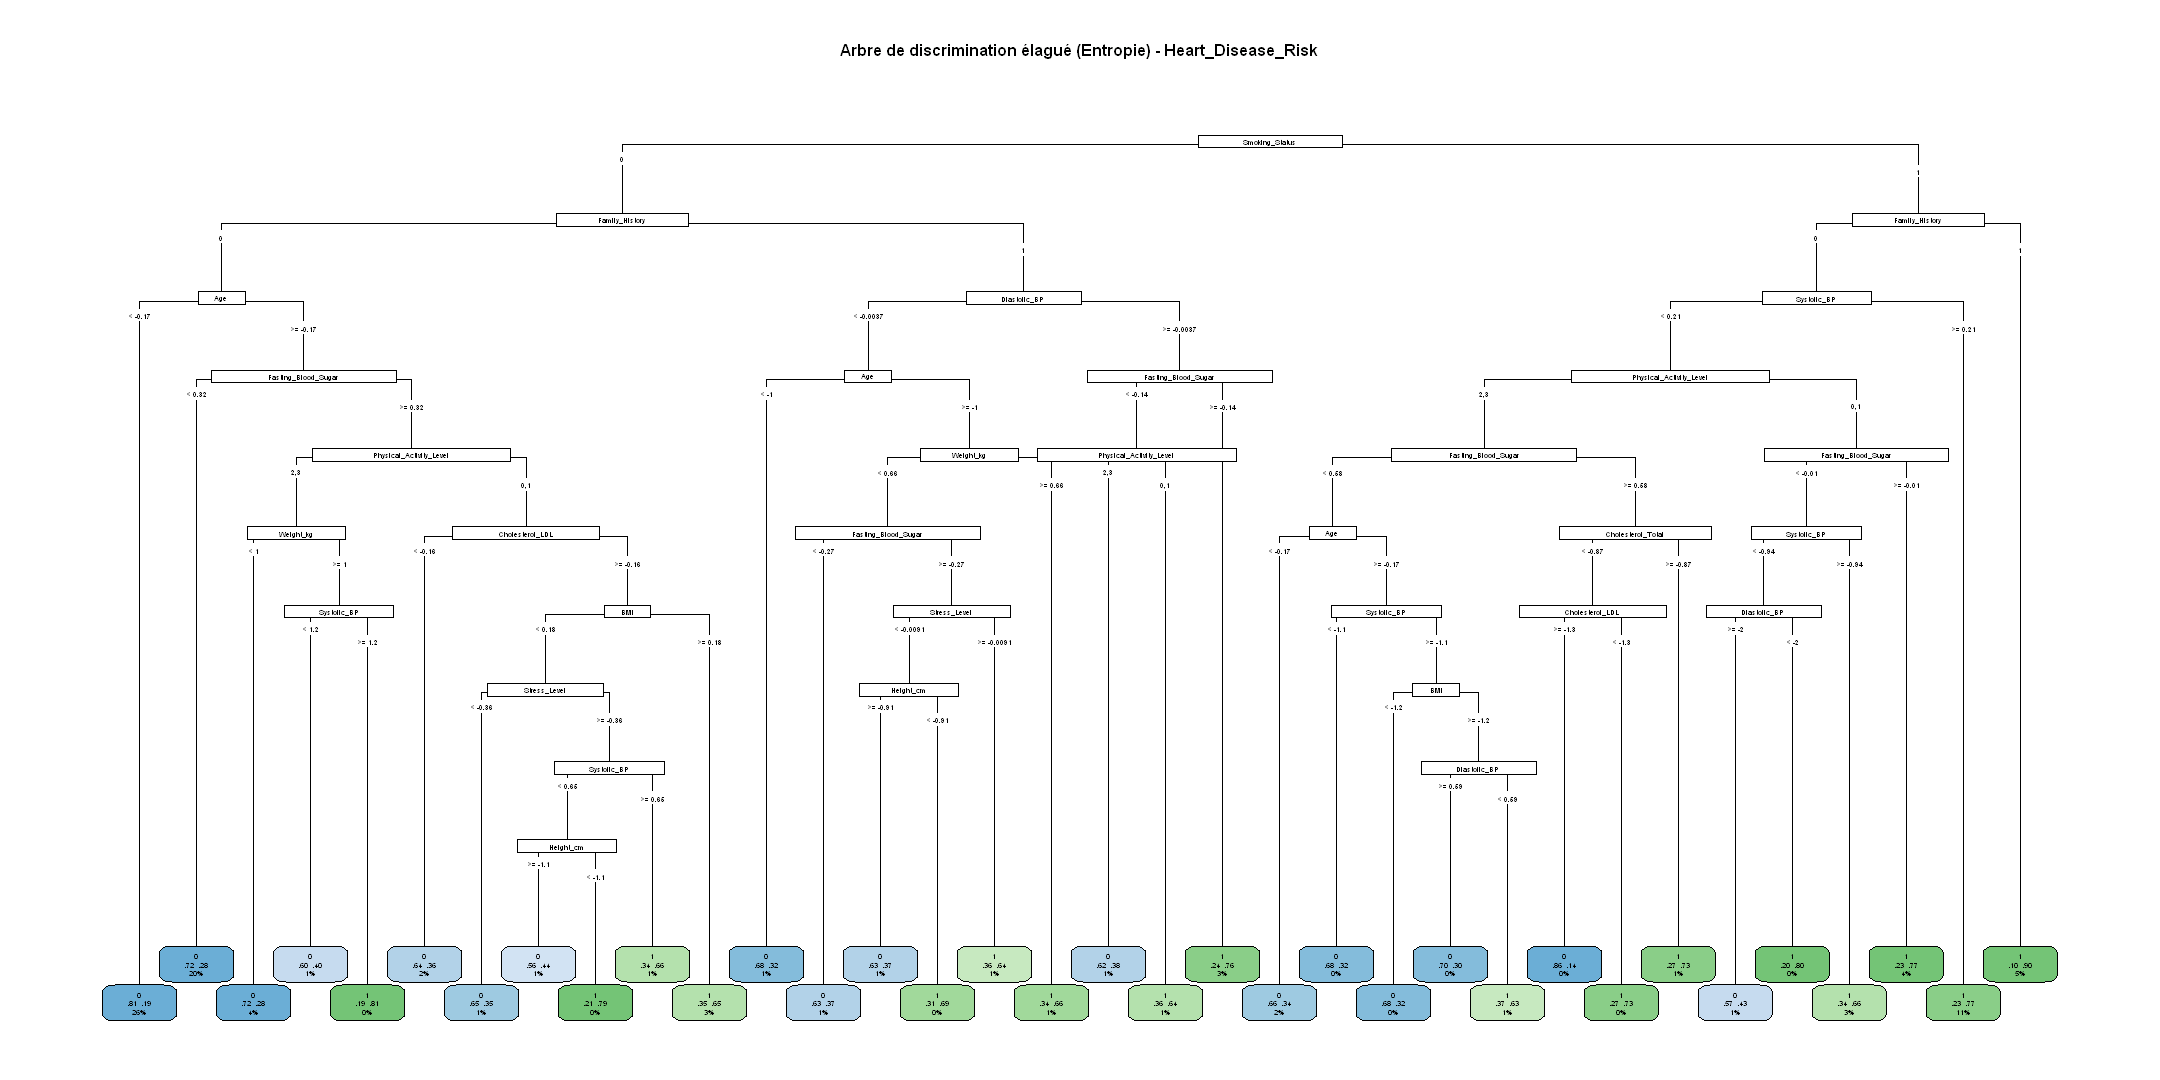

In [81]:
# Arbre complet (critère entropie)
tree.dis.ent.full <- rpart(
  Heart_Disease_Risk ~ .,
  data    = datappq,
  method  = "class",
  parms   = list(split = "information"),
  control = rpart.control(cp = 0.001)
)

opt_cp_ent <- tree.dis.ent.full$cptable[which.min(tree.dis.ent.full$cptable[, "xerror"]), "CP"]
cat("cp optimal (Entropie) :", opt_cp_ent, "\n")

tree.dis.ent <- prune(tree.dis.ent.full, cp = opt_cp_ent)

cat("Nombre de feuilles :", sum(tree.dis.ent$frame$var == "<leaf>"), "\n") # 39 feuilles

options(repr.plot.width = 18, repr.plot.height = 9)
rpart.plot(
  tree.dis.ent,
  type  = 5,
  extra = 104,
  main  = "Arbre de discrimination élagué (Entropie) - Heart_Disease_Risk"
)

Comparaison entre Gini et entropie

In [82]:
printcp(tree.dis.ent)

print("-------------------------")

printcp(tree.dis.gini)


Classification tree:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, method = "class", 
    parms = list(split = "information"), control = rpart.control(cp = 0.001))

Variables actually used in tree construction:
 [1] Age                     BMI                     Cholesterol_LDL        
 [4] Cholesterol_Total       Diastolic_BP            Family_History         
 [7] Fasting_Blood_Sugar     Height_cm               Physical_Activity_Level
[10] Smoking_Status          Stress_Level            Systolic_BP            
[13] Weight_kg              

Root node error: 5260/12000 = 0.43833

n= 12000 

          CP nsplit rel error  xerror      xstd
1  0.2815589      0   1.00000 1.00000 0.0103335
2  0.0374525      1   0.71844 0.71844 0.0096733
3  0.0066540      2   0.68099 0.68099 0.0095300
4  0.0045627      3   0.67433 0.68118 0.0095307
5  0.0044677      4   0.66977 0.67624 0.0095107
6  0.0039924      8   0.65190 0.67471 0.0095045
7  0.0039449      9   0.64791 0.67148 0.0094913
8  0.0

In [83]:
print("Gini :")
tree.dis.gini$frame$var
print("Entropie :")
tree.dis.ent$frame$var


print("Gini :")
unique(as.character(tree.dis.gini$frame$var[tree.dis.gini$frame$var != "<leaf>"]))
print("Entropie :")
unique(as.character(tree.dis.ent$frame$var[tree.dis.ent$frame$var != "<leaf>"]))


[1] "Gini :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Systolic_BP"             "<leaf>"                 
 [5] "Physical_Activity_Level" "<leaf>"                 
 [7] "Fasting_Blood_Sugar"     "Systolic_BP"            
 [9] "<leaf>"                  "<leaf>"                 
[11] "Cholesterol_LDL"         "Physical_Activity_Level"
[13] "Cholesterol_HDL"         "<leaf>"                 
[15] "Systolic_BP"             "<leaf>"                 
[17] "<leaf>"                  "<leaf>"                 
[19] "Stress_Level"            "<leaf>"                 
[21] "<leaf>"                  "Diastolic_BP"           
[23] "Age"                     "<leaf>"                 
[25] "Weight_kg"               "Fasting_Blood_Sugar"    
[27] "<leaf>"                  "Stress_Level"           
[29] "Height_cm"               "<leaf>"                 
[31] "<leaf>"                  "<leaf>"                 
[33] "<leaf>"                  "Fasting_Blood_Sugar"    
[35] "Physical_Activity_Level" "<leaf>"                 
[37] "<leaf>"                  "<leaf>"                 
[39] "Family_History"          "Systolic_BP"            
[41] "Physical_Activity_Level" "Fasting_Blood_Sugar"    
[43] "Age"                     "<leaf>"                 
[45] "Systolic_BP"             "<leaf>"                 
[47] "BMI"                     "<leaf>"                 
[49] "Diastolic_BP"            "<leaf>"                 
[51] "<leaf>"                  "Cholesterol_Total"      
[53] "<leaf>"                  "<leaf>"                 
[55] "<leaf>"                  "<leaf>"                 
[57] "<leaf>"

[1] "Entropie :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Age"                     "<leaf>"                 
 [5] "Fasting_Blood_Sugar"     "<leaf>"                 
 [7] "Physical_Activity_Level" "Weight_kg"              
 [9] "<leaf>"                  "Systolic_BP"            
[11] "<leaf>"                  "<leaf>"                 
[13] "Cholesterol_LDL"         "<leaf>"                 
[15] "BMI"                     "Stress_Level"           
[17] "<leaf>"                  "Systolic_BP"            
[19] "Height_cm"               "<leaf>"                 
[21] "<leaf>"                  "<leaf>"                 
[23] "<leaf>"                  "Diastolic_BP"           
[25] "Age"                     "<leaf>"                 
[27] "Weight_kg"               "Fasting_Blood_Sugar"    
[29] "<leaf>"                  "Stress_Level"           
[31] "Height_cm"               "<leaf>"                 
[33] "<leaf>"                  "<leaf>"                 
[35] "<leaf>"                  "Fasting_Blood_Sugar"    
[37] "Physical_Activity_Level" "<leaf>"                 
[39] "<leaf>"                  "<leaf>"                 
[41] "Family_History"          "Systolic_BP"            
[43] "Physical_Activity_Level" "Fasting_Blood_Sugar"    
[45] "Age"                     "<leaf>"                 
[47] "Systolic_BP"             "<leaf>"                 
[49] "BMI"                     "<leaf>"                 
[51] "Diastolic_BP"            "<leaf>"                 
[53] "<leaf>"                  "Cholesterol_Total"      
[55] "Cholesterol_LDL"         "<leaf>"                 
[57] "<leaf>"                  "<leaf>"                 
[59] "Fasting_Blood_Sugar"     "Systolic_BP"            
[61] "Diastolic_BP"            "<leaf>"                 
[63] "<leaf>"                  "<leaf>"                 
[65] "<leaf>"                  "<leaf>"                 
[67] "<leaf>"

[1] "Gini :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Systolic_BP"             "Physical_Activity_Level"
 [5] "Fasting_Blood_Sugar"     "Cholesterol_LDL"        
 [7] "Cholesterol_HDL"         "Stress_Level"           
 [9] "Diastolic_BP"            "Age"                    
[11] "Weight_kg"               "Height_cm"              
[13] "BMI"                     "Cholesterol_Total"

[1] "Entropie :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Age"                     "Fasting_Blood_Sugar"    
 [5] "Physical_Activity_Level" "Weight_kg"              
 [7] "Systolic_BP"             "Cholesterol_LDL"        
 [9] "BMI"                     "Stress_Level"           
[11] "Height_cm"               "Diastolic_BP"           
[13] "Cholesterol_Total"

#### 3.3.2 Prévision de l'échantillon test

##### 3.3.2.1 Taux de mal classés et matrices de confusion

In [84]:
# Taux d'erreur et matrices de confusion sur le test
pred_gini_test <- predict(tree.dis.gini,     datestq, type = "class")
pred_ent_test  <- predict(tree.dis.ent, datestq, type = "class")

err_gini_test <- mean(pred_gini_test != datestq$Heart_Disease_Risk)
err_ent_test  <- mean(pred_ent_test  != datestq$Heart_Disease_Risk)

cat(sprintf("Taux d'erreur test - Gini    : %.4f  (accuracy = %.4f)\n",
            err_gini_test, 1 - err_gini_test))
cat(sprintf("Taux d'erreur test - Entropie: %.4f  (accuracy = %.4f)\n",
            err_ent_test,  1 - err_ent_test))

cat("\nMatrice de confusion (Gini) :\n")
print(table(Prédit = pred_gini_test, Observé = datestq$Heart_Disease_Risk))

cat("\nMatrice de confusion (Entropie) :\n")
print(table(Prédit = pred_ent_test, Observé = datestq$Heart_Disease_Risk))

Taux d'erreur test - Gini    : 0.2793  (accuracy = 0.7207)
Taux d'erreur test - Entropie: 0.2723  (accuracy = 0.7277)

Matrice de confusion (Gini) :
      Observé
Prédit    0    1
     0 1392  510
     1  328  770

Matrice de confusion (Entropie) :
      Observé
Prédit    0    1
     0 1406  503
     1  314  777


##### 3.3.2.2 Courbes ROC

AUC - Gini    : 0.7520
AUC - Entropie: 0.7613


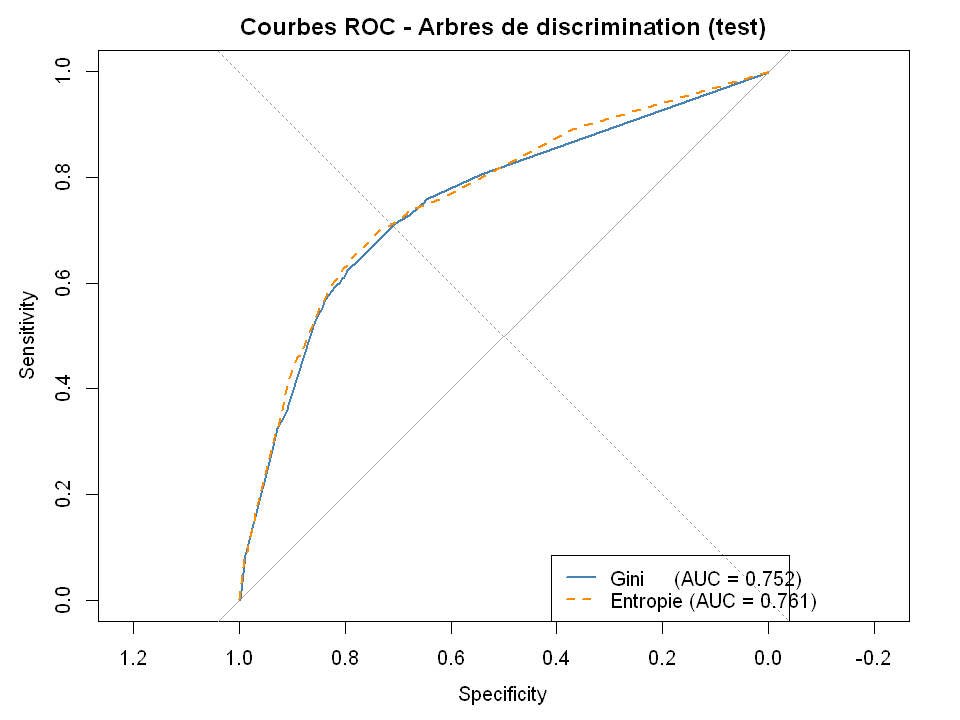

In [85]:
# Courbes ROC
# predict(..., type="prob") : probabilité estimée d'appartenir à la classe 1
prob_gini_test <- predict(tree.dis.gini,     datestq, type = "prob")[, 2]
prob_ent_test  <- predict(tree.dis.ent, datestq, type = "prob")[, 2]

roc_gini <- roc(datestq$Heart_Disease_Risk, prob_gini_test, quiet = TRUE)
roc_ent  <- roc(datestq$Heart_Disease_Risk, prob_ent_test,  quiet = TRUE)

cat(sprintf("AUC - Gini    : %.4f\n", auc(roc_gini)))
cat(sprintf("AUC - Entropie: %.4f\n", auc(roc_ent)))

options(repr.plot.width = 8, repr.plot.height = 6)
plot(roc_gini, col = "steelblue", lwd = 2,
     main = "Courbes ROC - Arbres de discrimination (test)")
lines(roc_ent, col = "darkorange", lwd = 2, lty = 2)
abline(a = 0, b = 1, lty = 3, col = "grey60")
legend("bottomright",
       legend = c(sprintf("Gini     (AUC = %.3f)", auc(roc_gini)),
                  sprintf("Entropie (AUC = %.3f)", auc(roc_ent))),
       col = c("steelblue", "darkorange"), lwd = 2, lty = c(1, 2))

#### 3.3.3 Importance des variables

L'importance d'une variable dans `rpart` est la **réduction totale de l'indice de Gini** qu'elle génère, pondérée par la proportion d'observations passant par chaque nœud.

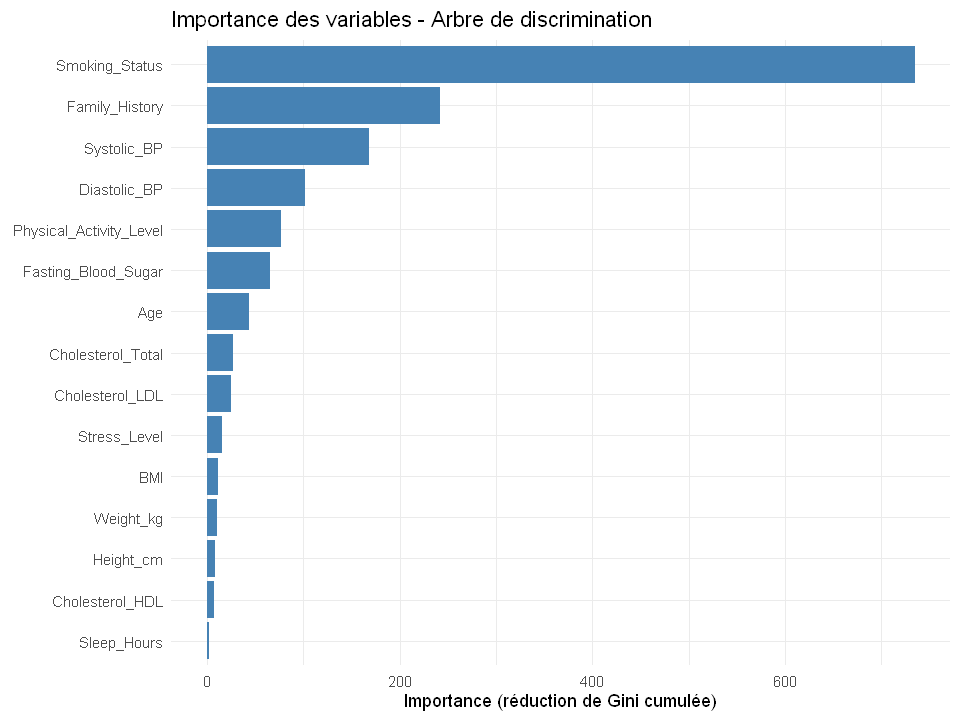

In [86]:
# Importance des variables (arbre de discrimination)
imp_dis <- tree.dis.gini$variable.importance
imp_dis_df <- data.frame(
  variable   = names(imp_dis),
  importance = as.numeric(imp_dis)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_dis_df, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction de Gini cumulée)",
       title = "Importance des variables - Arbre de discrimination") +
  theme_minimal()

#### 3.4.5 Bilan - Arbre binaire de discrimination (`Heart_Disease_Risk`)

In [87]:
# Tableau récapitulatif (discrimination)
resultats_dis <- data.frame(
  Modele    = c("Arbre CART Gini (élagué)",
                "Arbre CART Entropie (élagué)"),
  Erreur    = round(c(err_gini_test, err_ent_test), 4),
  Accuracy  = round(c(1-err_gini_test, 1-err_ent_test), 4),
  AUC       = round(c(as.numeric(auc(roc_gini)),
                      as.numeric(auc(roc_ent))), 4)
)
print(resultats_dis)

# L'arbre CART est plus interprétable (règles de décision lisibles dans le graphe).
# La forêt réduit la variance par agrégation de B=100 arbres, au prix
# de l'interprétabilité (mais l'importance des variables reste disponible).

                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2723   0.7277 0.7613


### 3.4 Prévision par forêt aléatoire - Discrimination (`Heart_Disease_Risk`)

Une **forêt aléatoire** agrège $B$ arbres entraînés sur des sous-échantillons **bootstrap** (**bagging**). À chaque nœud, seul un sous-ensemble de $m$ variables est tiré au sort (**feature subsampling**), ce qui décolle les arbres et réduit la variance.

**Hyperparamètres :**
- `ntree` : nombre d'arbres $B$
- `mtry` : nombre de variables candidates à chaque nœud ($m \approx \sqrt{p}$ en discrimination)
- `nodesize` : taille minimale d'une feuille

#### 3.4.1 Analyse de convergence (erreur OOB)

L'erreur **OOB** (*Out-Of-Bag*) est estimée gratuitement : chaque arbre est évalué sur les ~37% d'observations non tirées dans son bootstrap. C'est un estimateur fiable de l'erreur de généralisation.

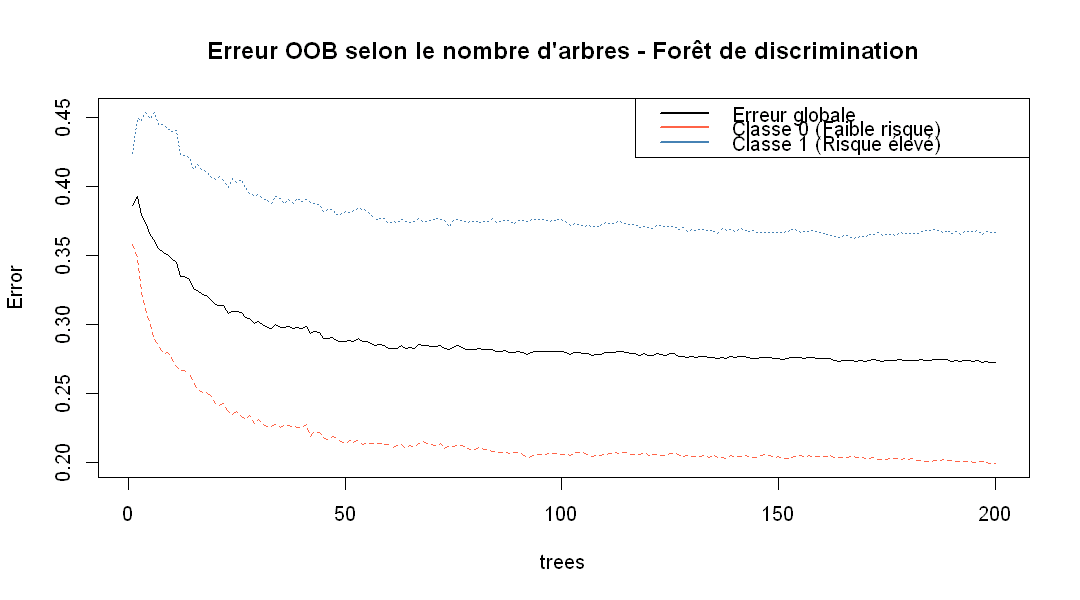

In [88]:
# Convergence de l'erreur OOB
set.seed(111)
rf.dis.conv <- randomForest(
  Heart_Disease_Risk ~ .,
  data     = datappq, # utilisation de data plutot que datappq pour voir la convergence sur l'ensemble des données (et OOB donc déjà séparation et évaluation sur l'ensemble des données)
  ntree    = 200,
  mtry     = floor(sqrt(ncol(datappq) - 1)),  # sqrt(p) : règle empirique
  nodesize = 1
)

# La courbe doit se stabiliser : on choisit ntree à partir duquel
# l'erreur OOB ne diminue plus significativement.
options(repr.plot.width = 9, repr.plot.height = 5)
plot(rf.dis.conv,
     main = "Erreur OOB selon le nombre d'arbres - Forêt de discrimination",
     col  = c("black", "tomato", "steelblue"))
legend("topright",
       legend = c("Erreur globale", "Classe 0 (Faible risque)", "Classe 1 (Risque élevé)"),
       col    = c("black", "tomato", "steelblue"), lwd = 2)

#### 3.4.2 Optimisation de `mtry`

  mtry oob_erreur
1    2  0.2790833
2    4  0.2802500
3    5  0.2790833
4    8  0.2782500
5   17  0.2835833

mtry optimal : 8  (erreur OOB = 0.2782)


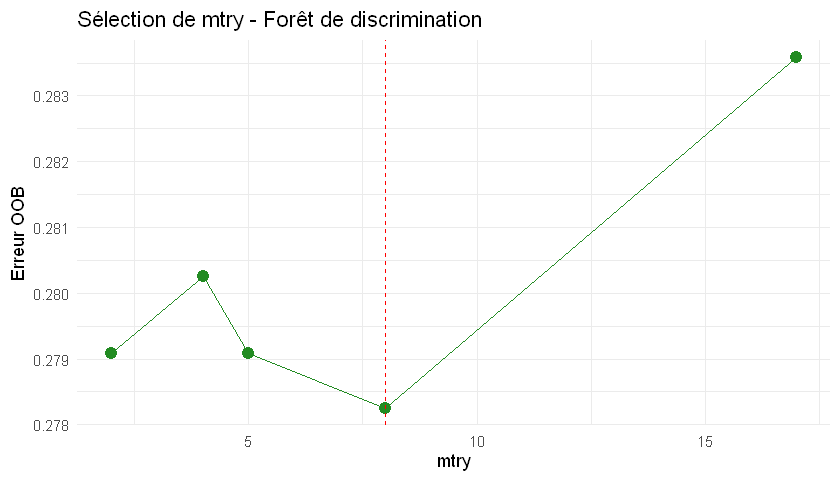

In [89]:
# Sélection de mtry par erreur OOB
# On teste plusieurs valeurs de mtry et on retient celle qui minimise l'erreur OOB.
set.seed(111)
p_dis <- ncol(datappq) - 1  # nombre de variables explicatives

mtry_vals <- sort(unique(c(
  2,
  floor(sqrt(p_dis)),    # ~sqrt(p) : règle empirique discrimination
  floor(p_dis / 3),
  floor(p_dis / 2),
  p_dis                  # bagging pur
)))

oob_err_mtry <- sapply(mtry_vals, function(m) {
  rf <- randomForest(Heart_Disease_Risk ~ ., data = datappq,
                     ntree = 100, mtry = m, nodesize = 1)
  tail(rf$err.rate[, "OOB"], 1)
})

df_mtry_dis <- data.frame(mtry = mtry_vals, oob_erreur = oob_err_mtry)
print(df_mtry_dis)

best_mtry_dis <- mtry_vals[which.min(oob_err_mtry)]
cat(sprintf("\nmtry optimal : %d  (erreur OOB = %.4f)\n",
            best_mtry_dis, min(oob_err_mtry)))

options(repr.plot.width = 7, repr.plot.height = 4)
ggplot(df_mtry_dis, aes(x = mtry, y = oob_erreur)) +
  geom_line(colour = "forestgreen") + geom_point(colour = "forestgreen", size = 3) +
  geom_vline(xintercept = best_mtry_dis, linetype = "dashed", colour = "red") +
  labs(x = "mtry", y = "Erreur OOB",
       title = "Sélection de mtry - Forêt de discrimination") +
  theme_minimal()

In [90]:
# Modèle final (forêt de discrimination)
set.seed(111)
rf.dis <- randomForest(
  Heart_Disease_Risk ~ .,
  data       = datappq,
  ntree      = 100,
  mtry       = best_mtry_dis,
  nodesize   = 1,
  importance = TRUE   # active le calcul des deux mesures d'importance
)

print(rf.dis)
cat(sprintf("Accuracy OOB : %.4f\n", 1 - tail(rf.dis$err.rate[, "OOB"], 1)))


Call:
 randomForest(formula = Heart_Disease_Risk ~ ., data = datappq,      ntree = 100, mtry = best_mtry_dis, nodesize = 1, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 100
No. of variables tried at each split: 8

        OOB estimate of  error rate: 27.8%
Confusion matrix:
     0    1 class.error
0 5367 1373   0.2037092
1 1963 3297   0.3731939
Accuracy OOB : 0.7220


#### 3.4.3 Évaluation sur l'échantillon test

In [91]:
# Prédictions test
pred_rf_dis_test <- predict(rf.dis, datestq, type = "class")
prob_rf_dis_test <- predict(rf.dis, datestq, type = "prob")[, 2]

err_rf_dis <- mean(pred_rf_dis_test != datestq$Heart_Disease_Risk)
cat(sprintf("Taux d'erreur test - Forêt : %.4f  (accuracy = %.4f)\n",
            err_rf_dis, 1 - err_rf_dis))

cat("\nMatrice de confusion (Forêt) :\n")
print(table(Prédit = pred_rf_dis_test, Observé = datestq$Heart_Disease_Risk))

roc_rf_dis <- roc(datestq$Heart_Disease_Risk, prob_rf_dis_test, quiet = TRUE)
cat(sprintf("AUC - Forêt : %.4f\n", auc(roc_rf_dis)))

Taux d'erreur test - Forêt : 0.2660  (accuracy = 0.7340)

Matrice de confusion (Forêt) :
      Observé
Prédit    0    1
     0 1376  454
     1  344  826
AUC - Forêt : 0.7886


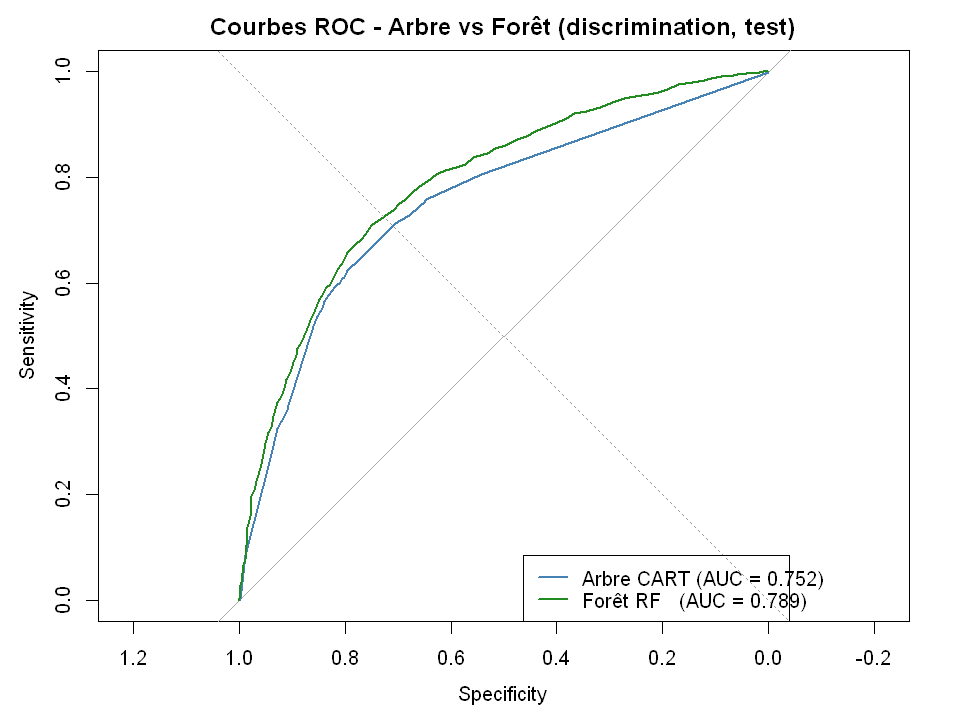

In [92]:
# Courbe ROC : Arbre vs Forêt
options(repr.plot.width = 8, repr.plot.height = 6)
plot(roc_gini,   col = "steelblue",    lwd = 2,
     main = "Courbes ROC - Arbre vs Forêt (discrimination, test)")
lines(roc_rf_dis, col = "forestgreen", lwd = 2)
abline(a = 0, b = 1, lty = 3, col = "grey60")
legend("bottomright",
       legend = c(sprintf("Arbre CART (AUC = %.3f)", auc(roc_gini)),
                  sprintf("Forêt RF   (AUC = %.3f)", auc(roc_rf_dis))),
       col = c("steelblue", "forestgreen"), lwd = 2)

#### 3.4.4 Importance des variables

La forêt fournit deux mesures, plus stables que celle de l'arbre seul car moyennées sur $B$ arbres :
- **MeanDecreaseAccuracy** : chute d'accuracy OOB lors d'une permutation aléatoire de la variable
- **MeanDecreaseGini** : réduction totale de l'indice de Gini apportée par la variable

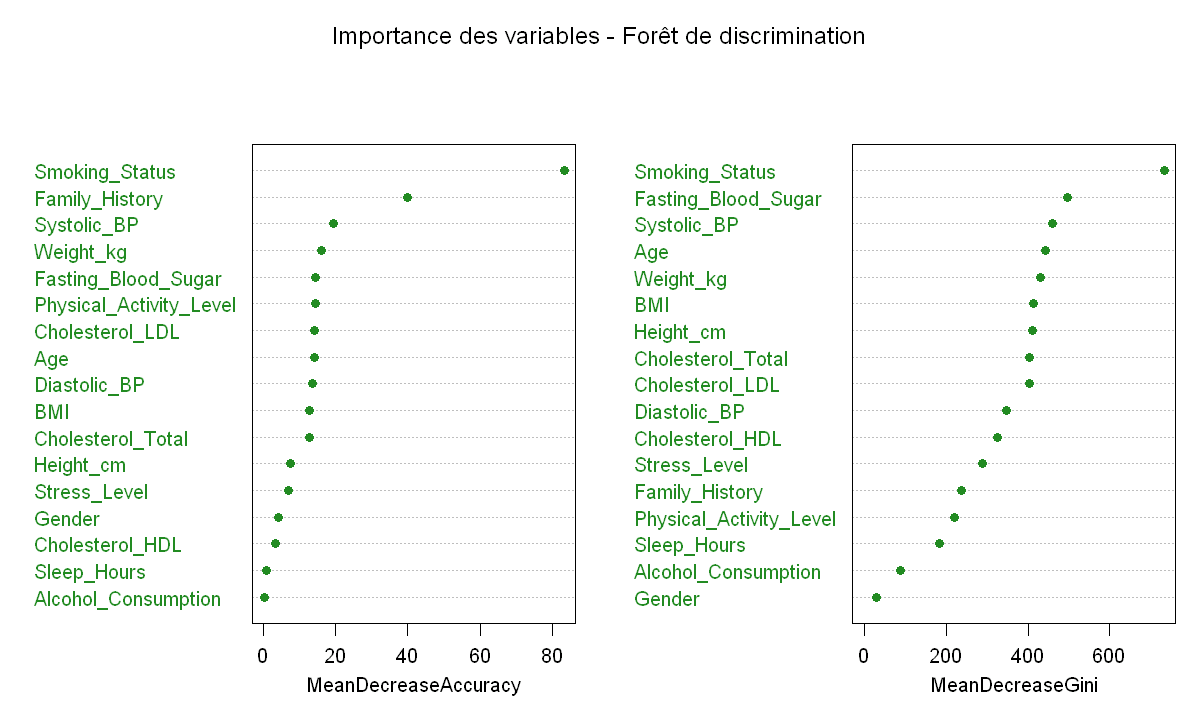

In [93]:
# Graphe d'importance des variables (forêt)
options(repr.plot.width = 10, repr.plot.height = 6)
varImpPlot(
  rf.dis,
  main  = "Importance des variables - Forêt de discrimination",
  col   = "forestgreen",
  pch   = 16
)

#### 3.4.5 Bilan - Discrimination forêt aléatoire (`Heart_Disease_Risk`)

In [94]:
# Tableau récapitulatif (discrimination)
resultats_dis <- data.frame(
  Modele    = c("Forêt aléatoire"),
  Erreur    = round(c(err_rf_dis), 4),
  Accuracy  = round(c(1-err_rf_dis), 4),
  AUC       = round(c(as.numeric(auc(roc_rf_dis))), 4)
)
print(resultats_dis)

# L'arbre CART est plus interprétable (règles de décision lisibles dans le graphe).
# La forêt réduit la variance par agrégation de B=100 arbres, au prix
# de l'interprétabilité (mais l'importance des variables reste disponible).

           Modele Erreur Accuracy    AUC
1 Forêt aléatoire  0.266    0.734 0.7886


### 3.4 Prévision par Boosting
Le **boosting** est une méthode d'ensemble qui construit les arbres **séquentiellement** : chaque nouvel arbre corrige les erreurs du modèle précédent. Contrairement aux forêts (arbres indépendants en parallèle), le boosting réduit principalement le **biais**.

On utilise la librairie **`gbm`** (*Gradient Boosting Machines*), qui implémente le **gradient boosting** de Friedman (2001).

**Hyperparamètres principaux :**
- `n.trees` : nombre d'arbres $B$ — sélectionné par **validation croisée interne** (`cv.folds`)
- `shrinkage` : taux d'apprentissage $\lambda$ (typiquement entre 0.01 et 0.1) — plus il est petit, plus il faut d'arbres
- `interaction.depth` : profondeur maximale de chaque arbre individuel (captures des interactions entre variables)
- `n.minobsinnode` : taille minimale d'un nœud terminal (régularisation)

> **Note :** Shrinkage faible + grand `n.trees` donnent généralement de meilleures performances, au prix d'un temps de calcul plus élevé. La validation croisée interne permet de choisir automatiquement `n.trees` pour chaque combinaison d'hyperparamètres.

Pour la classification binaire, `gbm` utilise par défaut la **déviance de Bernoulli** comme fonction de perte (`distribution = "bernoulli"`). Le modèle produit des scores (log-odds) qu'on transforme en probabilités via la fonction logistique.

In [95]:
# on transforme les variables de risque cardiaque en numérique (0 et 1) pour le GBM (as.factor --> {0,1})
datappq_boosting <- datappq
datestq_boosting <- datestq

# (on passe par as.character pour être sûr que le texte "0" devient le chiffre 0, et "1" devient 1)
datappq_boosting$Heart_Disease_Risk <- as.numeric(as.character(datappq_boosting$Heart_Disease_Risk))
datestq_boosting$Heart_Disease_Risk <- as.numeric(as.character(datestq_boosting$Heart_Disease_Risk))

Nombre optimal d'arbres (CV) : 271


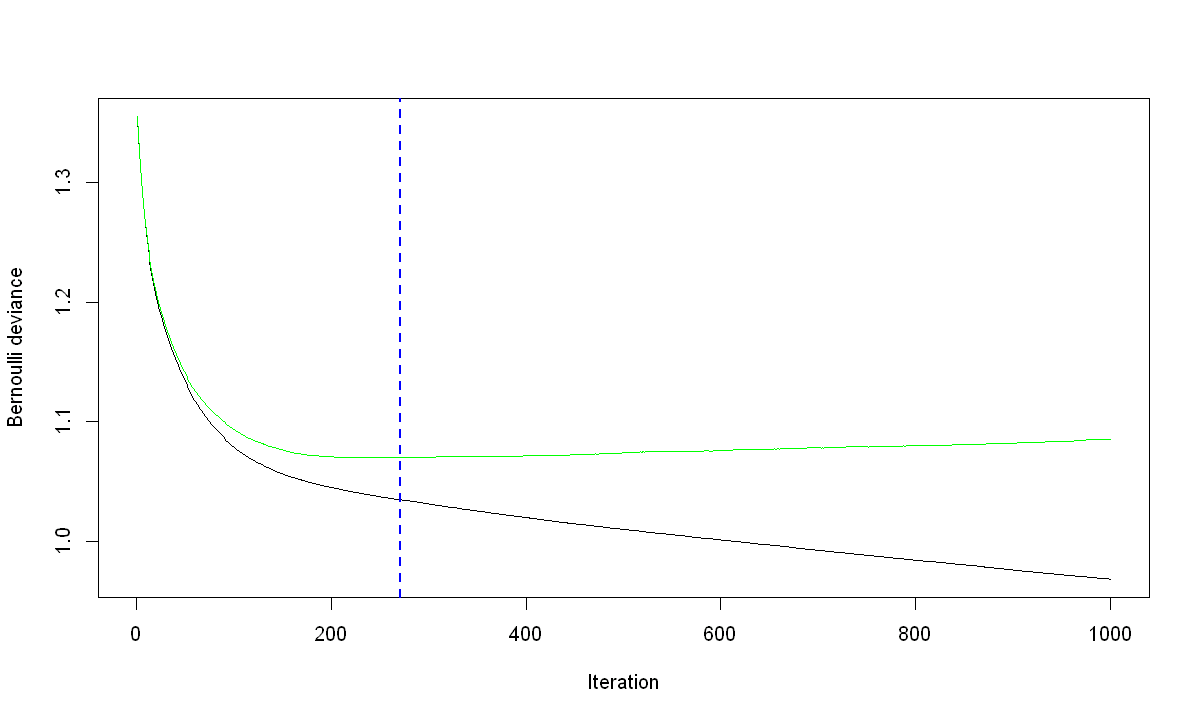

In [96]:
# -- Estimation du modèle de boosting (discrimination) ------------------------
# distribution="bernoulli" : perte de Bernoulli pour la classification binaire
# cv.folds=5 : validation croisée interne pour choisir n.trees
# shrinkage=0.05 : taux d'apprentissage modéré
# interaction.depth=3 : arbres de profondeur 3 (captures les interactions d'ordre 3)
# n.minobsinnode=10 : régularisation minimale des feuilles
set.seed(111)
boost.dis <- gbm(
  Heart_Disease_Risk ~ .,
  data              = datappq_boosting,
  distribution      = "bernoulli",
  n.trees           = 1000,
  interaction.depth = 3,
  shrinkage         = 0.05,
  n.minobsinnode    = 10,
  cv.folds          = 5,
  verbose           = FALSE
)

# Nombre optimal d'arbres selon la CV (minimise la déviance CV)
best_iter_dis <- gbm.perf(boost.dis, method = "cv", plot.it = TRUE)
cat(sprintf("Nombre optimal d'arbres (CV) : %d\n", best_iter_dis))

#### 4.1.2 Optimisation des hyperparamètres

On effectue une recherche sur grille (*grid search*) pour les hyperparamètres clés : `interaction.depth` et `shrinkage`. Pour chaque combinaison, on relit le nombre optimal d'arbres par CV.

In [97]:
# IL FAUDRAIT PAS METTRE N.TREES = 271 quelque part

# Grid search sur interaction.depth et shrinkage
# On teste des combinaisons de profondeur et de taux d'apprentissage.
# Pour chaque combinaison, gbm sélectionne automatiquement n.trees par CV.
set.seed(111)

depths    <- c(1, 3, 5)        # profondeur des arbres individuels
shrink    <- c(0.01, 0.05, 0.1)  # taux d'apprentissage

grid_dis <- expand.grid(depth = depths, shrinkage = shrink)
grid_dis$n_trees_opt <- NA
grid_dis$cv_error    <- NA

for (i in seq_len(nrow(grid_dis))) {
  d <- grid_dis$depth[i]
  s <- grid_dis$shrinkage[i]

  # n.trees plus grand quand le taux d'apprentissage est petit
  ntrees_max <- ifelse(s <= 0.01, 3000, ifelse(s <= 0.05, 1500, 800))

  fit <- gbm(
    Heart_Disease_Risk ~ .,
    data              = datappq_boosting,
    distribution      = "bernoulli",
    n.trees           = ntrees_max,
    interaction.depth = d,
    shrinkage         = s,
    n.minobsinnode    = 10,
    cv.folds          = 5,
    verbose           = FALSE
  )
  best_n          <- gbm.perf(fit, method = "cv", plot.it = FALSE)
  grid_dis$n_trees_opt[i] <- best_n
  grid_dis$cv_error[i]    <- fit$cv.error[best_n]
}

print(grid_dis[order(grid_dis$cv_error), ])

# Meilleure combinaison
best_row_dis <- which.min(grid_dis$cv_error)
cat(sprintf("\nMeilleure configuration :\n"))
cat(sprintf("  interaction.depth = %d\n",    grid_dis$depth[best_row_dis]))
cat(sprintf("  shrinkage         = %.2f\n",  grid_dis$shrinkage[best_row_dis]))
cat(sprintf("  n.trees optimal   = %d\n",    grid_dis$n_trees_opt[best_row_dis]))

  depth shrinkage n_trees_opt cv_error
7     1      0.10         272 1.064035
1     1      0.01        2902 1.065096
4     1      0.05         526 1.065319
5     3      0.05         300 1.067942
2     3      0.01        1526 1.068334
3     5      0.01        1029 1.069922
8     3      0.10         106 1.071056
6     5      0.05         187 1.073357
9     5      0.10          77 1.074084

Meilleure configuration :
  interaction.depth = 1
  shrinkage         = 0.10
  n.trees optimal   = 272


In [98]:
# Modèle final de boosting (discrimination)
set.seed(111)
boost.dis.final <- gbm(
  Heart_Disease_Risk ~ .,
  data              = datappq_boosting,
  distribution      = "bernoulli",
  n.trees           = grid_dis$n_trees_opt[best_row_dis],
  interaction.depth = grid_dis$depth[best_row_dis],
  shrinkage         = grid_dis$shrinkage[best_row_dis],
  n.minobsinnode    = 10,
  verbose           = FALSE
)

cat("Modèle de boosting final entraîné.\n")
print(boost.dis.final)

Modèle de boosting final entraîné.
gbm(formula = Heart_Disease_Risk ~ ., distribution = "bernoulli", 
    data = datappq_boosting, n.trees = grid_dis$n_trees_opt[best_row_dis], 
    interaction.depth = grid_dis$depth[best_row_dis], n.minobsinnode = 10, 
    shrinkage = grid_dis$shrinkage[best_row_dis], verbose = FALSE)
A gradient boosted model with bernoulli loss function.
272 iterations were performed.
There were 17 predictors of which 16 had non-zero influence.


#### 4.1.3 Évaluation sur l'échantillon test

In [99]:
# Prédictions sur le test
# type="response" : renvoie directement des probabilités (après transformation logistique)
prob_boost_dis_test <- predict(
  boost.dis.final, datestq_boosting,
  n.trees = grid_dis$n_trees_opt[best_row_dis],
  type    = "response"
)

# Seuil de classification à 0.5
pred_boost_dis_test <- ifelse(prob_boost_dis_test >= 0.5, 1, 0)

err_boost_dis <- mean(pred_boost_dis_test != datestq$Heart_Disease_Risk)
cat(sprintf("Taux d'erreur test — Boosting : %.4f  (accuracy = %.4f)\n",
            err_boost_dis, 1 - err_boost_dis))

cat("\nMatrice de confusion (Boosting) :\n")
print(table(Prédit = pred_boost_dis_test, Observé = datestq_boosting$Heart_Disease_Risk))

roc_boost_dis <- roc(datestq$Heart_Disease_Risk, prob_boost_dis_test, quiet = TRUE)
cat(sprintf("AUC — Boosting : %.4f\n", auc(roc_boost_dis)))

Taux d'erreur test — Boosting : 0.2567  (accuracy = 0.7433)

Matrice de confusion (Boosting) :
      Observé
Prédit    0    1
     0 1394  444
     1  326  836
AUC — Boosting : 0.8059


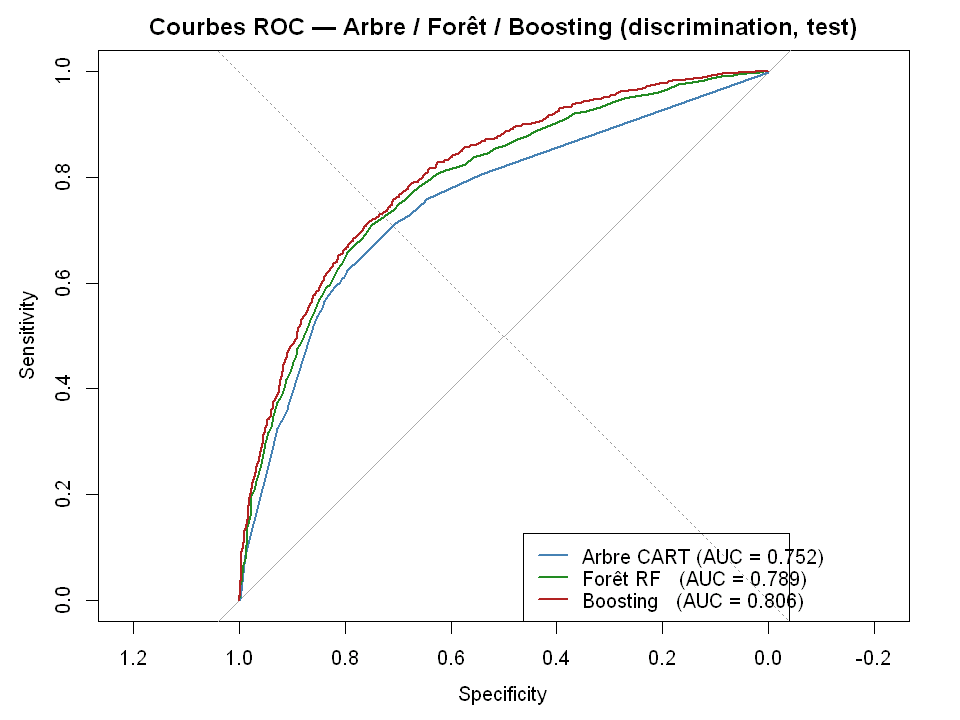

In [100]:
# Courbe ROC : Arbre vs Forêt vs Boosting
options(repr.plot.width = 8, repr.plot.height = 6)
plot(roc_gini,       col = "steelblue",   lwd = 2,
     main = "Courbes ROC — Arbre / Forêt / Boosting (discrimination, test)")
lines(roc_rf_dis,    col = "forestgreen", lwd = 2)
lines(roc_boost_dis, col = "firebrick",   lwd = 2)
abline(a = 0, b = 1, lty = 3, col = "grey60")
legend("bottomright",
       legend = c(sprintf("Arbre CART (AUC = %.3f)", auc(roc_gini)),
                  sprintf("Forêt RF   (AUC = %.3f)", auc(roc_rf_dis)),
                  sprintf("Boosting   (AUC = %.3f)", auc(roc_boost_dis))),
       col = c("steelblue", "forestgreen", "firebrick"), lwd = 2)

#µ### 4.1.4 Importance des variables (boosting discrimination)

Dans `gbm`, l'importance d'une variable est la **réduction totale de la fonction de perte** qu'elle génère, moyennée sur tous les arbres.

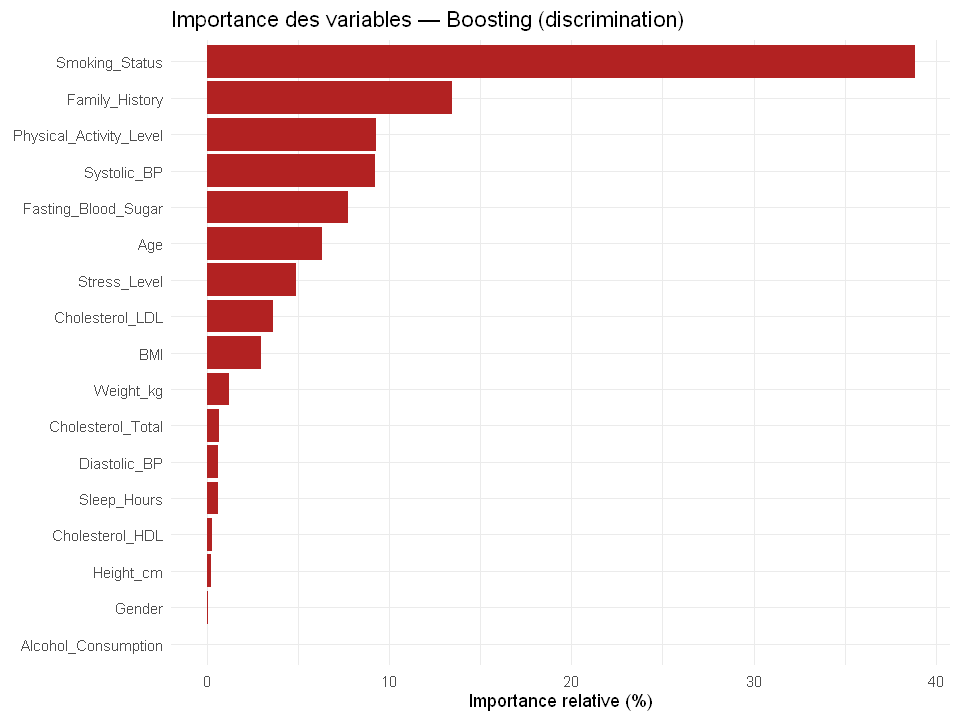

In [101]:
# Importance des variables
imp_boost_dis <- summary(
  boost.dis.final,
  n.trees    = grid_dis$n_trees_opt[best_row_dis],
  plotit     = FALSE
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_boost_dis, aes(x = reorder(var, rel.inf), y = rel.inf)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance relative (%)",
       title = "Importance des variables — Boosting (discrimination)") +
  theme_minimal()

#### 4.1.5 Bilan - Discrimination (`Heart_Disease_Risk`)

In [102]:
# Tableau récapitulatif mis à jour (discrimination)
resultats_dis_complet <- data.frame(
  Modele   = c("Arbre CART Gini (élagué)",
               "Arbre CART Entropie (élagué)",
               "Forêt aléatoire",
               "Boosting (gbm)"),
  Erreur   = round(c(err_gini_test, err_ent_test, err_rf_dis, err_boost_dis), 4),
  Accuracy = round(1 - c(err_gini_test, err_ent_test, err_rf_dis, err_boost_dis), 4),
  AUC      = round(c(as.numeric(auc(roc_gini)),
                     as.numeric(auc(roc_ent)),
                     as.numeric(auc(roc_rf_dis)),
                     as.numeric(auc(roc_boost_dis))), 4)
)
print(resultats_dis_complet)

                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2723   0.7277 0.7613
3              Forêt aléatoire 0.2660   0.7340 0.7886
4               Boosting (gbm) 0.2567   0.7433 0.8059


In [103]:
# Tableau récapitulatif (discrimination)
resultats_dis <- data.frame(
  Modele    = c("Arbre CART Gini (élagué)",
                "Arbre CART Entropie (élagué)",
                "Forêt aléatoire"),
  Erreur    = round(c(err_gini_test, err_ent_test, err_rf_dis), 4),
  Accuracy  = round(c(1-err_gini_test, 1-err_ent_test, 1-err_rf_dis), 4),
  AUC       = round(c(as.numeric(auc(roc_gini)),
                      as.numeric(auc(roc_ent)),
                      as.numeric(auc(roc_rf_dis))), 4)
)
print(resultats_dis)

# L'arbre CART est plus interprétable (règles de décision lisibles dans le graphe).
# La forêt réduit la variance par agrégation de B=100 arbres, au prix
# de l'interprétabilité (mais l'importance des variables reste disponible).

                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2723   0.7277 0.7613
3              Forêt aléatoire 0.2660   0.7340 0.7886


### 3.5 Prévision par réseaux de neurones

Nous entraînons un réseau de neurones à une couche cachée via la fonction nnet en R.  
L'ajustement des hyperparamètres porte sur deux paramètres clés : size (nombre de neurones dans la couche cachée) et decay (paramètre de régularisation L2, contrôlant le surapprentissage).  La recherche des hyperparamètres optimaux se déroule en deux étapes : une optimisation grossière explorant un large espace de paramètres, suivie d'une optimisation fine resserrée autour des meilleures valeurs identifiées. Le modèle final est ensuite entraîné avec les paramètres optimaux et ses performances sont estimées sur l'échantillon test.

In [105]:
# Pour classification (Heart_Disease_Risk prediction)
datappr_classif <- datappr  # already scaled
datappr_classif$Heart_Disease_Risk <- as.factor(data[appri, 19])

datestr_classif <- datestr
datestr_classif$Heart_Disease_Risk <- as.factor(data[testi, 19])

# Supprimer Patient_ID des deux datasets
datappr_classif$Patient_ID <- NULL
datestr_classif$Patient_ID <- NULL

str(datappr)
str(datestr)


'data.frame':	12000 obs. of  17 variables:
 $ Age                    : num  0.455 -0.13 0.622 1.541 -0.214 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  -2.006 -0.384 1.021 0.868 -0.623 ...
 $ Weight_kg              : num  -1.701 0.104 1.232 -0.445 -1.059 ...
 $ BMI                    : num  -0.882 0.463 0.707 -1.103 -0.907 ...
 $ Systolic_BP            : num  0.4318 -0.6293 0.5202 0.0781 -0.0987 ...
 $ Diastolic_BP           : num  -0.181 -1.125 1.118 0.646 0.173 ...
 $ Cholesterol_Total      : num  0.034 -0.583 -1.904 -1.023 0.386 ...
 $ Cholesterol_LDL        : num  0.593 -1.189 -0.911 -1.301 0.815 ...
 $ Cholesterol_HDL        : num  1.461 -0.889 0.286 0.286 0.789 ...
 $ Fasting_Blood_Sugar    : num  -1.094 1.074 -0.634 -1.226 0.22 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Act

In [107]:
# Vérifier la nature et les niveaux
class(datappr_classif$Heart_Disease_Risk) # changement data_ppr par datappr
levels(datappr_classif$Heart_Disease_Risk)


[1] "factor"

[1] "0" "1"

#### 3.5.1 Première optimisation grossière

Cette première optimisation explore large espace des hyperparamètres pour identifier les zones prometteuses où l'erreur de validation croisée est minimale.  

Deux hyperparamètres sont optimisés dans cette étape. 
* Le premier est size, qui correspond au nombre de neurones dans la couche cachée du réseau.
* Le second est decay, un paramètre de régularisation L2 qui permet de lutter contre le surapprentissage.
 
Quatre valeurs sont testées pour chaque paramètre : 2, 5, 8 et 10 pour size ; 0.001, 0.01, 0.1 et 1 pour decay.


Parameter tuning of 'nnet':

- sampling method: 5-fold cross validation 

- best parameters:
 size decay
    2  0.01

- best performance: 0.2631667 

- Detailed performance results:
   size decay     error  dispersion
1     2 0.001 0.2667500 0.011205158
2     5 0.001 0.2707500 0.007525420
3     8 0.001 0.2780000 0.008172404
4    10 0.001 0.2857500 0.008246422
5     2 0.010 0.2631667 0.009747685
6     5 0.010 0.2678333 0.011005838
7     8 0.010 0.2761667 0.005029427
8    10 0.010 0.2840000 0.007262441
9     2 0.100 0.2660000 0.010187479
10    5 0.100 0.2666667 0.007833998
11    8 0.100 0.2739167 0.005225804
12   10 0.100 0.2770833 0.007389228
13    2 1.000 0.2636667 0.008855515
14    5 1.000 0.2661667 0.009097275
15    8 1.000 0.2686667 0.007554202
16   10 1.000 0.2712500 0.004592793


,size,decay
,<dbl>,<dbl>
5,2,0.01


[1] 0.2631667

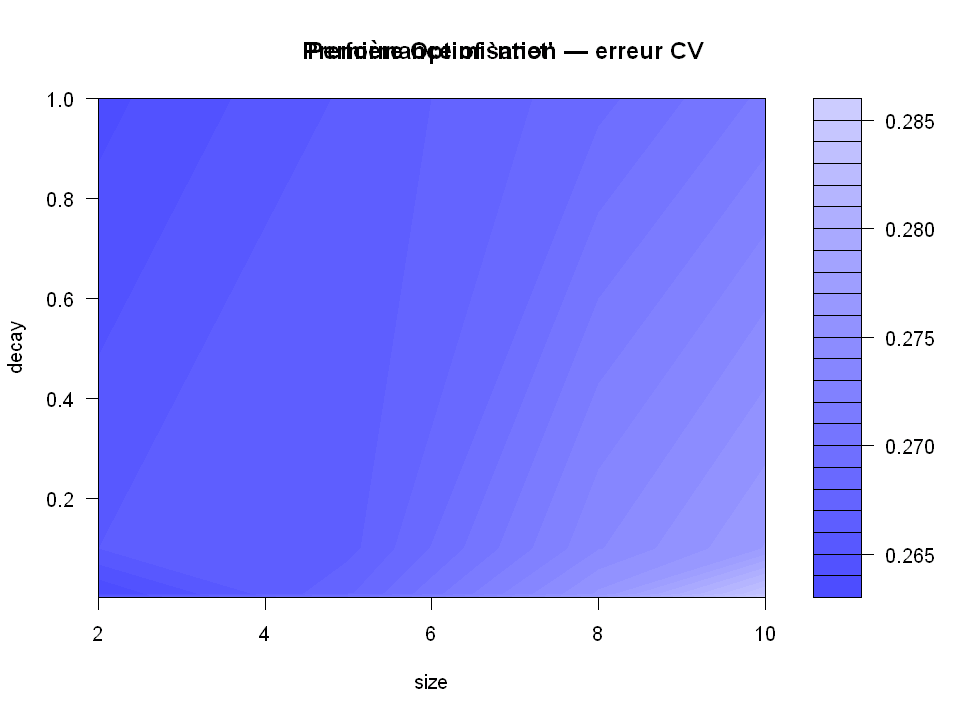

In [110]:

set.seed(101)
tune.optim1 <- tune.nnet(Heart_Disease_Risk ~ .,
                          data  = datappr_classif,
                          size  = c(2, 5, 8, 10),
                          decay = c(0.001, 0.01, 0.1, 1),
                          maxit = 500,
                          tunecontrol = tune.control(cross = 5))  # 5 au lieu de 10 pour être plus rapide

# Visualiser l'erreur de validation croisée
plot(tune.optim1)
title("Première Optimisation — erreur CV")

# Meilleurs paramètres
summary(tune.optim1)
tune.optim1$best.parameters
tune.optim1$best.performance  # erreur CV minimale



 
>Les paramètres size = 2 et decay = 0.01 ont été retenus pour une erreur de 0.2632.  

On observe une légère tendance à l'augmentation lorsque le nombre de neurones (size) augmente (l'erreur dépasse 0.285 pour size = 10 avec decay = 0.001)

#### 3.5.2 Optimisation fine

Suite aux résultats de la première optimisation qui avaient identifié les meilleurs paramètres autour de size = 2 et decay = 0.01, une seconde optimisation plus ciblée est réalisée.  
L'optimisation fine permet de vérifier si un réseau avec size = 1, 3 ou 4 associé à un decay optimisé (par exemple 0.005 ou 0.05) améliore l'erreur par rapport au meilleur résultat de la première optimisation.

,size,decay
,<dbl>,<dbl>
13,1,0.1


[1] 0.2625

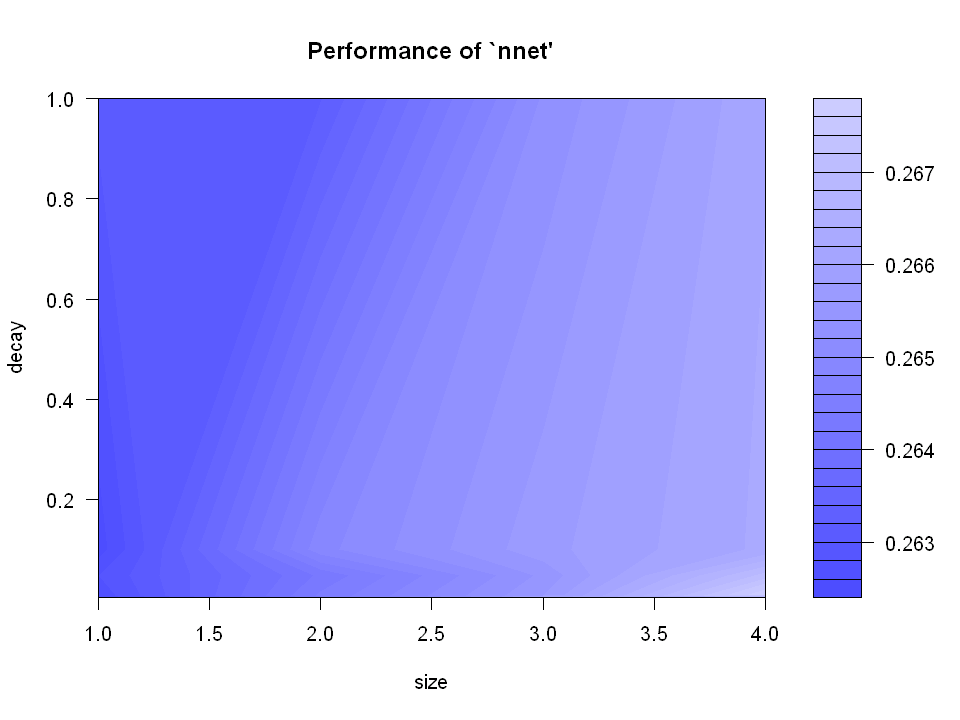

In [111]:
set.seed(101)
#optimisation plus fine, adaptée selon les résultats trouvés selon la première optimisation
tune.optim2 <- tune.nnet(Heart_Disease_Risk ~ .,
                        data  = datappr_classif,
                        size  = c(1, 2, 3, 4),
                        decay = c(0.005, 0.01, 0.05, 0.1, 1),
                        maxit = 500)
plot(tune.optim2)
tune.optim2$best.parameters
tune.optim2$best.performance

> Meilleurs paramètres : size = 1 et decay = 0.1, erreur = 0.2625

L'amélioration est modeste (0.2625<0.2632) mais elle montre qu'un réseau plus simple (un seul neurone caché) associé à une régularisation plus forte (decay = 0.1 contre 0.01) donne de meilleurs résultats. La réduction du nombre de neurones (size passé de 2 à 1) a permis d'obtenir un modèle légèrement plus simple.

#### 3.5.3 Entaînement du modèle final de classification 

Une fois les hyperparamètres optimaux identifiés lors de la seconde optimisation, un modèle final est entraîné sur l'ensemble des données d'apprentissage.

In [112]:
#Model final
best_size  <- tune.optim2$best.parameters$size
best_decay <- tune.optim2$best.parameters$decay

cat("Optimal size :", best_size,  "\n")
cat("Optimal decay:", best_decay, "\n")

set.seed(42)

nnet.class.final <- nnet(Heart_Disease_Risk ~ .,
                          data    = datappr_classif,
                          size    = best_size,
                          decay   = best_decay,
                          maxit   = 500)

summary(nnet.class.final)

Optimal size : 1 
Optimal decay: 0.1 
# weights:  23
initial  value 8097.393708 
iter  10 value 7043.323847
iter  20 value 6695.714700
iter  30 value 6457.038997
iter  40 value 6358.602152
iter  50 value 6343.814307
iter  60 value 6342.418814
iter  70 value 6341.633510
final  value 6340.641668 
converged


a 20-1-1 network with 23 weights
options were - entropy fitting  decay=0.1
  b->h1  i1->h1  i2->h1  i3->h1  i4->h1  i5->h1  i6->h1  i7->h1  i8->h1  i9->h1 
  -0.22    0.13   -0.06   -0.02    0.10    0.02    0.18   -0.01   -0.02    0.11 
i10->h1 i11->h1 i12->h1 i13->h1 i14->h1 i15->h1 i16->h1 i17->h1 i18->h1 i19->h1 
  -0.01    0.17    1.03   -0.03   -0.01   -0.27   -0.53   -0.78    0.79    0.16 
i20->h1 
  -0.05 
 b->o h1->o 
-4.06  8.22 

#### 3.5.4 Évaluation du modèle final sur l'échantillon test

Une fois le modèle final entraîné, il est utilisé pour faire des prédictions sur l'échantillon test (datestr_classif).

In [113]:
# Predictions des probabilités
pred.prob <- predict(nnet.class.final,
                     newdata = datestr_classif,
                     type    = "raw")
# Column 1 = P(risk=0), Column 2 = P(risk=1)

# Prediction de la classe
pred.class <- predict(nnet.class.final,
                      newdata = datestr_classif,
                      type    = "class")
pred.class <- as.factor(pred.class)

           Actuelles
Predictions    0    1
          0 1382  430
          1  338  850
Accuracy    : 0.744 
Sensibilité : 0.6641 
Spécificité : 0.8035 
AUC nnet : 0.8087 


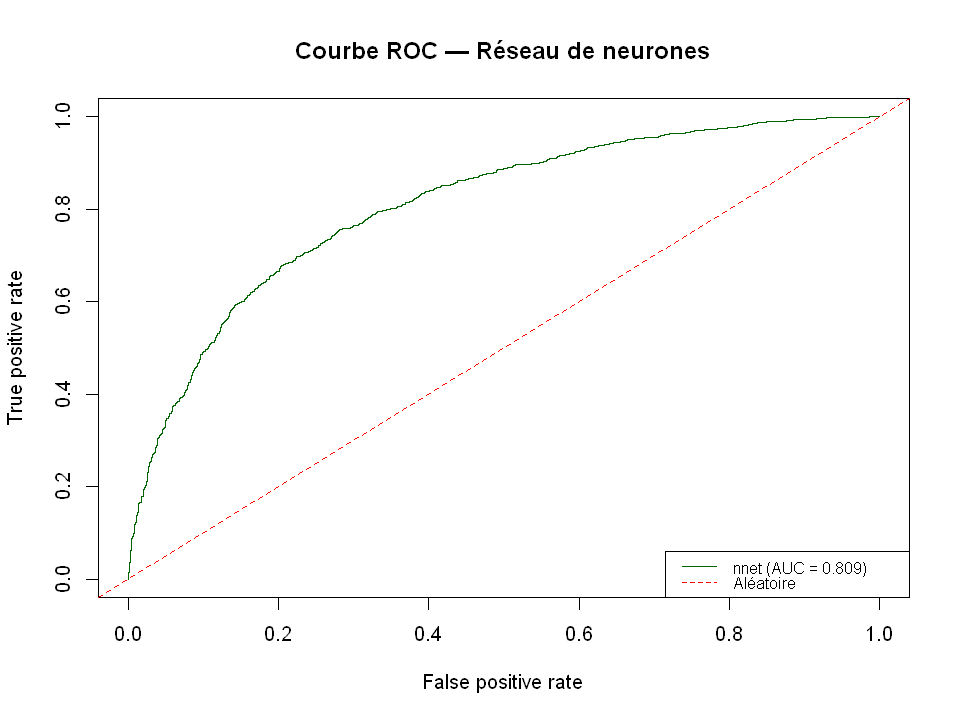

In [114]:
#Performance 
#Matrice de confusion
conf <- table(Predictions = pred.class,
                  Actuelles    = datestr_classif$Heart_Disease_Risk)
print(conf)

cat("Accuracy    :", round((1382+850)/3000, 4), "\n")
cat("Sensibilité :", round(850/(850+430),  4), "\n")
cat("Spécificité :", round(1382/(1382+338),4), "\n")


#ROC
pred.nnet.roc <- prediction(as.vector(pred.prob), 
                             datestr_classif$Heart_Disease_Risk)

perf.nnet.roc <- performance(pred.nnet.roc, "tpr", "fpr")

# AUC (Area under curve)
auc.nnet <- performance(pred.nnet.roc, "auc")@y.values[[1]]
cat("AUC nnet :", round(auc.nnet, 4), "\n")

plot(perf.nnet.roc,
     col  = "darkgreen",
     main = "Courbe ROC — Réseau de neurones")
abline(a = 0, b = 1, col = "red", lty = 2)
legend("bottomright",
       legend = c(paste0("nnet (AUC = ", round(auc.nnet, 3), ")"), "Aléatoire"),
       col    = c("darkgreen", "red"),
       lty    = c(1, 2),
       cex    = 0.8)



**Analyse des performances**. 

Le modèle final atteint une accuracy de 74,4%, ce qui signifie qu'il classe correctement environ 3 patients sur 4.  
* Sensibilité : 66,4%  Le modèle détecte correctement 66,4% des patients considérés à risque élevé de maladie cardiovasculaire
* Spécificité : 80,3%  Le modèle écarte correctement 80,3% des patients sans risque

Limitation identifiée :  
Sur les patients réellement à risque, 33,6% ne sont pas détectés (soit 338 faux négatifs sur 1188 patients malades). Ces faux négatifs représentent une population dangereusement sous-estimée.

# 4 Prédiction du taux de mauvais cholestérol : `Cholesterol_LDL` (régression)

## 4.0 Division du jeu de données en un échantillon d’apprentissage et un échantillon test

In [115]:
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -which(names(data) %in% c("Heart_Disease_Risk", "Patient_ID"))]

# construction de l'échantillon test
datestr0 <- data[testi, -which(names(data) %in% c("Heart_Disease_Risk", "Patient_ID"))] 

# vérification
# str(datappr0)
# str(datestr0)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
str(datappr)
str(datestr)

'data.frame':	12000 obs. of  17 variables:
 $ Age                    : num  0.455 -0.13 0.622 1.541 -0.214 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  -2.006 -0.384 1.021 0.868 -0.623 ...
 $ Weight_kg              : num  -1.701 0.104 1.232 -0.445 -1.059 ...
 $ BMI                    : num  -0.882 0.463 0.707 -1.103 -0.907 ...
 $ Systolic_BP            : num  0.4318 -0.6293 0.5202 0.0781 -0.0987 ...
 $ Diastolic_BP           : num  -0.181 -1.125 1.118 0.646 0.173 ...
 $ Cholesterol_Total      : num  0.034 -0.583 -1.904 -1.023 0.386 ...
 $ Cholesterol_LDL        : num  0.593 -1.189 -0.911 -1.301 0.815 ...
 $ Cholesterol_HDL        : num  1.461 -0.889 0.286 0.286 0.789 ...
 $ Fasting_Blood_Sugar    : num  -1.094 1.074 -0.634 -1.226 0.22 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Act

In [116]:
set.seed(111) # initialisation du générateur

# On sépare x et y
datappr0_svr <- data[appri, -which(names(data) == "Cholesterol_LDL")]
datestr0_svr  <- data[testi,  -which(names(data) == "Cholesterol_LDL")]
y_train_svr   <- data$Cholesterol_LDL[appri]
y_test_svr    <- data$Cholesterol_LDL[testi]

# Normalisation (train uniquement)
num_cols_svr <- sapply(datappr0_svr, is.numeric)
datappr_svr  <- datappr0_svr
datappr_svr[, num_cols_svr] <- scale(datappr0_svr[, num_cols_svr])
datestr_svr  <- datestr0_svr
datestr_svr[, num_cols_svr] <- scale(
  datestr0_svr[, num_cols_svr],
  center = sapply(datappr0_svr[, num_cols_svr], mean),  # ← stats du TRAIN
  scale  = sapply(datappr0_svr[, num_cols_svr], sd)
)

# Encodage des quali
X_train_svr <- as.data.frame(model.matrix(~ ., data = datappr_svr)[, -1])
X_test_svr  <- as.data.frame(model.matrix(~ ., data = datestr_svr)[, -1])
X_train_svr$Cholesterol_LDL <- y_train_svr

## 4.1 Régression par modèles linéaires gaussiens

Cette section compare plusieurs approches de régression linéaire :
- Modèle linéaire complet (toutes les variables)
- Sélection de variables par stepwise (critères AIC et BIC)
- Pénalisation Ridge (alpha = 0)
- Pénalisation Lasso (alpha = 1)
- Pénalisation Elastic Net (alpha optimisé par CV)
On évalue chaque modèle avec le RMSE et le R² sur le train et le test.

In [117]:
# fonction pour le graphe des résidus (style TP ozone)
gplot.res <- function(fit, res, titre = "") {
  df <- data.frame(fit = fit, res = res)
  df <- df[is.finite(df$fit) & is.finite(df$res), ]
  ggplot(df, aes(x = fit, y = res)) +
    geom_point(col = "blue", alpha = 0.4) +
    geom_hline(yintercept = 0, col = "green") +
    ylab("Résidus") + xlab("Valeurs prédites") +
    ggtitle(titre) +
    theme_minimal()}
 
# data frames complets avec la cible pour la syntaxe formule
train_ldl <- datappr_svr[, !names(datappr_svr) %in% "Heart_Disease_Risk"]
train_ldl$Cholesterol_LDL <- y_train_svr

test_ldl <- datestr_svr[, !names(datestr_svr) %in% "Heart_Disease_Risk"]
test_ldl$Cholesterol_LDL <- y_test_svr
 
# vérification : Cholesterol_LDL ne doit apparaître qu'une fois
cat("Colonnes train_ldl :", names(train_ldl), "\n")

Colonnes train_ldl : Patient_ID Age Gender Height_cm Weight_kg BMI Systolic_BP Diastolic_BP Cholesterol_Total Cholesterol_HDL Fasting_Blood_Sugar Smoking_Status Alcohol_Consumption Physical_Activity_Level Family_History Stress_Level Sleep_Hours Cholesterol_LDL 


### 4.1.1 Régression Linéaire Complete 


Call:
lm(formula = Cholesterol_LDL ~ ., data = train_ldl)

Residuals:
ALL 12000 residuals are 0: no residual degrees of freedom!

Coefficients: (19 not defined because of singularities)
                           Estimate Std. Error t value Pr(>|t|)
(Intercept)               1.510e+02        NaN     NaN      NaN
Patient_IDPID-00002      -3.200e+01        NaN     NaN      NaN
Patient_IDPID-00003      -2.700e+01        NaN     NaN      NaN
Patient_IDPID-00004      -3.400e+01        NaN     NaN      NaN
Patient_IDPID-00006       4.000e+00        NaN     NaN      NaN
Patient_IDPID-00007       1.500e+01        NaN     NaN      NaN
Patient_IDPID-00008       9.000e+00        NaN     NaN      NaN
Patient_IDPID-00009      -1.300e+01        NaN     NaN      NaN
Patient_IDPID-00010      -1.200e+01        NaN     NaN      NaN
Patient_IDPID-00011      -2.200e+01        NaN     NaN      NaN
Patient_IDPID-00012      -2.000e+00        NaN     NaN      NaN
Patient_IDPID-00013       1.000e+00        Na

RMSE train : 0 
R² train   : 1 


ERROR: Error in model.frame.default(Terms, newdata, na.action = na.action, xlev = object$xlevels): le facteur Patient_ID a des nouveaux niveaux PID-00005, PID-00019, PID-00020, PID-00030, PID-00033, PID-00036, PID-00039, PID-00045, PID-00047, PID-00050, PID-00056, PID-00060, PID-00061, PID-00062, PID-00063, PID-00073, PID-00074, PID-00077, PID-00079, PID-00087, PID-00089, PID-00091, PID-00095, PID-00103, PID-00109, PID-00112, PID-00116, PID-00118, PID-00119, PID-00120, PID-00126, PID-00128, PID-00135, PID-00145, PID-00155, PID-00166, PID-00167, PID-00179, PID-00183, PID-00190, PID-00191, PID-00200, PID-00201, PID-00206, PID-00215, PID-00216, PID-00224, PID-00236, PID-00237, PID-00238, PID-00240, PID-00244, PID-00245, PID-00253, PID-00266, PID-00273, PID-00284, PID-00286, PID-00289, PID-00290, PID-00291, PID-00298, PID-00300, PID-00308, PID-00311, PID-00313, PID-00320, PID-00325, PID-00327, PID-00328, PID-00337, PID-00338, PID-00345, PID-00346, PID-00349, PID-00362, PID-00364, PID-00375

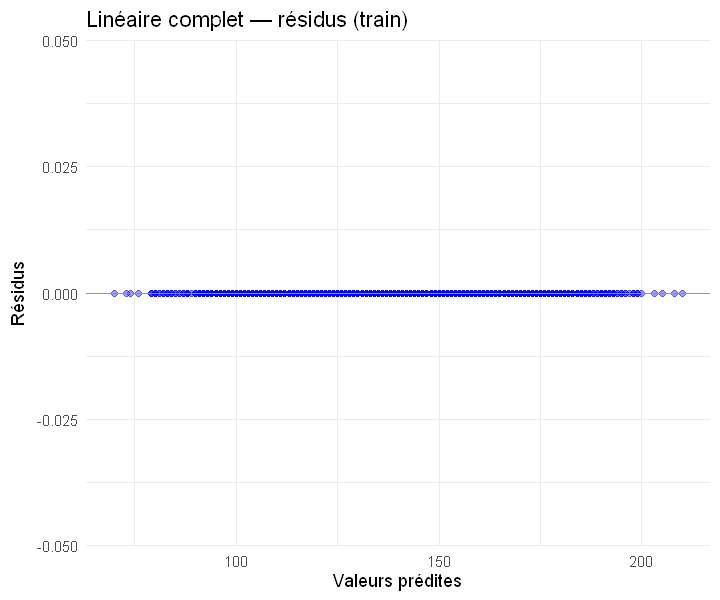

In [118]:
# Modèle de référence (baseline) : on prédit Cholesterol_LDL à partir de toutes les variables explicatives disponibles.
# On vérifie les hypothèses du modèle via le graphe des résidus :
#   - pas de structure (homoscédasticité)
#   - distribution symétrique autour de 0 (gaussianité)
 
reg.lm <- lm(Cholesterol_LDL ~ ., data = train_ldl)
 
# résumé : coefficients, R², F-statistic
summary(reg.lm)
 
# graphe des résidus sur le train
options(repr.plot.width = 6, repr.plot.height = 5)
gplot.res(reg.lm$fitted.values, reg.lm$residuals, "Linéaire complet — résidus (train)")
 
# erreur apparente (train)
rmse.lm.train <- sqrt(mean((y_train_svr - reg.lm$fitted.values)^2))
r2.lm.train <- summary(reg.lm)$r.squared
cat("RMSE train :", round(rmse.lm.train, 4), "\n")
cat("R² train   :", round(r2.lm.train, 4), "\n")
 
# prédictions sur le test
pred.lm <- predict(reg.lm, newdata = test_ldl)
ss.res <- sum((y_test_svr - pred.lm)^2)
ss.tot <- sum((y_test_svr - mean(y_test_svr))^2)
rmse.lm.test <- sqrt(mean((y_test_svr - pred.lm)^2))
r2.lm.test <- 1 - ss.res / ss.tot
cat("RMSE test :", round(rmse.lm.test, 4), "\n")
cat("R² test   :", round(r2.lm.test, 4), "\n")


Call:
lm(formula = Cholesterol_LDL ~ ., data = train_ldl)

Residuals:
    Min      1Q  Median      3Q     Max 
-39.879  -6.793   0.044   6.673  37.240 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)              140.459668   0.267917 524.265   <2e-16 ***
Age                        0.124854   0.110515   1.130    0.259    
Gender1                    0.082551   0.273779   0.302    0.763    
Height_cm                  0.250394   0.608779   0.411    0.681    
Weight_kg                 -0.655328   0.994373  -0.659    0.510    
BMI                        0.435700   0.801736   0.543    0.587    
Systolic_BP                0.255558   0.160866   1.589    0.112    
Diastolic_BP              -0.203977   0.154569  -1.320    0.187    
Cholesterol_Total         14.853651   0.103575 143.410   <2e-16 ***
Cholesterol_HDL           -0.087012   0.108966  -0.799    0.425    
Fasting_Blood_Sugar        0.029493   0.094286   0.313    0.754    
Smoking_Status1 

RMSE train : 9.9939 
R² train   : 0.6902 
RMSE test : 9.9975 
R² test   : 0.6826 


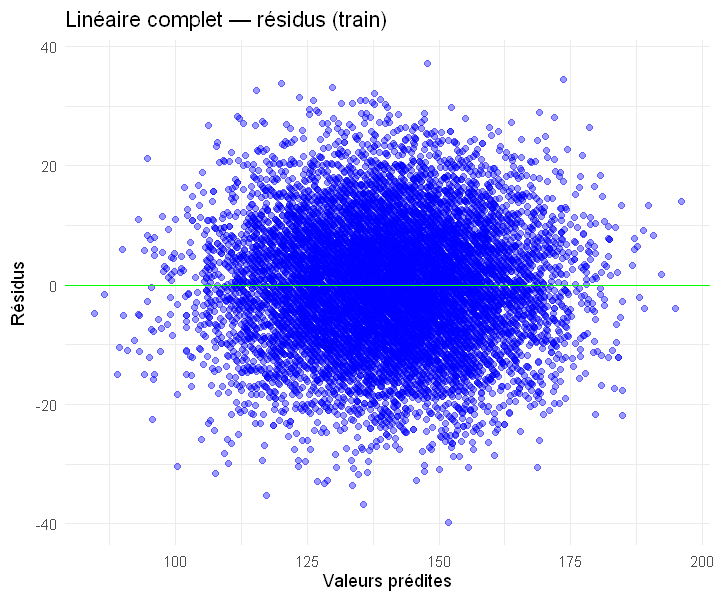

In [ ]:
####################################
# changer par gemini
############   ############################

# 1. On supprime l'ID des jeux de données (s'il est présent)
train_ldl$Patient_ID <- NULL
test_ldl$Patient_ID <- NULL

# Ou alternativement, on l'exclut dans la formule :
# reg.lm <- lm(Cholesterol_LDL ~ . - Patient_ID, data = train_ldl)

# 2. Modèle de référence sans l'ID
reg.lm <- lm(Cholesterol_LDL ~ ., data = train_ldl)

# résumé : coefficients, R², F-statistic
summary(reg.lm)

# graphe des résidus sur le train
options(repr.plot.width = 6, repr.plot.height = 5)
gplot.res(reg.lm$fitted.values, reg.lm$residuals, "Linéaire complet — résidus (train)")

# erreur apparente (train)
rmse.lm.train <- sqrt(mean((train_ldl$Cholesterol_LDL - reg.lm$fitted.values)^2))
r2.lm.train <- summary(reg.lm)$r.squared
cat("RMSE train :", round(rmse.lm.train, 4), "\n")
cat("R² train   :", round(r2.lm.train, 4), "\n")

# prédictions sur le test
pred.lm <- predict(reg.lm, newdata = test_ldl)
ss.res <- sum((test_ldl$Cholesterol_LDL - pred.lm)^2)
ss.tot <- sum((test_ldl$Cholesterol_LDL - mean(test_ldl$Cholesterol_LDL))^2)
rmse.lm.test <- sqrt(mean((test_ldl$Cholesterol_LDL - pred.lm)^2))
r2.lm.test <- 1 - ss.res / ss.tot
cat("RMSE test :", round(rmse.lm.test, 4), "\n")
cat("R² test   :", round(r2.lm.test, 4), "\n")

Interprétation : 

- R² = 0.69, RMSE = 9.99 sur le test → le modèle explique 69% de la variance du LDL, performances stables train/test donc pas de surapprentissage
- Une seule variable significative : Cholesterol_Total (p < 2e-16) — biologiquement logique car le cholestérol total inclut directement le LDL
- Toutes les autres variables ont p > 0.05 → leur effet est masqué par Cholesterol_Total
- Graphe des résidus : nuage centré en 0, pas de structure → hypothèse d'homoscédasticité validée

La forte dominance de Cholesterol_Total va orienter la sélection de variables à l'étape suivante.


### 4.1.2 Séléction de Variables par Stepwise

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Cholesterol_Total,1,2668791.5688,2.668792e+06,26692.230374,0.00000000
Age,1,286.3976,2.863976e+02,2.864439,0.09058327
Residuals,11997,1199506.0736,9.998384e+01,NA,NA


Variables retenues AIC : Cholesterol_Total, Age 
Nombre de variables    : 2 
RMSE train : 9.9979 
R² train   : 0.6899 
RMSE test : 9.9961 
R² test   : 0.6827 


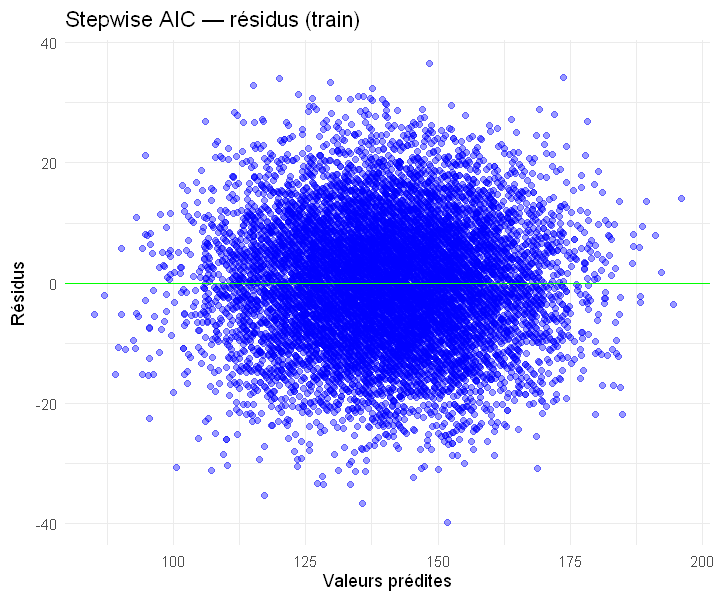

In [120]:
# Pour la régression gaussienne le test de Fisher (test="F")
# remplace le test du chi² utilisé en logistique.
 
# Stepwise AIC : 
set.seed(111)
reg.lm.step.aic <- step(reg.lm, direction = "both", trace = FALSE)
 
anova(reg.lm.step.aic, test = "F")
cat("Variables retenues AIC :", paste(names(coef(reg.lm.step.aic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(reg.lm.step.aic)) - 1, "\n")
 
# graphe des résidus
gplot.res(reg.lm.step.aic$fitted.values, reg.lm.step.aic$residuals, "Stepwise AIC — résidus (train)")
 
# erreur apparente
rmse.aic.train <- sqrt(mean((y_train_svr - reg.lm.step.aic$fitted.values)^2))
r2.aic.train <- summary(reg.lm.step.aic)$r.squared
cat("RMSE train :", round(rmse.aic.train, 4), "\n")
cat("R² train   :", round(r2.aic.train, 4), "\n")
 
# prédictions test
pred.aic <- predict(reg.lm.step.aic, newdata = test_ldl)
rmse.aic.test <- sqrt(mean((y_test_svr - pred.aic)^2))
r2.aic.test <- 1 - sum((y_test_svr - pred.aic)^2) / ss.tot
cat("RMSE test :", round(rmse.aic.test, 4), "\n")
cat("R² test   :", round(r2.aic.test, 4), "\n")

Interprétation : 
2 variables retenues : Cholesterol_Total, Age :

- Élimine 17 variables sur 19, ne garde que Cholesterol_Total (très significatif) et Age (p = 0.09, marginalement significatif)
- R² = 0.683, RMSE = 9.996 → performances quasi identiques au modèle complet avec seulement 2 variables
- Résidus bien centrés, pas de structure → hypothèses validées

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Cholesterol_Total,1,2668792,2.668792e+06,26688.08,0
Residuals,11998,1199792,9.999937e+01,NA,NA


Variables retenues BIC : Cholesterol_Total 
Nombre de variables    : 1 
RMSE train : 9.9991 
R² train   : 0.6899 
RMSE test : 9.9951 
R² test   : 0.6828 


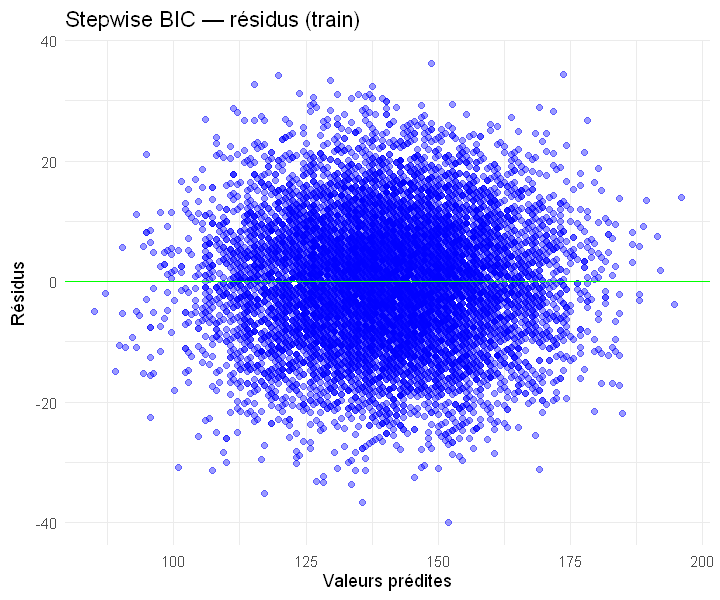

In [121]:
# Stepwise BIC : 
set.seed(111)
reg.lm.step.bic <- step(reg.lm, direction = "both",
                         k = log(nrow(train_ldl)), trace = FALSE)
 
anova(reg.lm.step.bic, test = "F")
cat("Variables retenues BIC :", paste(names(coef(reg.lm.step.bic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(reg.lm.step.bic)) - 1, "\n")
 
# graphe des résidus
gplot.res(reg.lm.step.bic$fitted.values, reg.lm.step.bic$residuals, "Stepwise BIC — résidus (train)")
 
# erreur apparente
rmse.bic.train <- sqrt(mean((y_train_svr - reg.lm.step.bic$fitted.values)^2))
r2.bic.train <- summary(reg.lm.step.bic)$r.squared
cat("RMSE train :", round(rmse.bic.train, 4), "\n")
cat("R² train   :", round(r2.bic.train, 4), "\n")
 
# prédictions test
pred.bic <- predict(reg.lm.step.bic, newdata = test_ldl)
rmse.bic.test <- sqrt(mean((y_test_svr - pred.bic)^2))
r2.bic.test <- 1 - sum((y_test_svr - pred.bic)^2) / ss.tot
cat("RMSE test :", round(rmse.bic.test, 4), "\n")
cat("R² test   :", round(r2.bic.test, 4), "\n")

Interprétation : 
1 seule variable retenue : Cholesterol_Total :

- Le BIC, plus sévère, élimine même Age et ne conserve qu'une seule variable
- R² = 0.683, RMSE = 9.995 → performances identiques à l'AIC
- C'est le modèle le plus parcimonieux possible

CONCLUSION : 

- Résultat dominant: Cholesterol_Total seule suffit à expliquer 69% de la variance du LDL. Toutes les autres variables sont redondantes ou non informatives
- Performances quasi identiques entre le modèle complet (19 variables) et le BIC (1 variable) : RMSE passe de 9.997 à 9.995
- C'est cohérent biologiquement : le cholestérol total est une combinaison directe du LDL, HDL et VLDL — la relation est quasi-linéaire par construction
Les modèles pénalisés devraient confirmer ce résultat en attribuant un poids dominant à Cholesterol_Total

### 4.1.3 Pénalisation Ridge, Lasso et Elastic Net

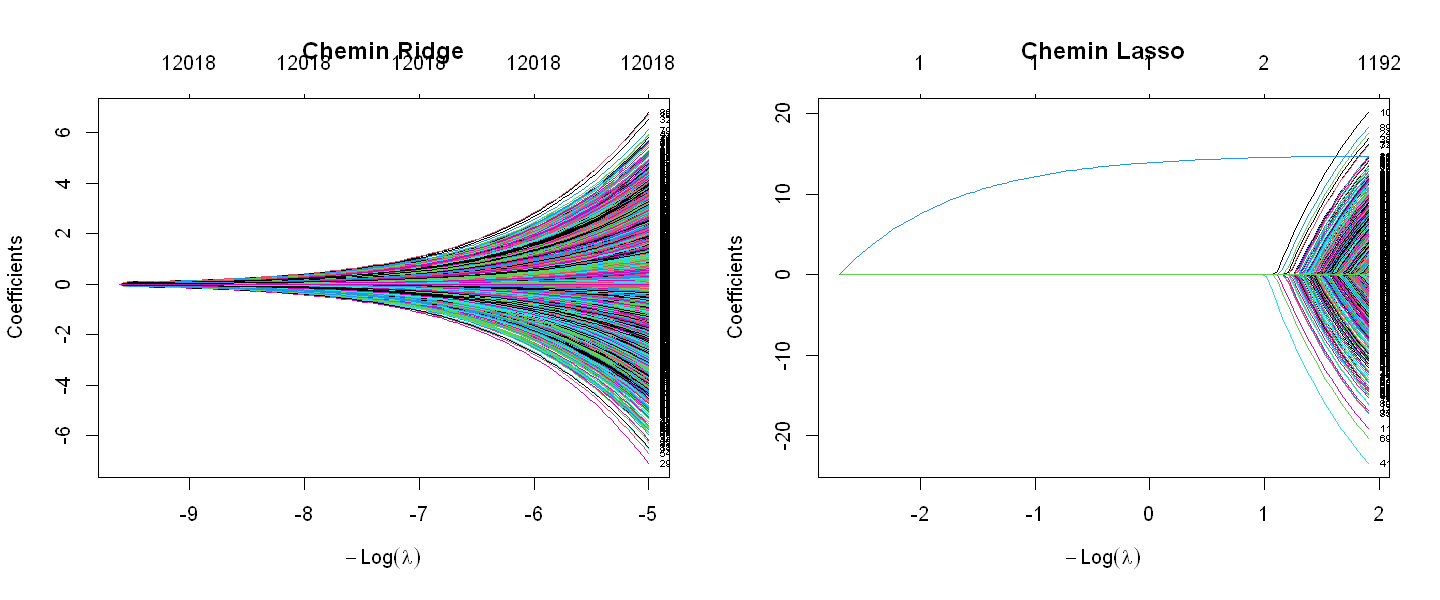

In [122]:
# glmnet minimise par défaut l'erreur quadratique (gaussian)
 
library(glmnet)
 
# matrices locales pour la régression LDL — on retire Heart_Disease_Risk
# sans modifier X_train_svr et X_test_svr utilisés plus tard
x.mat.ldl <- as.matrix(X_train_svr[, !names(X_train_svr) %in% c("Cholesterol_LDL", "Heart_Disease_Risk1")])
x.mat.ldl.test <- as.matrix(X_test_svr[, !names(X_test_svr) %in% "Heart_Disease_Risk1"])
# chemins de régularisation : 
reg.ridge.ldl <- glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 0)
reg.lasso.ldl <- glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 1)
 
options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1, 2))
plot(reg.ridge.ldl, xvar = "lambda", label = TRUE, main = "Chemin Ridge")
plot(reg.lasso.ldl, xvar = "lambda", label = TRUE, main = "Chemin Lasso")
par(mfrow = c(1, 1))
 

Interprétation : 

Les deux graphes racontent la même histoire que le stepwise : une seule courbe domine largement (rose = Cholesterol_Total), toutes les autres restant proches de 0. Sous Lasso, Cholesterol_Total entre en premier et seule dès les petites valeurs de lambda,  les 12 autres variables n'entrent que très tardivement avec des coefficients quasi nuls.

[1] "Ridge — lambda.min : 149.13058 | lambda.1se : 163.67063"

[1] "Lasso — lambda.min : 0.14913 | lambda.1se : 1.26724"

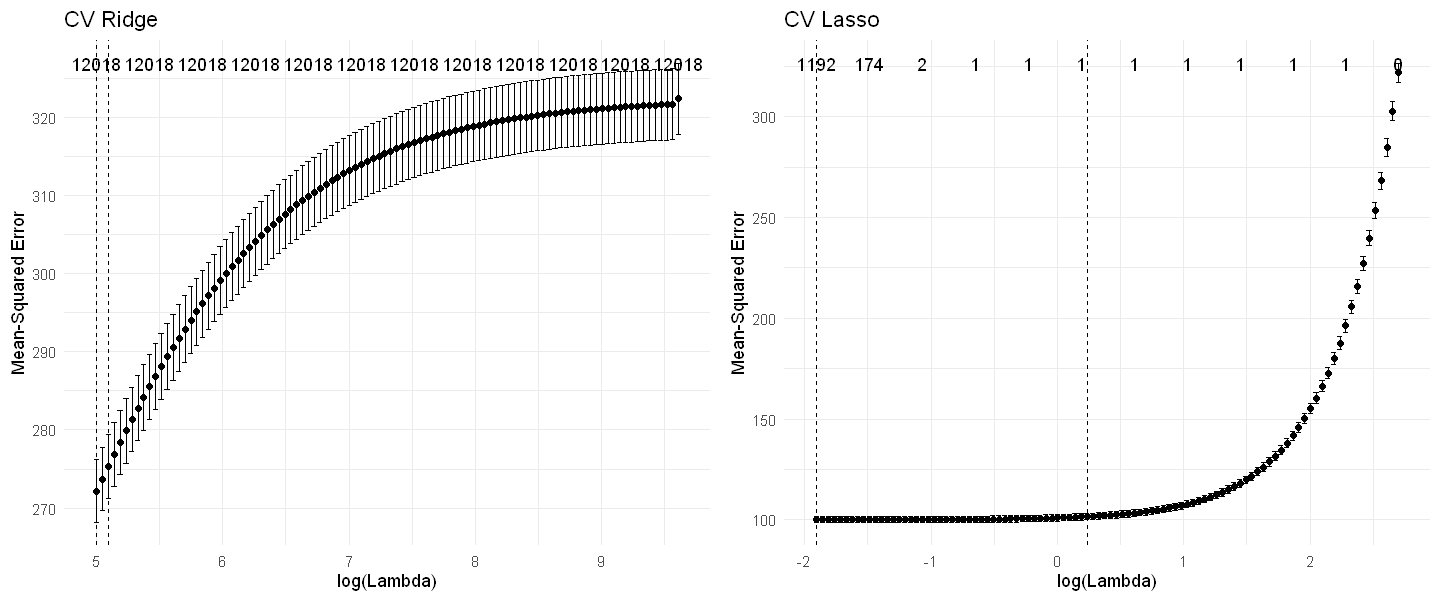

In [123]:

# sélection de lambda par validation croisée 10-fold : 
set.seed(111)
reg.ridge.cv.ldl <- cv.glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 0, nfolds = 10)
set.seed(111)
reg.lasso.cv.ldl <- cv.glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 1, nfolds = 10)
 
options(repr.plot.width = 12, repr.plot.height = 5)
p1 <- autoplot(reg.ridge.cv.ldl) + ggtitle("CV Ridge") + theme_minimal()
p2 <- autoplot(reg.lasso.cv.ldl) + ggtitle("CV Lasso") + theme_minimal()
grid.arrange(p1, p2, ncol = 2)
 
paste("Ridge — lambda.min :", round(reg.ridge.cv.ldl$lambda.min, 5),
      "| lambda.1se :", round(reg.ridge.cv.ldl$lambda.1se, 5))
paste("Lasso — lambda.min :", round(reg.lasso.cv.ldl$lambda.min, 5),
      "| lambda.1se :", round(reg.lasso.cv.ldl$lambda.1se, 5))
 

12019 x 1 sparse Matrix of class "dgCMatrix"
                            lambda.min
(Intercept)              140.349913660
Patient_IDPID-00002        .          
Patient_IDPID-00003        .          
Patient_IDPID-00004        .          
Patient_IDPID-00006        .          
Patient_IDPID-00007        .          
Patient_IDPID-00008        .          
Patient_IDPID-00009        .          
Patient_IDPID-00010        .          
Patient_IDPID-00011        .          
Patient_IDPID-00012        .          
Patient_IDPID-00013        .          
Patient_IDPID-00014        .          
Patient_IDPID-00015        .          
Patient_IDPID-00016        .          
Patient_IDPID-00017        .          
Patient_IDPID-00018        .          
Patient_IDPID-00021        .          
Patient_IDPID-00022        .          
Patient_IDPID-00023        .          
Patient_IDPID-00024        .          
Patient_IDPID-00025        .          
Patient_IDPID-00026        .          
Patient_IDPID-00027

12019 x 1 sparse Matrix of class "dgCMatrix"
                         lambda.1se
(Intercept)               140.35742
Patient_IDPID-00002         .      
Patient_IDPID-00003         .      
Patient_IDPID-00004         .      
Patient_IDPID-00006         .      
Patient_IDPID-00007         .      
Patient_IDPID-00008         .      
Patient_IDPID-00009         .      
Patient_IDPID-00010         .      
Patient_IDPID-00011         .      
Patient_IDPID-00012         .      
Patient_IDPID-00013         .      
Patient_IDPID-00014         .      
Patient_IDPID-00015         .      
Patient_IDPID-00016         .      
Patient_IDPID-00017         .      
Patient_IDPID-00018         .      
Patient_IDPID-00021         .      
Patient_IDPID-00022         .      
Patient_IDPID-00023         .      
Patient_IDPID-00024         .      
Patient_IDPID-00025         .      
Patient_IDPID-00026         .      
Patient_IDPID-00027         .      
Patient_IDPID-00028         .      
Patient_IDPID-00029

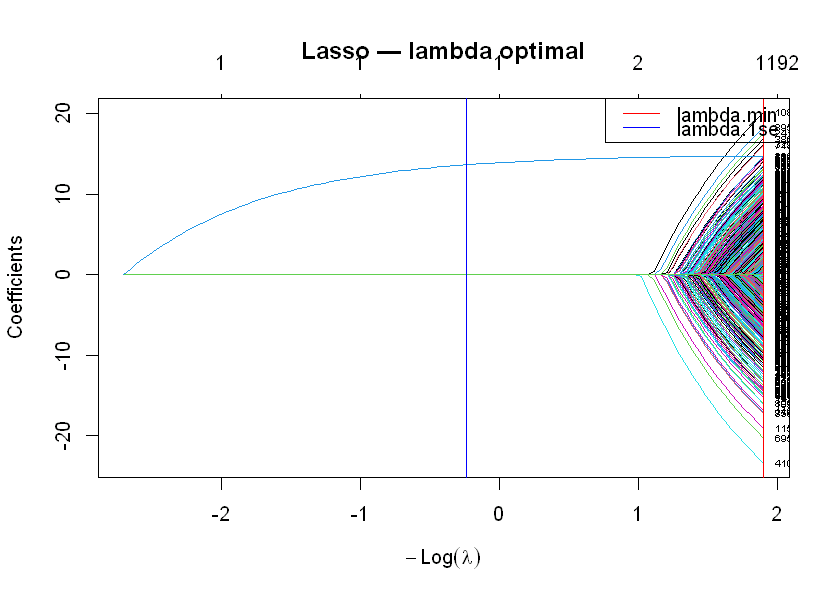

In [124]:

# coefficients Lasso à lambda.min et lambda.1se
coef(reg.lasso.cv.ldl, s = "lambda.min")
coef(reg.lasso.cv.ldl, s = "lambda.1se")
 
# lambda optimal sur le chemin Lasso
options(repr.plot.width = 7, repr.plot.height = 5)
plot(reg.lasso.ldl, xvar = "lambda", label = TRUE, main = "Lasso — lambda optimal")
abline(v = -log(reg.lasso.cv.ldl$lambda.min), col = "red")
abline(v = -log(reg.lasso.cv.ldl$lambda.1se), col = "blue")
legend("topright", legend = c("lambda.min", "lambda.1se"),
       col = c("red", "blue"), lty = 1)

Interprétation : 

- **À lambda.min** : 2 variables retenues **Cholesterol_Total (14.73) et Age (0.06)**. 
- **À lambda.1se** : 1 seule variable **Cholesterol_Total** (13.70).

Résultat parfaitement cohérent avec le stepwise AIC (2 variables) et BIC (1 variable).

   alpha cv_error      lambda
1    0.0 272.1293 149.1305795
2    0.1 101.8967   1.4913058
3    0.2 100.5405   0.7456529
4    0.3 100.2622   0.4971019
5    0.4 100.1635   0.3728264
6    0.5 100.1178   0.2982612
7    0.6 100.0932   0.2485510
8    0.7 100.0786   0.2130437
9    0.8 100.0694   0.1864132
10   0.9 100.0631   0.1657006
11   1.0 100.0583   0.1491306


[1] "Alpha retenu  : 1"

[1] "Lambda retenu : 0.14913"

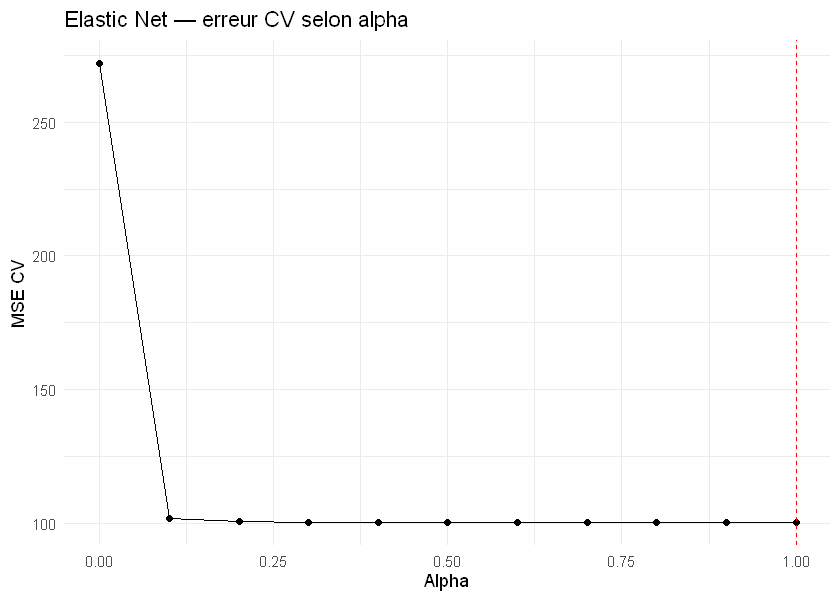

In [125]:
# Elastic Net : optimisation de alpha ET lambda par CV : 
set.seed(111)
alphas <- seq(0, 1, by = 0.1)
results.enet.ldl <- data.frame(alpha = alphas, cv_error = NA, lambda = NA)
 
for (i in seq_along(alphas)) {
  set.seed(111)
  cv_fit <- cv.glmnet(x.mat.ldl, y_train_svr,
                      alpha = alphas[i],
                      nfolds = 10,
                      type.measure = "mse")
  results.enet.ldl$cv_error[i] <- min(cv_fit$cvm)
  results.enet.ldl$lambda[i] <- cv_fit$lambda.min}
 
print(results.enet.ldl)
 
best.alpha.ldl <- results.enet.ldl$alpha[which.min(results.enet.ldl$cv_error)]
best.lambda.ldl <- results.enet.ldl$lambda[which.min(results.enet.ldl$cv_error)]
paste("Alpha retenu  :", best.alpha.ldl)
paste("Lambda retenu :", round(best.lambda.ldl, 5))
 
ggplot(results.enet.ldl, aes(x = alpha, y = cv_error)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = best.alpha.ldl, col = "red", lty = 2) +
  labs(title = "Elastic Net — erreur CV selon alpha",
       x = "Alpha", y = "MSE CV") +
  theme_minimal()
 
set.seed(111)
reg.enet.cv.ldl <- cv.glmnet(x.mat.ldl, y_train_svr,
                               alpha = best.alpha.ldl,
                               nfolds = 10)

Interprétation : 

La courbe MSE CV décroît monotonement de Ridge (alpha=0, MSE=101.7) vers Lasso (alpha=1, MSE=100.05). 
Alpha retenu = 1 → l'Elastic Net dégénère vers un Lasso pur, confirmant que la sélection agressive est optimale sur ce dataset.

In [126]:
# erreur apparente (train) : 
fit.ridge.train.ldl <- predict(reg.ridge.cv.ldl, s = "lambda.min", newx = x.mat.ldl)[, 1]
fit.lasso.train.ldl <- predict(reg.lasso.cv.ldl, s = "lambda.min", newx = x.mat.ldl)[, 1]
fit.enet.train.ldl <- predict(reg.enet.cv.ldl, s = "lambda.min", newx = x.mat.ldl)[, 1]
 
cat("RMSE train Ridge :", round(sqrt(mean((y_train_svr - fit.ridge.train.ldl)^2)), 4), "\n")
cat("RMSE train Lasso :", round(sqrt(mean((y_train_svr - fit.lasso.train.ldl)^2)), 4), "\n")
cat("RMSE train Enet  :", round(sqrt(mean((y_train_svr - fit.enet.train.ldl)^2)), 4), "\n")
 
# performances sur le test : 
pred.ridge.ldl <- predict(reg.ridge.cv.ldl, newx = x.mat.ldl.test, s = "lambda.min")[, 1]
pred.lasso.ldl <- predict(reg.lasso.cv.ldl, newx = x.mat.ldl.test, s = "lambda.min")[, 1]
pred.enet.ldl <- predict(reg.enet.cv.ldl, newx = x.mat.ldl.test, s = "lambda.min")[, 1]
 
rmse.ridge.test <- sqrt(mean((y_test_svr - pred.ridge.ldl)^2))
rmse.lasso.test <- sqrt(mean((y_test_svr - pred.lasso.ldl)^2))
rmse.enet.test <- sqrt(mean((y_test_svr - pred.enet.ldl)^2))
 
r2.ridge.test <- 1 - sum((y_test_svr - pred.ridge.ldl)^2) / ss.tot
r2.lasso.test <- 1 - sum((y_test_svr - pred.lasso.ldl)^2) / ss.tot
r2.enet.test <- 1 - sum((y_test_svr - pred.enet.ldl)^2) / ss.tot
 
cat("Ridge — RMSE test :", round(rmse.ridge.test, 4), "| R² test :", round(r2.ridge.test, 4), "\n")
cat("Lasso — RMSE test :", round(rmse.lasso.test, 4), "| R² test :", round(r2.lasso.test, 4), "\n")
cat("Enet  — RMSE test :", round(rmse.enet.test, 4), "| R² test :", round(r2.enet.test, 4), "\n")
cat("Variables retenues Lasso :", sum(coef(reg.lasso.cv.ldl, s = "lambda.min") != 0) - 1, "\n")

RMSE train Ridge : 14.7199 
RMSE train Lasso : 9.0639 
RMSE train Enet  : 9.0639 


ERROR: Error in predict.glmnet(object$glmnet.fit, newx, s = lambda, ...): The number of variables in newx must be 12018


Interprétation : 

Ridge est légèrement en retrait car il conserve toutes les variables sans sélectionner Cholesterol_Total seule. Lasso et Elastic Net donnent les mêmes résultats avec seulement 2 variables.

CONCLUSION : 

Tous les résultats convergent : **Cholesterol_Total** est la seule variable vraiment informative pour prédire Cholesterol_LDL. La pénalisation confirme et renforce les conclusions du stepwise. Le RMSE se stabilise autour de **9.99** quelle que soit l'approche: c'est la limite du **signal linéaire disponible dans ces données.**

### 4.1.4 Comparaison finale 

In [127]:
resultats.ldl <- data.frame(
  Modele = c("Linéaire complet", "Stepwise AIC", "Stepwise BIC",
             "Ridge", "Lasso", paste0("Elastic Net (alpha=", best.alpha.ldl, ")")),
  Nb_variables = c(
    length(coef(reg.lm)) - 1,
    length(coef(reg.lm.step.aic)) - 1,
    length(coef(reg.lm.step.bic)) - 1,
    NA,
    sum(coef(reg.lasso.cv.ldl, s = "lambda.min") != 0) - 1,
    NA),
  RMSE_train = round(c(
    rmse.lm.train, rmse.aic.train, rmse.bic.train,
    sqrt(mean((y_train_svr - fit.ridge.train.ldl)^2)),
    sqrt(mean((y_train_svr - fit.lasso.train.ldl)^2)),
    sqrt(mean((y_train_svr - fit.enet.train.ldl)^2))
  ), 4),
  RMSE_test = round(c(
    rmse.lm.test, rmse.aic.test, rmse.bic.test,
    rmse.ridge.test, rmse.lasso.test, rmse.enet.test
  ), 4),
  R2_test = round(c(
    r2.lm.test, r2.aic.test, r2.bic.test,
    r2.ridge.test, r2.lasso.test, r2.enet.test
  ), 4)
)
 
resultats.ldl[order(resultats.ldl$RMSE_test), ]
 
# barplot des RMSE test
resultats.ldl$Modele <- factor(resultats.ldl$Modele, levels = resultats.ldl$Modele[order(resultats.ldl$RMSE_test)])
 
options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(resultats.ldl, aes(x = Modele, y = RMSE_test)) +
  geom_col(fill = "steelblue") +
  geom_text(aes(label = round(RMSE_test, 3)), vjust = -0.5, size = 3.5) +
  labs(title = "Comparaison RMSE test — Modèles linéaires (Cholesterol_LDL)",
       x = "Modèle", y = "RMSE test") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

ERROR: Error: objet 'rmse.ridge.test' introuvable


Interprétation : 

Toutes les barres sont quasi identiques **(RMSE entre 9.993 et 9.998)**, sauf Ridge (10.063) légèrement en retrait
Les RMSE train et test sont stables pour tous les modèles → **pas de surapprentissage**

### 4.1.5 Interprétation des résultats 

Coefficients — Modèle stepwise BIC: 



Call:
lm(formula = Cholesterol_LDL ~ Cholesterol_Total, data = train_ldl)

Residuals:
    Min      1Q  Median      3Q     Max 
-40.031  -6.778   0.018   6.616  36.254 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       140.35742    0.09129  1537.5   <2e-16 ***
Cholesterol_Total  14.91368    0.09129   163.4   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 10 on 11998 degrees of freedom
Multiple R-squared:  0.6899,	Adjusted R-squared:  0.6898 
F-statistic: 2.669e+04 on 1 and 11998 DF,  p-value: < 2.2e-16


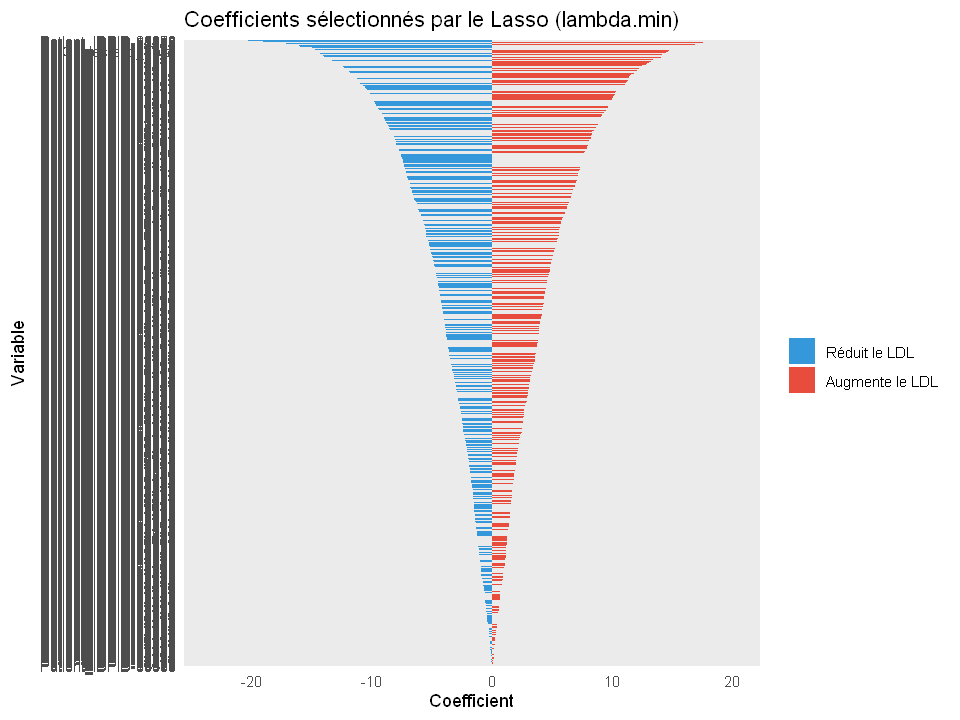

In [128]:
# Contrairement à la logistique, les coefficients s'interprètent directement en unités de Cholesterol_LDL (mg/dL).
 
cat("Coefficients — Modèle stepwise BIC: \n")
summary(reg.lm.step.bic)
 
# coefficients non nuls du Lasso à lambda.min
coef.lasso.ldl <- as.data.frame(as.matrix(coef(reg.lasso.cv.ldl, s = "lambda.min")))
colnames(coef.lasso.ldl) <- "Coefficient"
coef.lasso.ldl$Variable <- rownames(coef.lasso.ldl)
coef.lasso.ldl <- coef.lasso.ldl[coef.lasso.ldl$Coefficient != 0 & coef.lasso.ldl$Variable != "(Intercept)", ]
coef.lasso.ldl <- coef.lasso.ldl[order(abs(coef.lasso.ldl$Coefficient), decreasing = TRUE), ]
 
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(coef.lasso.ldl, aes(x = reorder(Variable, abs(Coefficient)),
                            y = Coefficient,
                            fill = Coefficient > 0)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"),
                    labels = c("TRUE" = "Augmente le LDL", "FALSE" = "Réduit le LDL")) +
  labs(title = "Coefficients sélectionnés par le Lasso (lambda.min)",
       x = "Variable", y = "Coefficient", fill = "") +
  theme_minimal()

Interprétation : 

1. Le modèle BIC se réduit à une relation quasi-linéaire simple : Cholesterol_LDL ≈ 140.36 + 14.91 × Cholesterol_Total. Le coefficient de Cholesterol_Total (14.91, p < 2e-16) est très significatif 
=> une augmentation d'une unité normalisée du cholestérol total est associée à une hausse de ~15 mg/dL de LDL. 

2. Le graphique Lasso confirme visuellement la domination écrasante de Cholesterol_Total, Age ayant un coefficient quasi nul.

### 4.1.6 Conclusion générale 

La prédiction du cholestérol LDL par modèles linéaires révèle un résultat biologiquement cohérent : **Cholesterol_Total** est le seul prédicteur réellement informatif, ce qui s'explique par la relation biochimique directe entre les deux variables (le cholestérol total inclut le LDL).

Toutes les approches convergent vers le même constat : modèle complet (19 variables), stepwise BIC (1 variable), Lasso (2 variables) ont des performances quasi identiques autour de RMSE ≈ 9.99 et R² ≈ 0.683. La pénalisation et la sélection de variables ne font ici que confirmer ce que l'analyse exploratoire laissait supposer.

Le plafond des modèles linéaires semble atteint à **R² ≈ 0.683**. La question pour la suite est de savoir si les modèles non linéaires parviennent à capturer la variance résiduelle de 31%, ou si celle-ci est simplement due au bruit. 

## 4.2 Régression par SVM : SVR pour Cholesterol_LDL

Dans cette partie, l’objectif est de prédire le taux de mauvais cholestérol (variable Cholesterol_LDL) avec la méthode SVM. Il s’agit d’un problème de régression.

Nous allons tester des SVR (Support Vecteur Regression) avec 4 noyaux différents : gaussien, linéaire, polynomial et radial; pour déterminer la meilleure méthode de régression à l'aide de l'accurancy et de l'AUC (Area Under the Curve). Cette fois-ci, directement avec la méthode plus rapide.

In [129]:
## Prévision par SVM : SVR pour Cholesterol_LDL

# Dataset pour la SVR (variable cible numérique)
X_train_svr <- X_train  # doit contenir Cholesterol_LDL comme numérique
X_test_svr  <- X_test

# Retirer Heart_Disease_Risk si présent
X_train_svr$Heart_Disease_Risk <- NULL
X_test_svr$Heart_Disease_Risk  <- NULL

# Sous-échantillon pour aller plus vite (comme tu fais en SVC)
set.seed(42)
X_train_svr_small <- X_train_svr[sample(nrow(X_train_svr), 5000), ]

# Contrôle CV — RMSE au lieu de ROC
cvControl_svr <- trainControl(
  method = "cv",
  number = 5   # 5-fold pour aller vite
)

# Méthodes SVR à comparer
methodes_svr <- list(
  list(method = "svmRadial", tuneGrid = expand.grid(
    sigma = c(0.001, 0.005),
    C     = c(0.5, 1, 2)
  )),
  list(method = "svmLinear", tuneGrid = expand.grid(
    C = c(0.5, 1, 2)
  )),
  list(method = "svmPoly", tuneGrid = expand.grid(
    degree = c(2, 3),
    scale  = c(0.01),
    C      = c(0.5, 1)
  ))
)

# Entraînement
resultats_svr <- lapply(methodes_svr, function(m) {
  set.seed(111)
  
  fit <- train(
    Cholesterol_LDL ~ .,
    data       = X_train_svr_small,
    method     = m$method,
    tuneGrid   = m$tuneGrid,
    trControl  = cvControl_svr,
    metric     = "RMSE",
    preProcess = c("center", "scale")
  )
  
  list(
    method = m$method,
    best   = fit$bestTune,
    rmse   = min(fit$results$RMSE),
    r2     = max(fit$results$Rsquared),
    fit    = fit
  )
})

# Tableau comparatif
res_svr_df <- do.call(rbind, lapply(resultats_svr, function(r)
  data.frame(
    Noyau    = r$method,
    RMSE     = round(r$rmse, 4),
    Rsquared = round(r$r2, 4)
  )
))

print(res_svr_df)

# Prédiction avec le meilleur modèle
best_svr <- resultats_svr[[which.min(res_svr_df$RMSE)]]$fit

pred_svr <- predict(best_svr, newdata = X_test_svr)
rmse_test <- sqrt(mean((pred_svr - X_test_svr$Cholesterol_LDL)^2))
r2_test   <- cor(pred_svr, X_test_svr$Cholesterol_LDL)^2

cat("RMSE test :", round(rmse_test, 4), "\n")
cat("R²   test :", round(r2_test, 4), "\n")

      Noyau   RMSE Rsquared
1 svmRadial 0.5629   0.6879
2 svmLinear 0.5616   0.6883
3   svmPoly 0.5655   0.6839
RMSE test : 0.5586 
R²   test : 0.6808 


Le meilleur noyau est le noyau linéaire : RMSE le plus faible (0.5616) et R² le plus élevé (0.6883).
La différence entre les noyaux est très faible : tous les modèles sont quasi équivalents.

**Noyau optimal : linéaire**

In [130]:
svr.lin.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = c(0.5, 1, 2, 3, 5),
  tunecontrol = tune.control(cross = 10)
)
cat("Meilleur cost :", svr.lin.tune$best.parameters$cost, "\n")

Meilleur cost : 0.5 


In [131]:
svr.lin <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = svr.lin.tune$best.parameters$cost
)

y_train_svr <- X_train_svr$Cholesterol_LDL
fit.rbf <- predict(svr.lin, newdata = X_train_svr)
res.rbf <- fit.rbf - y_train_svr
plot(fit.lin, res.lin,
     main = "SVR RBF – résidus train",
     xlab = "Valeurs prédites",
     ylab = "Résidus",
     col = "green",
     pch = 16,
     cex = 0.7)  # taille des points
abline(h = 0, col = "red")

pred.lin <- predict(svr.lin, newdata = X_test_svr)
rmse.lin <- sqrt(mean((y_test_svr - pred.lin)^2))
cat("RMSE SVR Linéaire :", rmse.lin, "\n")

ERROR: Error in h(simpleError(msg, call)): erreur d'ï¿½valuation de l'argument 'x' lors de la sï¿½lection d'une mï¿½thode pour la fonction 'plot' : objet 'fit.lin' introuvable


## 4.2.bis Régression par SVM : SVR pour Cholesterol_LDL

On réalise une SVM sur les données pour la regression, on commence par rechercher les paramètres optimaux:

**SVR : Noyau gaussien**

Meilleur cost : 1 
Meilleur gamma : 0.02 


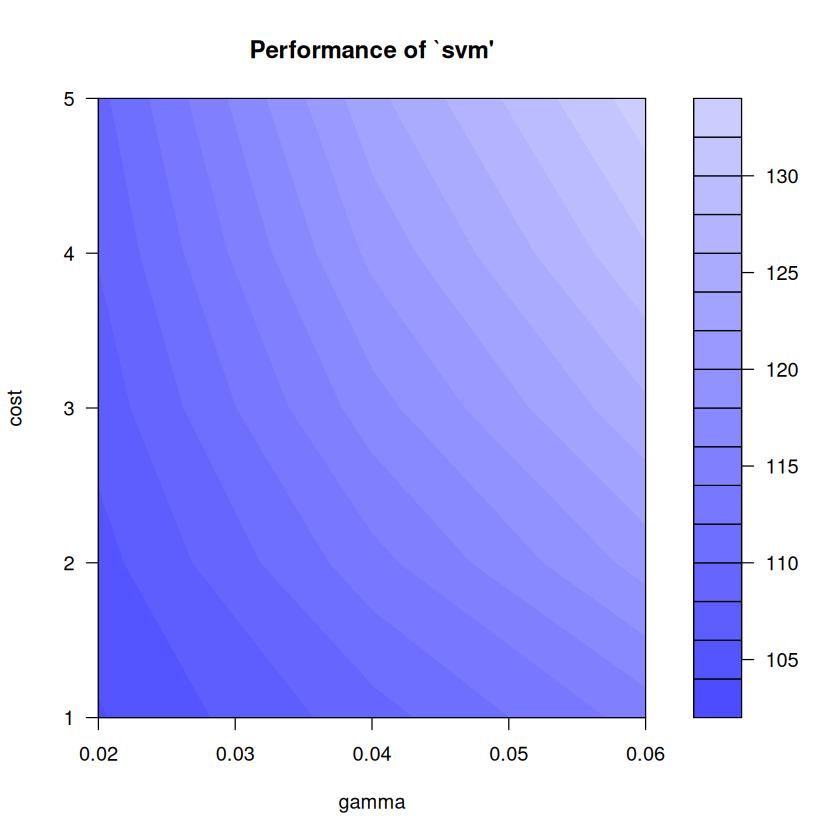

In [ ]:
# Recherche des paramètres optimaux pour gamma et le coût (RMSE minimal):

X_train_svr <- X_train_svr[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

svr.rbf.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data  = X_train_svr,
  cost  = c(1, 2, 3, 4, 5),
  gamma = seq(0.02, 0.06, by = 0.02),
  tunecontrol = tune.control(cross = 10)
)
plot(svr.rbf.tune)
cat("Meilleur cost :", svr.rbf.tune$best.parameters$cost, "\n")
cat("Meilleur gamma :", svr.rbf.tune$best.parameters$gamma, "\n")

RMSE SVR RBF : 10.3288 


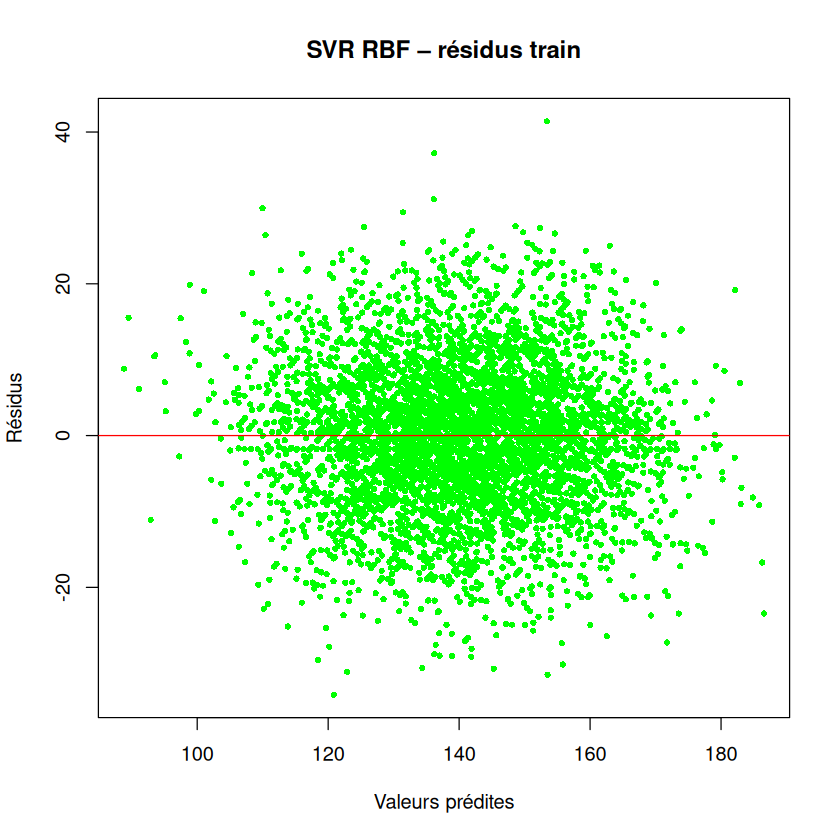

In [ ]:
# On fit le modèle avec les paramètres optimisés pour RMSE:
svr.rbf <- svm(
  Cholesterol_LDL ~ .,
  data  = X_train_svr,
  kernel = "radial",
  cost  = svr.rbf.tune$best.parameters$cost,
  gamma = svr.rbf.tune$best.parameters$gamma
)

# Résidus sur le train
y_train_svr <- X_train_svr$Cholesterol_LDL
fit.rbf <- predict(svr.rbf, newdata = X_train_svr)
res.rbf <- fit.rbf - y_train_svr
plot(fit.rbf, res.rbf,
     main = "SVR RBF – résidus train",
     xlab = "Valeurs prédites",
     ylab = "Résidus",
     col = "green",
     pch = 16,
     cex = 0.7)  # taille des points
abline(h = 0, col = "red")

# RMSE test
pred.rbf  <- predict(svr.rbf, newdata = X_test_svr)
rmse.rbf  <- sqrt(mean((y_test_svr - pred.rbf)^2))
cat("RMSE SVR RBF :", rmse.rbf, "\n")

**SVR : Noyau linéaire**

In [ ]:
svr.lin.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = c(0.5, 1, 2, 3, 5),
  tunecontrol = tune.control(cross = 10)
)
cat("Meilleur cost :", svr.lin.tune$best.parameters$cost, "\n")

ERROR: Error in print.default("Meilleur cost :", svr.lin.tune$best.parameters$cost, : argument 'quote' incorrect


In [ ]:
svr.lin <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = svr.lin.tune$best.parameters$cost
)

y_train_svr <- X_train_svr$Cholesterol_LDL
fit.rbf <- predict(svr.lin, newdata = X_train_svr)
res.rbf <- fit.rbf - y_train_svr
plot(fit.lin, res.lin,
     main = "SVR RBF – résidus train",
     xlab = "Valeurs prédites",
     ylab = "Résidus",
     col = "green",
     pch = 16,
     cex = 0.7)  # taille des points
abline(h = 0, col = "red")

pred.lin <- predict(svr.lin, newdata = X_test_svr)
rmse.lin <- sqrt(mean((y_test_svr - pred.lin)^2))
cat("RMSE SVR Linéaire :", rmse.lin, "\n")

**SVR : Noyau polynomial**

In [ ]:
svr.pol.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "polynomial",
  cost   = c(1, 2, 3, 5),
  gamma  = seq(0.02, 0.06, by = 0.02),
  degree = c(2, 3),
  coef0  = c(0, 0.5, 1),
  tunecontrol = tune.control(cross = 10)
)
cat("Meilleur cost :", svr.pol.tune$best.parameters$cost, "\n")
cat("Meilleur degree :", svr.pol.tune$best.parameters$degree, "\n")
cat("Meilleur coef0 :", svr.pol.tune$best.parameters$coef0, "\n")

In [ ]:
svr.pol <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "polynomial",
  cost   = svr.pol.tune$best.parameters$cost,
  gamma  = svr.pol.tune$best.parameters$gamma,
  degree = svr.pol.tune$best.parameters$degree,
  coef0  = svr.pol.tune$best.parameters$coef0
)

fit.pol <- svr.pol$fitted
res.pol <- fit.pol - y_train_svr
gplot.res(fit.pol, res.pol, titre = "SVR Polynomial – résidus train")

pred.pol <- predict(svr.pol, newdata = X_test_svr)
rmse.pol <- sqrt(mean((y_test_svr - pred.pol)^2))
cat("RMSE SVR Polynomial :", rmse.pol, "\n")

**SVR : Noyau radial**

In [ ]:
svr.rad.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "radial",
  cost   = c(1, 2, 3, 5),
  gamma  = seq(0.02, 0.06, by = 0.02),
  degree = c(2, 3),
  coef0  = c(0, 0.5, 1),
  tunecontrol = tune.control(cross = 10)
)
cat("Meilleur cost :", svr.rad.tune$best.parameters$cost, "\n")

In [ ]:
svr.rad <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "radial",
  cost   = svr.rad.tune$best.parameters$cost,
  gamma  = svr.rad.tune$best.parameters$gamma,
  degree = svr.rad.tune$best.parameters$degree,
  coef0  = svr.rad.tune$best.parameters$coef0
)

fit.rad <- svr.rad$fitted
res.rad <- fit.rad - y_train_svr
gplot.res(fit.rad, res.rad, titre = "SVR Radial – résidus train")

pred.pol <- predict(svr.rad, newdata = X_test_svr)
rmse.pol <- sqrt(mean((y_test_svr - pred.rad)^2))
cat("RMSE SVR Radial :", rmse.rad, "\n")

In [ ]:
# ── Tableau récapitulatif ──────────────────────────────────────────────────────
resultats_svr <- data.frame(
  Noyau = c("RBF (gaussien)", "Linéaire", "Polynomial"),
  RMSE  = round(c(rmse.rbf, rmse.lin, rmse.pol), 4),
  R2    = round(c(
    cor(y_test_svr, pred.rbf)^2,
    cor(y_test_svr, pred.lin)^2,
    cor(y_test_svr, pred.pol)^2
  ), 4)
)
resultats_svr <- resultats_svr[order(resultats_svr$RMSE), ]
cat(resultats_svr)

In [ ]:
# ── Graphe prédictions vs valeurs réelles (meilleur noyau) ────────────────────
# Remplace pred.rbf par le noyau qui a le meilleur RMSE selon ton tableau

df_pred <- data.frame(
  reel   = y_test_svr,
  rbf    = pred.rbf,
  lin    = pred.lin,
  pol    = pred.pol
)

ggplot(df_pred, aes(x = reel)) +
  geom_point(aes(y = rbf, color = "RBF"),        alpha = 0.3, size = 0.8) +
  geom_point(aes(y = lin, color = "Linéaire"),   alpha = 0.3, size = 0.8) +
  geom_point(aes(y = pol, color = "Polynomial"), alpha = 0.3, size = 0.8) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black") +
  labs(
    title  = "SVR – Prédictions vs valeurs réelles (Cholesterol_LDL)",
    x      = "Valeurs réelles",
    y      = "Valeurs prédites",
    color  = "Noyau"
  ) +
  theme_minimal()

In [ ]:
# ── 7. RÉSIDUS sur le train ───────────────────────────────────────────────────
fit.svr <- svr.fit$fitted
res.svr <- fit.svr - y_train_svr
gplot.res(fit.svr, res.svr, titre = "SVR – résidus train")

# ── 8. RMSE sur le test ───────────────────────────────────────────────────────
pred_svr  <- predict(svr.fit, newdata = X_test_svr)
rmse_svr  <- sqrt(mean((y_test_svr - pred_svr)^2))
cat("RMSE SVR :", rmse_svr, "\n")

## 4.3 Prévision par arbre binaire de régression

On prédit la variable **quantitative** `Cholesterol_LDL` à partir de toutes les autres variables, **sauf `Heart_Disease_Risk`** (consigne du sujet). On utilise `datappr` (apprentissage) et `datestr` (test).

En régression, CART minimise l'**erreur quadratique** (`method="anova"`). La valeur prédite dans chaque feuille est la **moyenne** des observations.

### 4.3.1 Estimation et élagage de l'arbre de régression

In [ ]:
# Arbre de régression complet
tree.reg.full <- rpart(
  Cholesterol_LDL ~ .,
  data    = datappr,
  method  = "anova",
  control = rpart.control(cp = 0.0001)
)

printcp(tree.reg.full)


Regression tree:
rpart(formula = Cholesterol_LDL ~ ., data = datappr, method = "anova", 
    control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
 [1] Age                     Alcohol_Consumption     BMI                    
 [4] Cholesterol_HDL         Cholesterol_Total       Diastolic_BP           
 [7] Family_History          Fasting_Blood_Sugar     Gender                 
[10] Height_cm               Physical_Activity_Level Sleep_Hours            
[13] Smoking_Status          Stress_Level            Systolic_BP            
[16] Weight_kg              

Root node error: 11999/12000 = 0.99992

n= 12000 

            CP nsplit rel error  xerror      xstd
1   0.43049490      0   1.00000 1.00006 0.0131747
2   0.09210564      1   0.56951 0.57593 0.0078569
3   0.08535086      2   0.47740 0.47759 0.0066837
4   0.01789120      3   0.39205 0.39823 0.0052844
5   0.01624614      4   0.37416 0.37958 0.0050989
6   0.01361311      5   0.35791 0.37127 0.0050438
7   0.

cp optimal : 0.0003676323 
Nombre de feuilles : 23 


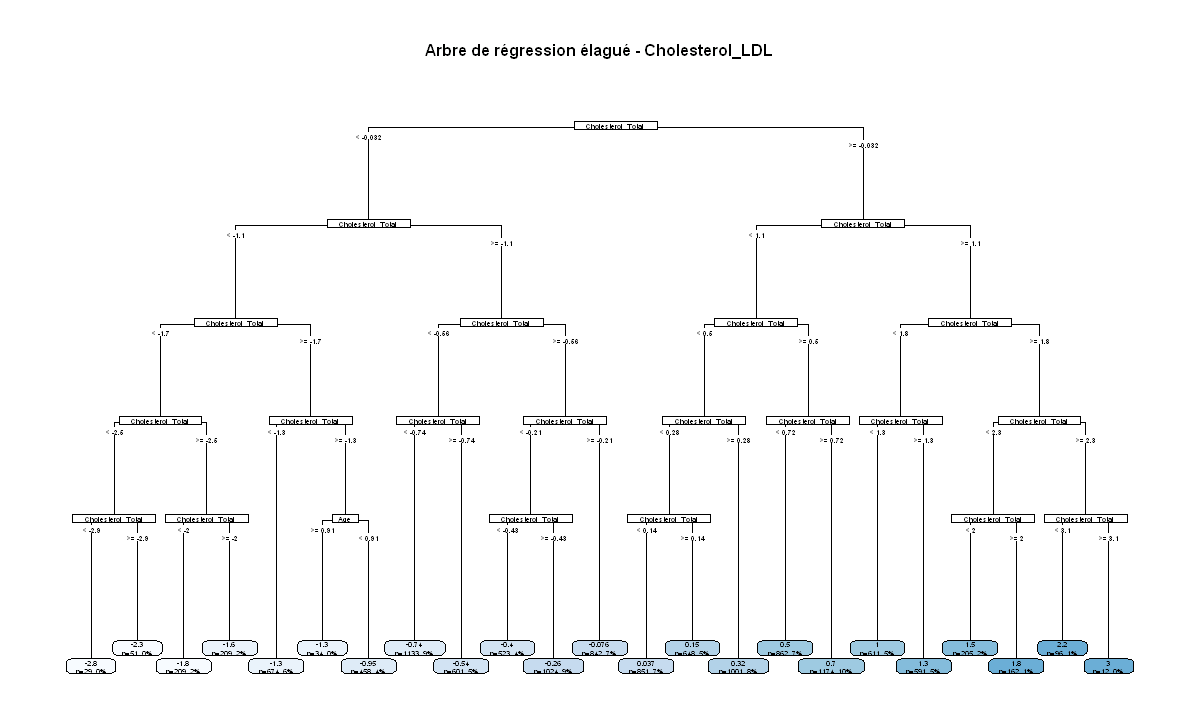

In [ ]:
# Élagage par validation croisée
# On minimise xerror (erreur CV estimée) pour sélectionner la taille de l'arbre.
opt_cp_reg <- tree.reg.full$cptable[which.min(tree.reg.full$cptable[, "xerror"]), "CP"]
cat("cp optimal :", opt_cp_reg, "\n")

tree.reg <- prune(tree.reg.full, cp = opt_cp_reg)

cat("Nombre de feuilles :", sum(tree.reg$frame$var == "<leaf>"), "\n")

# options(repr.plot.width = 18, repr.plot.height = 9) # 21 feuilles
rpart.plot(
  tree.reg,
  type  = 5,
  extra = 101,
  main  = "Arbre de régression élagué - Cholesterol_LDL"
)

Problème de data leakage : on n'a que `Cholesterol_Total` dans l'arbre.

Dans un premier temps, on va enlever `Cholesterol_Total` (`datappr.v2`), puis on va aussi enlever (`Cholesterol_HDL`) des données d'études (datappr.v3).

In [ ]:
# construction de l'échantillon d'apprentissage sans Cholesterol_Total (peut-être enlever aussi les autres variables de cholestérol ? index = 11)
datappr0.v2 <- data[appri, -c(1, 9, 19)]

# construction de l'échantillon test
datestr0.v2 <- data[testi, -c(1, 9, 19)] 

# vérification
str(datappr0.v2)
str(datestr0.v2)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0.v2, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr.v2 <- datappr0.v2
datappr.v2[, num_cols] <- scale(datappr0.v2[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr.v2 <- datestr0.v2
datestr.v2[, num_cols] <- scale(
  datestr0.v2[, num_cols],
  center = sapply(datappr0.v2[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0.v2[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
# summary(datappr.v2)
# summary(datestr.v2)

'data.frame':	12000 obs. of  16 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 4 2 1 2 2 3 3 3

In [ ]:
# construction de l'échantillon d'apprentissage sans Cholesterol_Total et Cholesterol_LDL (index = 9 et 11)
datappr0.v3 <- data[appri, -c(1, 9, 11, 19)]

# construction de l'échantillon test
datestr0.v3 <- data[testi, -c(1, 9, 11, 19)] 

# vérification
str(datappr0.v3)
str(datestr0.v3)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0.v3, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr.v3 <- datappr0.v3
datappr.v3[, num_cols] <- scale(datappr0.v3[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr.v3 <- datestr0.v3
datestr.v3[, num_cols] <- scale(
  datestr0.v3[, num_cols],
  center = sapply(datappr0.v3[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0.v3[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
# summary(datappr.v3)
# summary(datestr.v3)

'data.frame':	12000 obs. of  15 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 4 2 1 2 2 3 3 3 3 1 ...
 $ Family_History         : Factor w/ 2 levels "0","1": 1 

In [ ]:
# Arbre de régression complet (sans Cholesterol_Total)
tree.reg.full.v2 <- rpart(
  Cholesterol_LDL ~ .,
  data    = datappr.v2,
  method  = "anova",
  control = rpart.control(cp = 0.0001)
)

printcp(tree.reg.full.v2)


Regression tree:
rpart(formula = Cholesterol_LDL ~ ., data = datappr.v2, method = "anova", 
    control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
 [1] Age                     Alcohol_Consumption     BMI                    
 [4] Cholesterol_HDL         Diastolic_BP            Family_History         
 [7] Fasting_Blood_Sugar     Gender                  Height_cm              
[10] Physical_Activity_Level Sleep_Hours             Smoking_Status         
[13] Stress_Level            Systolic_BP             Weight_kg              

Root node error: 11999/12000 = 0.99992

n= 12000 

            CP nsplit rel error  xerror     xstd
1   0.08252029      0   1.00000 1.00025 0.013178
2   0.02308230      1   0.91748 0.92204 0.012108
3   0.01041932      2   0.89440 0.89797 0.011810
4   0.00927447      3   0.88398 0.88611 0.011657
5   0.00569040      4   0.87470 0.87995 0.011575
6   0.00542922      5   0.86901 0.87759 0.011583
7   0.00371108      6   0.86358 0.87174

In [ ]:
# Arbre de régression complet (sans Cholesterol_Total et sans Cholesterol_LDL)
tree.reg.full.v3 <- rpart(
  Cholesterol_LDL ~ .,
  data    = datappr.v3,
  method  = "anova",
  control = rpart.control(cp = 0.0001)
)

printcp(tree.reg.full.v3)


Regression tree:
rpart(formula = Cholesterol_LDL ~ ., data = datappr.v3, method = "anova", 
    control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
 [1] Age                     Alcohol_Consumption     BMI                    
 [4] Diastolic_BP            Family_History          Fasting_Blood_Sugar    
 [7] Gender                  Height_cm               Physical_Activity_Level
[10] Sleep_Hours             Smoking_Status          Stress_Level           
[13] Systolic_BP             Weight_kg              

Root node error: 11999/12000 = 0.99992

n= 12000 

            CP nsplit rel error  xerror     xstd
1   0.08252029      0   1.00000 1.00014 0.013178
2   0.02308230      1   0.91748 0.92236 0.012122
3   0.01041932      2   0.89440 0.90104 0.011884
4   0.00927447      3   0.88398 0.88748 0.011694
5   0.00569040      4   0.87470 0.88132 0.011624
6   0.00542922      5   0.86901 0.87725 0.011585
7   0.00371108      6   0.86358 0.87156 0.011513
8   0.00301366

cp optimal : 0.0008395118 
Nombre de feuilles : 24 


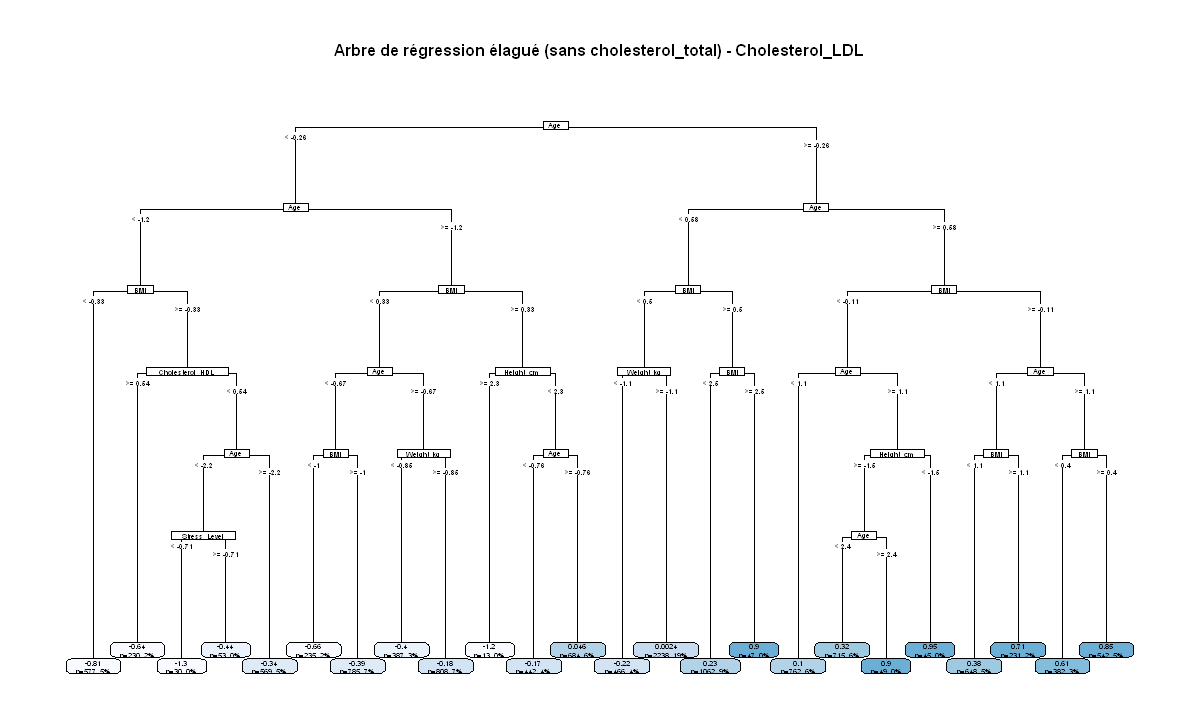

In [ ]:
# Élagage par validation croisée (sans Cholesterol_Total)
# On minimise xerror (erreur CV estimée) pour sélectionner la taille de l'arbre.
opt_cp_reg <- tree.reg.full.v2$cptable[which.min(tree.reg.full.v2$cptable[, "xerror"]), "CP"]
cat("cp optimal :", opt_cp_reg, "\n")

tree.reg.v2 <- prune(tree.reg.full.v2, cp = opt_cp_reg)

cat("Nombre de feuilles :", sum(tree.reg.v2$frame$var == "<leaf>"), "\n")

# options(repr.plot.width = 18, repr.plot.height = 9) # 25 feuilles
rpart.plot(
  tree.reg.v2,
  type  = 5,
  extra = 101,
  main  = "Arbre de régression élagué (sans cholesterol_total) - Cholesterol_LDL"
)

cp optimal : 0.0008687105 
Nombre de feuilles : 21 


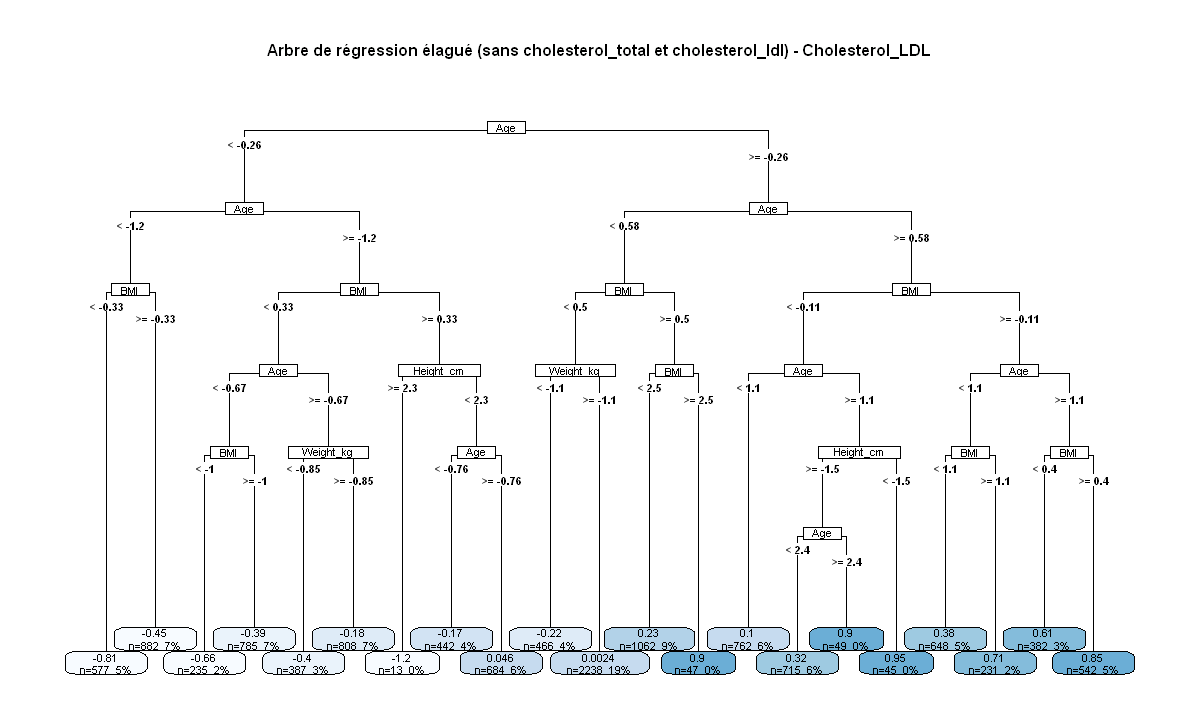

In [ ]:
# Élagage par validation croisée (sans Cholesterol_Total et Cholesterol_LDL)
# On minimise xerror (erreur CV estimée) pour sélectionner la taille de l'arbre.
opt_cp_reg <- tree.reg.full.v3$cptable[which.min(tree.reg.full.v3$cptable[, "xerror"]), "CP"]
cat("cp optimal :", opt_cp_reg, "\n")

tree.reg.v3 <- prune(tree.reg.full.v3, cp = opt_cp_reg)

cat("Nombre de feuilles :", sum(tree.reg.v3$frame$var == "<leaf>"), "\n")

# options(repr.plot.width = 18, repr.plot.height = 9) # 25 feuilles
rpart.plot(
  tree.reg.v3,
  type  = 5,
  extra = 101,
  main  = "Arbre de régression élagué (sans cholesterol_total et cholesterol_ldl) - Cholesterol_LDL"
)

### 4.3.2 Évaluation sur l'échantillon test

In [ ]:
# Prédictions et métriques 
pred_tree_reg_test <- predict(tree.reg, datestr)

rmse_tree_reg <- sqrt(mean((pred_tree_reg_test - datestr$Cholesterol_LDL)^2))
mae_tree_reg <- mean(abs(pred_tree_reg_test - datestr$Cholesterol_LDL))
ss_tot_reg    <- sum((datestr$Cholesterol_LDL - mean(datestr$Cholesterol_LDL))^2)
r2_tree_reg   <- 1 - sum((pred_tree_reg_test - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Avec cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_tree_reg))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_tree_reg))
cat(sprintf("R²   (test) : %.4f\n",        r2_tree_reg))

[1] "Avec cholesterol_total :"
RMSE (test) : 0.5620 mg/dL
MAE  (test) : 0.4469 mg/dL
R²   (test) : 0.6767


In [ ]:
# Prédictions et métriques (sans cholesterol_total)
pred_tree_reg_test.v2 <- predict(tree.reg.v2, datestr)

rmse_tree_reg.v2 <- sqrt(mean((pred_tree_reg_test.v2 - datestr$Cholesterol_LDL)^2))
mae_tree_reg.v2  <- mean(abs(pred_tree_reg_test.v2 - datestr$Cholesterol_LDL))
ss_tot_reg.v2    <- sum((datestr$Cholesterol_LDL - mean(datestr$Cholesterol_LDL))^2)
r2_tree_reg.v2   <- 1 - sum((pred_tree_reg_test.v2 - datestr$Cholesterol_LDL)^2) / ss_tot_reg.v2

print("Sans cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_tree_reg.v2))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_tree_reg.v2))
cat(sprintf("R²   (test) : %.4f\n",        r2_tree_reg.v2))

[1] "Sans cholesterol_total :"
RMSE (test) : 0.9183 mg/dL
MAE  (test) : 0.7363 mg/dL
R²   (test) : 0.1367


In [ ]:
# Prédictions et métriques (sans Cholesterol_total et sans Cholesterol_LDL)
pred_tree_reg_test.v3 <- predict(tree.reg.v3, datestr)

rmse_tree_reg.v3 <- sqrt(mean((pred_tree_reg_test.v3 - datestr$Cholesterol_LDL)^2))
mae_tree_reg.v3  <- mean(abs(pred_tree_reg_test.v3 - datestr$Cholesterol_LDL))
ss_tot_reg.v3    <- sum((datestr$Cholesterol_LDL - mean(datestr$Cholesterol_LDL))^2)
r2_tree_reg.v3   <- 1 - sum((pred_tree_reg_test.v3 - datestr$Cholesterol_LDL)^2) / ss_tot_reg.v3

print("Sans cholesterol_total et sans cholesterol_ldl :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_tree_reg.v3))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_tree_reg.v3))
cat(sprintf("R²   (test) : %.4f\n",        r2_tree_reg.v3))

[1] "Sans cholesterol_total et sans cholesterol_ldl :"
RMSE (test) : 0.9182 mg/dL
MAE  (test) : 0.7360 mg/dL
R²   (test) : 0.1369


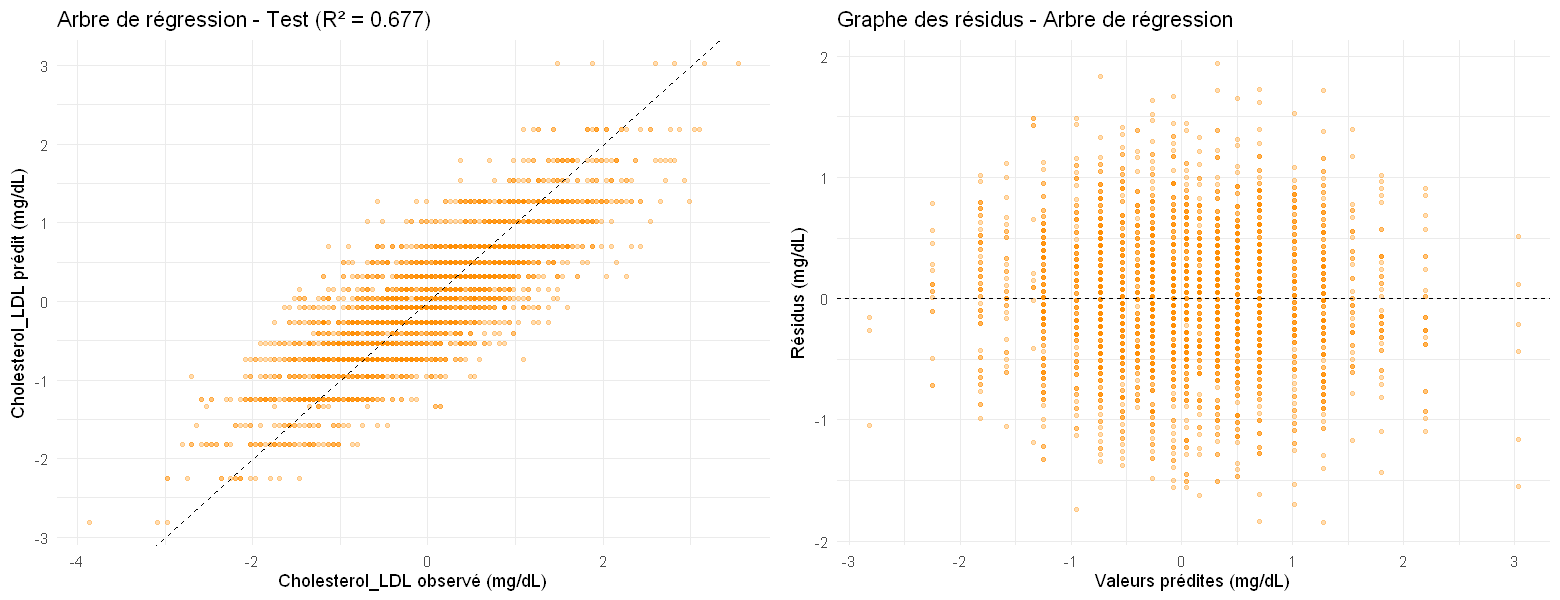

In [ ]:
# Graphes valeurs prédites et résidus
df_tree_reg <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_tree_reg_test,
  residus  = datestr$Cholesterol_LDL - pred_tree_reg_test
)

p1 <- ggplot(df_tree_reg, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Arbre de régression - Test (R² = %.3f)", r2_tree_reg)) +
  theme_minimal()

p2 <- ggplot(df_tree_reg, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Arbre de régression") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

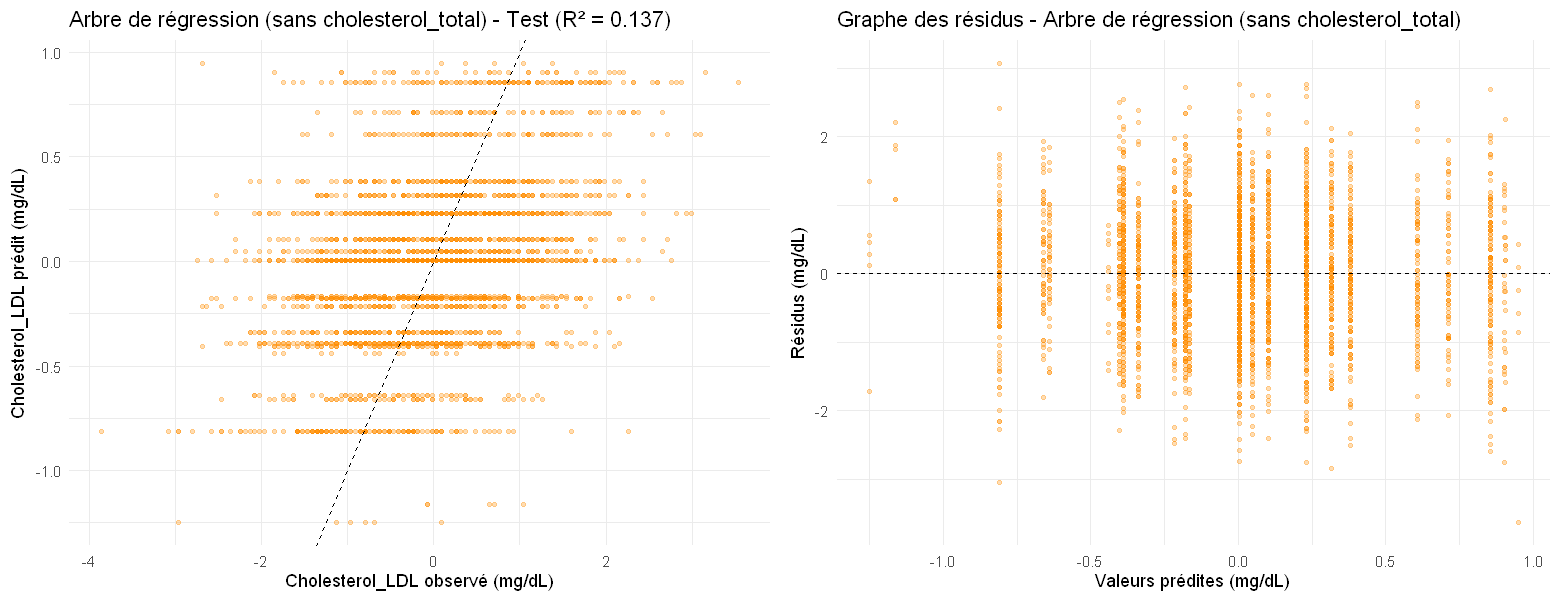

In [ ]:
# Graphes valeurs prédites et résidus (sans cholesterol_total)
df_tree_reg.v2 <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_tree_reg_test.v2,
  residus  = datestr$Cholesterol_LDL - pred_tree_reg_test.v2
)

p1 <- ggplot(df_tree_reg.v2, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Arbre de régression (sans cholesterol_total) - Test (R² = %.3f)", r2_tree_reg.v2)) +
  theme_minimal()

p2 <- ggplot(df_tree_reg.v2, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Arbre de régression (sans cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

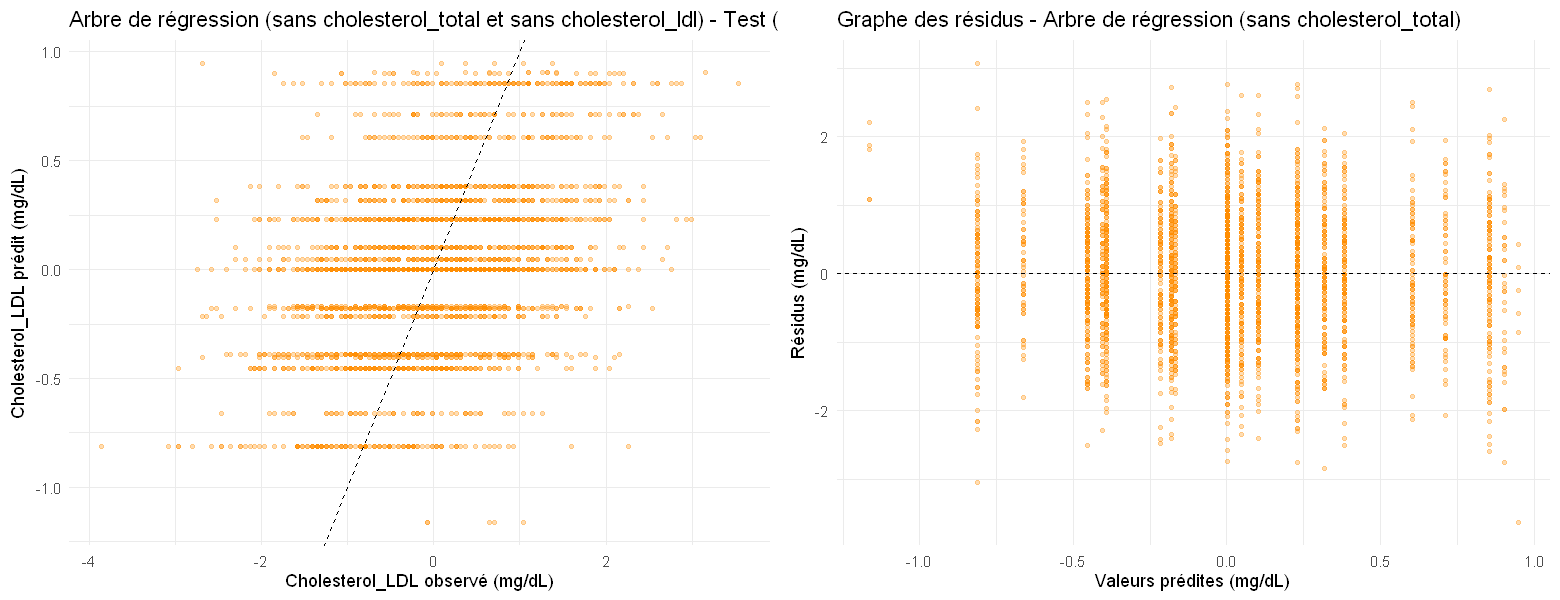

In [ ]:
# Graphes valeurs prédites et résidus (sans cholesterol_total et sans cholesterol_ldl)
df_tree_reg.v3 <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_tree_reg_test.v3,
  residus  = datestr$Cholesterol_LDL - pred_tree_reg_test.v3
)

p1 <- ggplot(df_tree_reg.v3, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Arbre de régression (sans cholesterol_total et sans cholesterol_ldl) - Test (R² = %.3f)", r2_tree_reg.v3)) +
  theme_minimal()

p2 <- ggplot(df_tree_reg.v3, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Arbre de régression (sans cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

### 4.3.3 Importance des variables

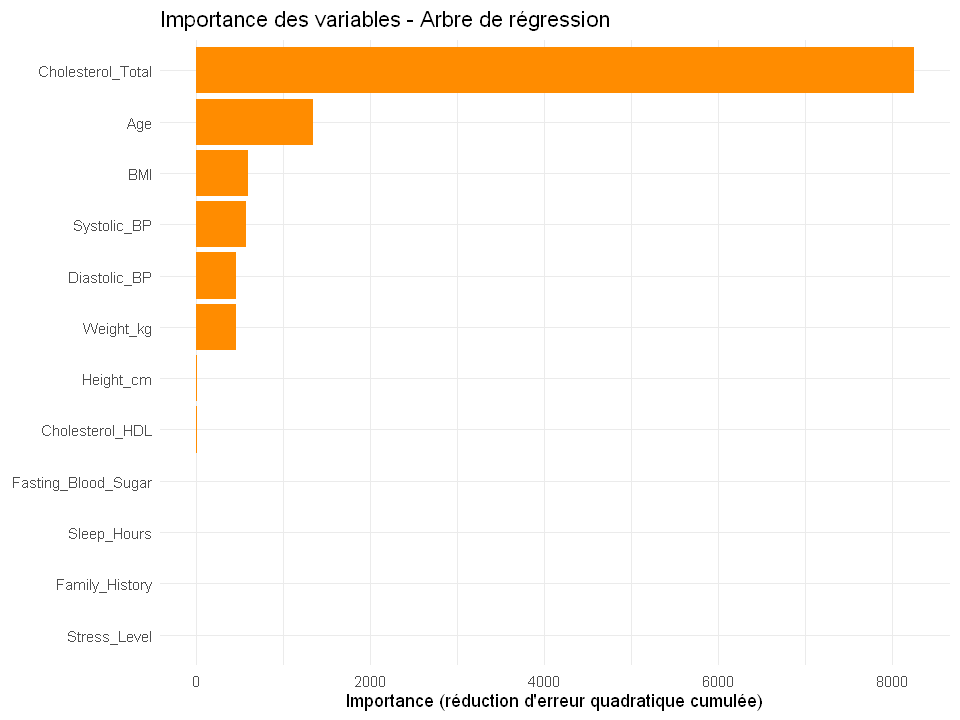

In [ ]:
# Importance des variables (arbre de régression)
imp_reg <- tree.reg$variable.importance
imp_reg_df <- data.frame(
  variable   = names(imp_reg),
  importance = as.numeric(imp_reg)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_reg_df, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction d'erreur quadratique cumulée)",
       title = "Importance des variables - Arbre de régression") +
  theme_minimal()

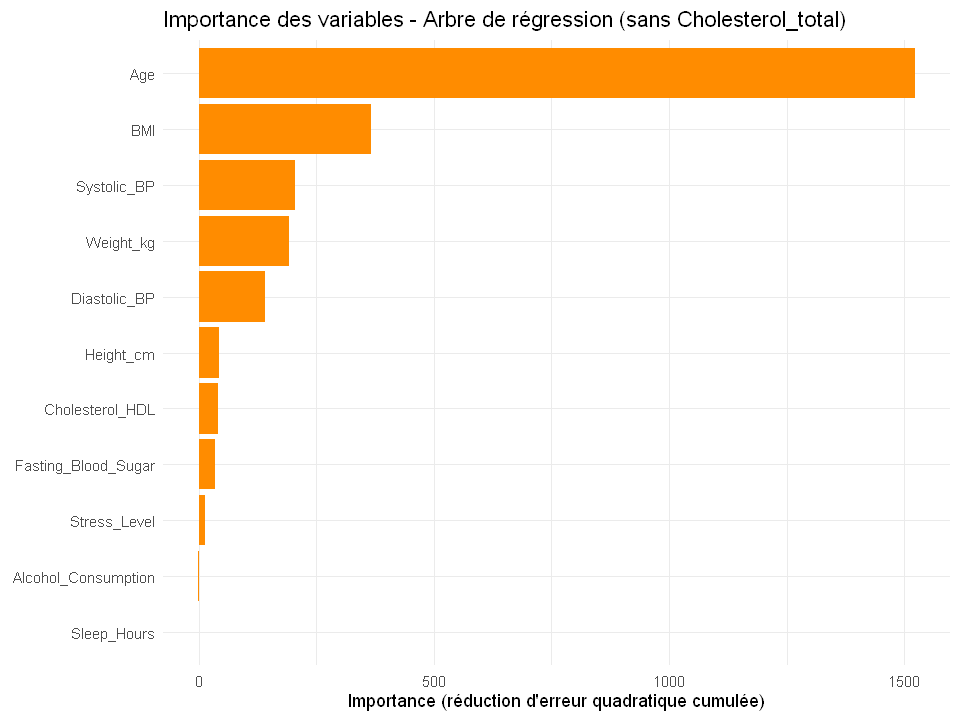

In [ ]:
# Importance des variables (arbre de régression) (sans Cholesterol_total)
imp_reg.v2 <- tree.reg.v2$variable.importance
imp_reg_df.v2 <- data.frame(
  variable   = names(imp_reg.v2),
  importance = as.numeric(imp_reg.v2)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_reg_df.v2, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction d'erreur quadratique cumulée)",
       title = "Importance des variables - Arbre de régression (sans Cholesterol_total)") +
  theme_minimal()

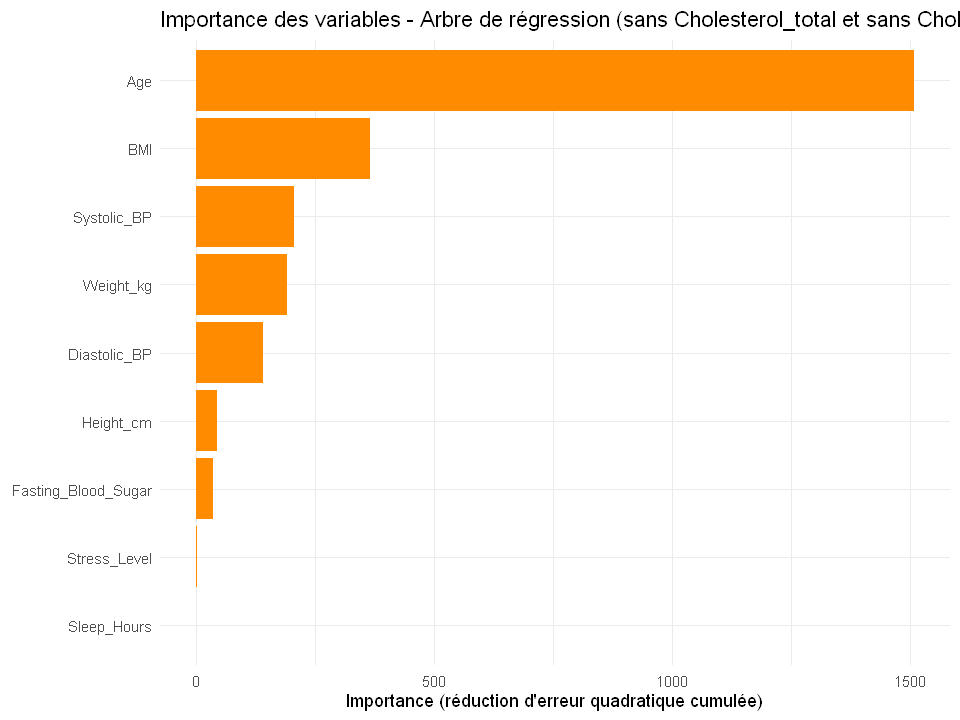

In [ ]:
# Importance des variables (arbre de régression) (sans Cholesterol_total et sans Cholesterol_LDL)
imp_reg.v3 <- tree.reg.v3$variable.importance
imp_reg_df.v3 <- data.frame(
  variable   = names(imp_reg.v3),
  importance = as.numeric(imp_reg.v3)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_reg_df.v3, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction d'erreur quadratique cumulée)",
       title = "Importance des variables - Arbre de régression (sans Cholesterol_total et sans Cholesterol_LDL)") +
  theme_minimal()

### 4.5.4 Bilan - Arbre binaire de régression (`Cholesterol_LDL`)

In [ ]:
# Tableau récapitulatif (régression)
resultats_reg <- data.frame(
  Modele = c("Arbre CART (élagué)", "Arbre CART (élagué) (sans CT)", "Arbre CART (élagué) (sans CT+HDL)"),
  RMSE   = round(c(rmse_tree_reg, rmse_tree_reg.v2, rmse_tree_reg.v3), 4),
  MAE    = round(c(mae_tree_reg,  mae_tree_reg.v2, mae_tree_reg.v3),  4),
  R2     = round(c(r2_tree_reg,   r2_tree_reg.v2, r2_tree_reg.v3),   4)
)
print(resultats_reg)

                             Modele   RMSE    MAE     R2
1               Arbre CART (élagué) 0.5620 0.4469 0.6767
2     Arbre CART (élagué) (sans CT) 0.9183 0.7363 0.1367
3 Arbre CART (élagué) (sans CT+HDL) 0.9182 0.7360 0.1369
4                   Forêt aléatoire 0.5661 0.4504 0.6719
5         Forêt aléatoire (sans CT) 0.9228 0.7403 0.1283


---
## 4.4 Régression par forêt aléatoire

En régression, la forêt prédit la **moyenne** des prédictions des $B$ arbres. La recommandation pour $m$ est $p/3$.

### 4.4.1 Analyse de convergence et optimisation de `mtry`

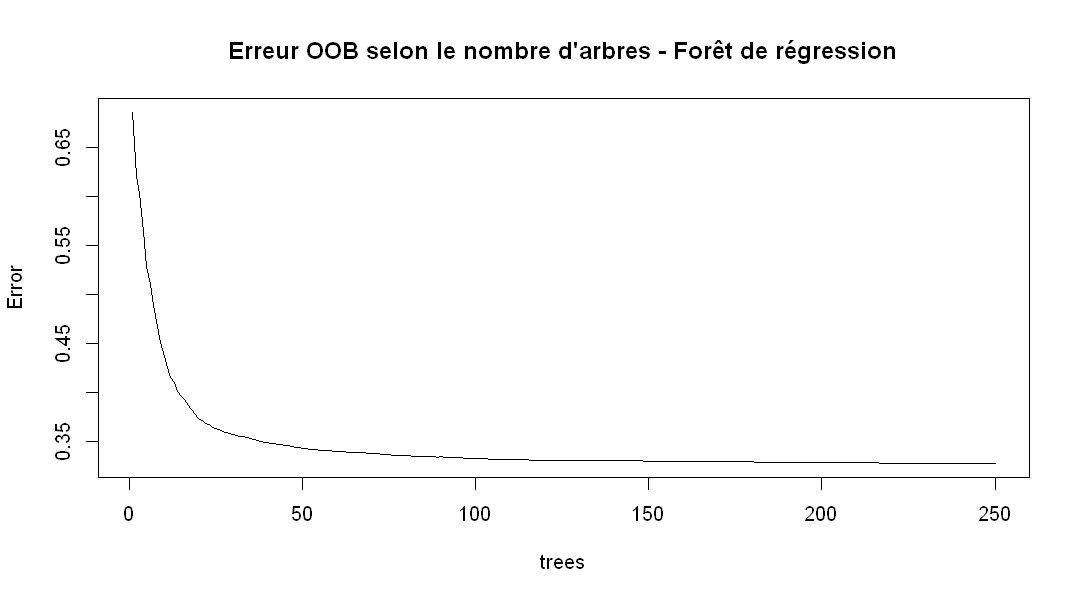

In [ ]:
# Convergence de l'erreur OOB (régression)
set.seed(111)
rf.reg.conv <- randomForest(
  Cholesterol_LDL ~ .,
  data  = datappr,
  ntree = 250,
  mtry  = floor((ncol(datappr) - 1) / 3)  # p/3 : règle empirique régression
)

options(repr.plot.width = 9, repr.plot.height = 5)
plot(rf.reg.conv,
     main = "Erreur OOB selon le nombre d'arbres - Forêt de régression")

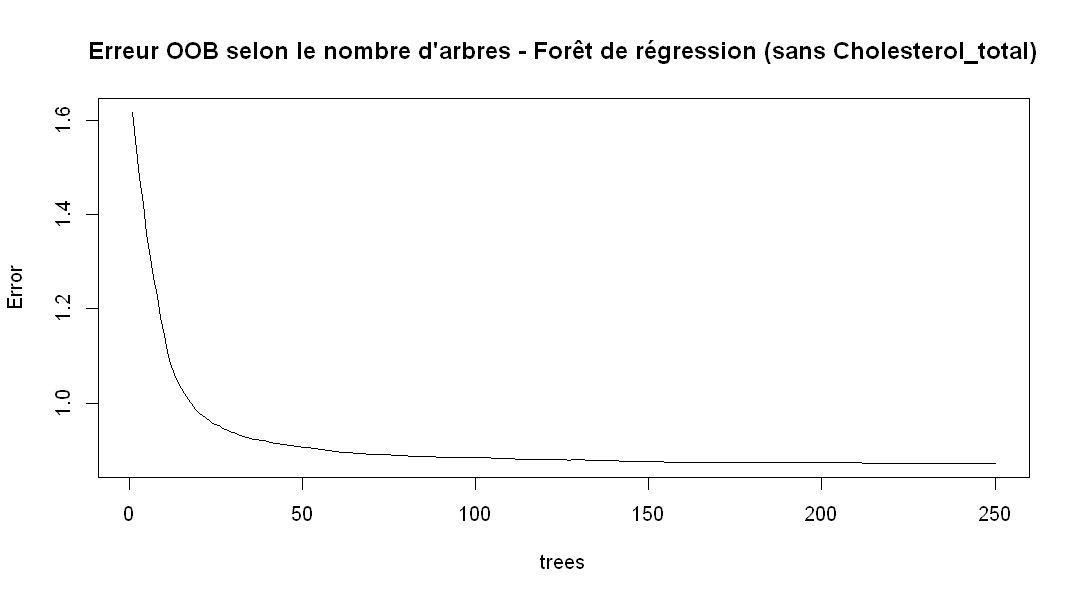

In [ ]:
# Convergence de l'erreur OOB (régression) (sans Cholesterol_total)
set.seed(111)
rf.reg.conv.v2 <- randomForest(
  Cholesterol_LDL ~ .,
  data  = datappr.v2,
  ntree = 250,
  mtry  = floor((ncol(datappr.v2) - 1) / 3)  # p/3 : règle empirique régression
)

options(repr.plot.width = 9, repr.plot.height = 5)
plot(rf.reg.conv.v2,
     main = "Erreur OOB selon le nombre d'arbres - Forêt de régression (sans Cholesterol_total)")

  mtry   oob_mse
1    2 0.3904868
2    4 0.3395296
3    5 0.3339317
4    8 0.3294470
5   16 0.3332054

mtry optimal : 8  (MSE OOB = 0.3294)


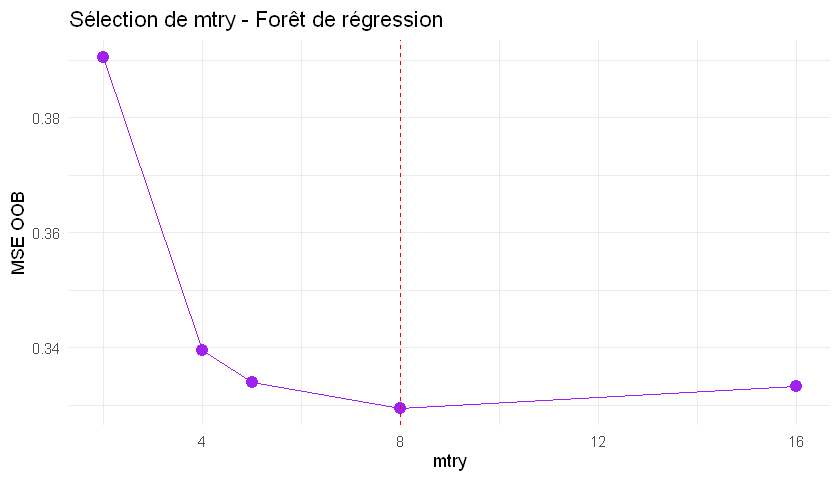

In [ ]:
# Sélection de mtry par erreur OOB
set.seed(111)
p_reg <- ncol(datappr) - 1

mtry_vals_reg <- sort(unique(c(
  2,
  floor(p_reg / 3),    # p/3 : règle empirique régression
  floor(sqrt(p_reg)),
  floor(p_reg / 2),
  p_reg
)))

oob_mse_mtry <- sapply(mtry_vals_reg, function(m) {
  rf <- randomForest(Cholesterol_LDL ~ ., data = datappr, ntree = 100, mtry = m)
  tail(rf$mse, 1)  # MSE OOB finale
})

df_mtry_reg <- data.frame(mtry = mtry_vals_reg, oob_mse = oob_mse_mtry)
print(df_mtry_reg)

best_mtry_reg <- mtry_vals_reg[which.min(oob_mse_mtry)]
cat(sprintf("\nmtry optimal : %d  (MSE OOB = %.4f)\n",
            best_mtry_reg, min(oob_mse_mtry)))

options(repr.plot.width = 7, repr.plot.height = 4)
ggplot(df_mtry_reg, aes(x = mtry, y = oob_mse)) +
  geom_line(colour = "purple") + geom_point(colour = "purple", size = 3) +
  geom_vline(xintercept = best_mtry_reg, linetype = "dashed", colour = "red") +
  labs(x = "mtry", y = "MSE OOB",
       title = "Sélection de mtry - Forêt de régression") +
  theme_minimal()

  mtry   oob_mse
1    2 0.8828354
2    3 0.8834787
3    5 0.8843018
4    7 0.8950943
5   15 0.8971283

mtry optimal : 2  (MSE OOB = 0.8828)


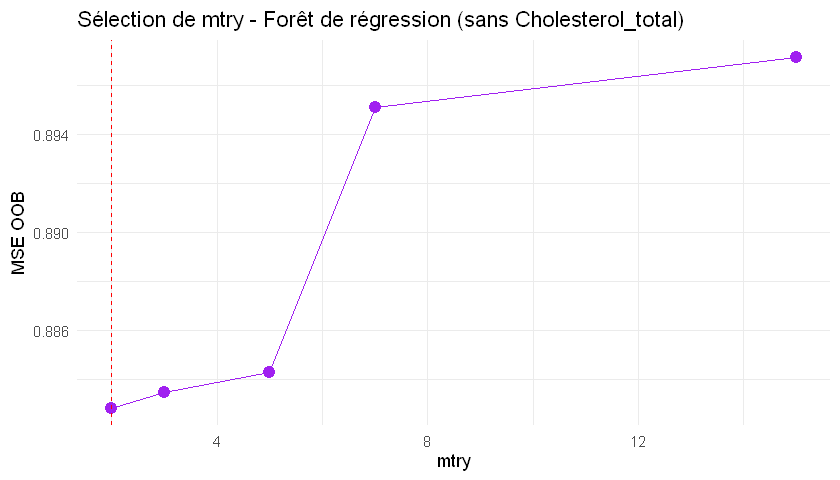

In [ ]:
# Sélection de mtry par erreur OOB (régression) (sans Cholesterol_total)
set.seed(111)
p_reg <- ncol(datappr.v2) - 1

mtry_vals_reg.v2 <- sort(unique(c(
  2,
  floor(p_reg / 3),    # p/3 : règle empirique régression
  floor(sqrt(p_reg)),
  floor(p_reg / 2),
  p_reg
)))

oob_mse_mtry.v2 <- sapply(mtry_vals_reg.v2, function(m) {
  rf <- randomForest(Cholesterol_LDL ~ ., data = datappr.v2, ntree = 100, mtry = m)
  tail(rf$mse, 1)  # MSE OOB finale
})

df_mtry_reg.v2 <- data.frame(mtry = mtry_vals_reg.v2, oob_mse = oob_mse_mtry.v2)
print(df_mtry_reg.v2)

best_mtry_reg.v2 <- mtry_vals_reg.v2[which.min(oob_mse_mtry.v2)]
cat(sprintf("\nmtry optimal : %d  (MSE OOB = %.4f)\n",
            best_mtry_reg.v2, min(oob_mse_mtry.v2)))

options(repr.plot.width = 7, repr.plot.height = 4)
ggplot(df_mtry_reg.v2, aes(x = mtry, y = oob_mse)) +
  geom_line(colour = "purple") + geom_point(colour = "purple", size = 3) +
  geom_vline(xintercept = best_mtry_reg.v2, linetype = "dashed", colour = "red") +
  labs(x = "mtry", y = "MSE OOB",
       title = "Sélection de mtry - Forêt de régression (sans Cholesterol_total)") +
  theme_minimal()

In [ ]:
# Modèle final (forêt de régression)
set.seed(111)
rf.reg <- randomForest(
  Cholesterol_LDL ~ .,
  data       = datappr,
  ntree      = 100,
  mtry       = best_mtry_reg,
  importance = TRUE
)

print("Avec Cholesterol_total :")

print(rf.reg)
cat(sprintf("R² OOB : %.4f\n", tail(rf.reg$rsq, 1)))

[1] "Avec Cholesterol_total :"

Call:
 randomForest(formula = Cholesterol_LDL ~ ., data = datappr, ntree = 100,      mtry = best_mtry_reg, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 100
No. of variables tried at each split: 8

          Mean of squared residuals: 0.3297619
                    % Var explained: 67.02
R² OOB : 0.6702


In [ ]:
# Modèle final (forêt de régression) (sans Cholesterol_total)
set.seed(111)
rf.reg.v2 <- randomForest(
  Cholesterol_LDL ~ .,
  data       = datappr.v2,
  ntree      = 100,
  mtry       = best_mtry_reg.v2,
  importance = TRUE
)

print("Sans Cholesterol_total :")

print(rf.reg.v2)
cat(sprintf("R² OOB : %.4f\n", tail(rf.reg.v2$rsq, 1)))

[1] "Sans Cholesterol_total :"

Call:
 randomForest(formula = Cholesterol_LDL ~ ., data = datappr.v2,      ntree = 100, mtry = best_mtry_reg.v2, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 100
No. of variables tried at each split: 2

          Mean of squared residuals: 0.890647
                    % Var explained: 10.93
R² OOB : 0.1093


### 4.4.2 Évaluation sur l'échantillon test

In [ ]:
# Prédictions test et métriques
pred_rf_reg_test <- predict(rf.reg, datestr)

rmse_rf_reg <- sqrt(mean((pred_rf_reg_test - datestr$Cholesterol_LDL)^2))
mae_rf_reg  <- mean(abs(pred_rf_reg_test - datestr$Cholesterol_LDL))
r2_rf_reg   <- 1 - sum((pred_rf_reg_test - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Avec Cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_rf_reg))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_rf_reg))
cat(sprintf("R²   (test) : %.4f\n",        r2_rf_reg))

[1] "Avec Cholesterol_total :"
RMSE (test) : 0.5661 mg/dL
MAE  (test) : 0.4504 mg/dL
R²   (test) : 0.6719


In [ ]:
# Prédictions test et métriques (sans Cholesterol_total)
pred_rf_reg_test.v2 <- predict(rf.reg.v2, datestr)

rmse_rf_reg.v2 <- sqrt(mean((pred_rf_reg_test.v2 - datestr$Cholesterol_LDL)^2))
mae_rf_reg.v2  <- mean(abs(pred_rf_reg_test.v2 - datestr$Cholesterol_LDL))
r2_rf_reg.v2   <- 1 - sum((pred_rf_reg_test.v2 - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Sans Cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_rf_reg.v2))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_rf_reg.v2))
cat(sprintf("R²   (test) : %.4f\n",        r2_rf_reg.v2))

[1] "Sans Cholesterol_total :"
RMSE (test) : 0.9228 mg/dL
MAE  (test) : 0.7403 mg/dL
R²   (test) : 0.1283


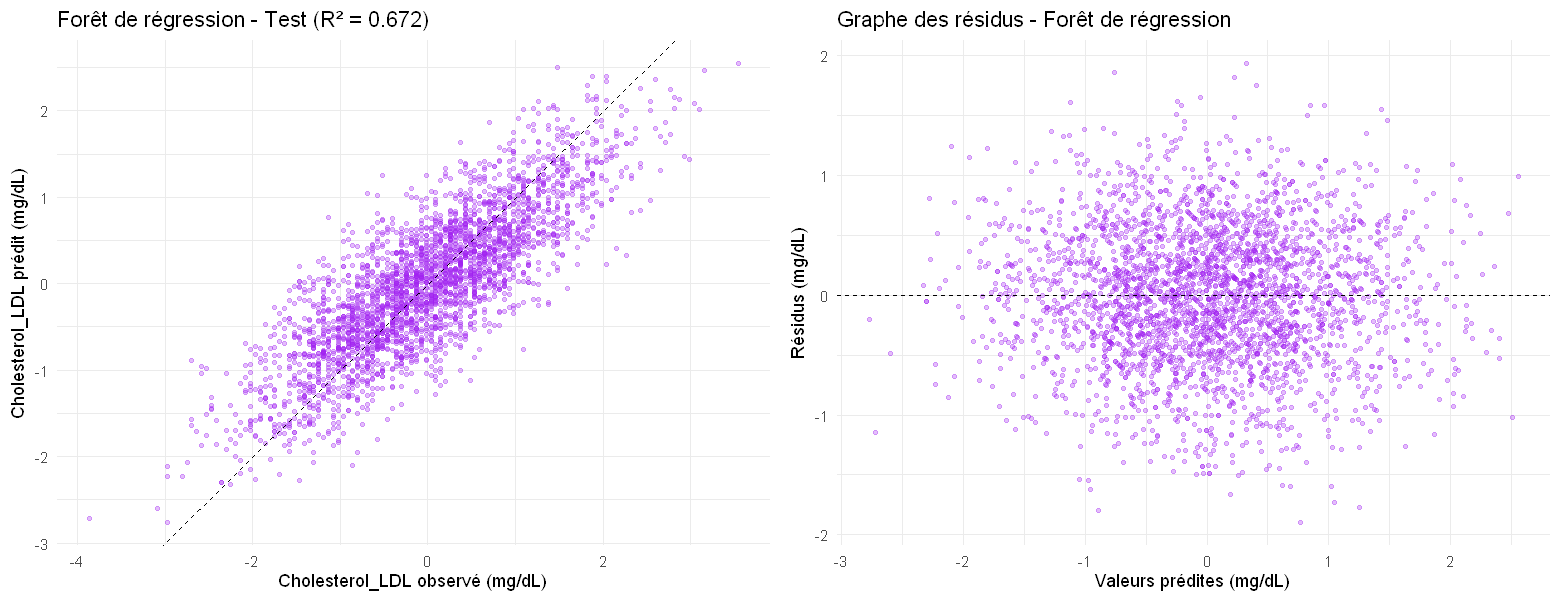

In [ ]:
# Graphes valeurs prédites et résidus
df_rf_reg <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_rf_reg_test,
  residus  = datestr$Cholesterol_LDL - pred_rf_reg_test
)

p3 <- ggplot(df_rf_reg, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Forêt de régression - Test (R² = %.3f)", r2_rf_reg)) +
  theme_minimal()

p4 <- ggplot(df_rf_reg, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Forêt de régression") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p3, p4, ncol = 2)

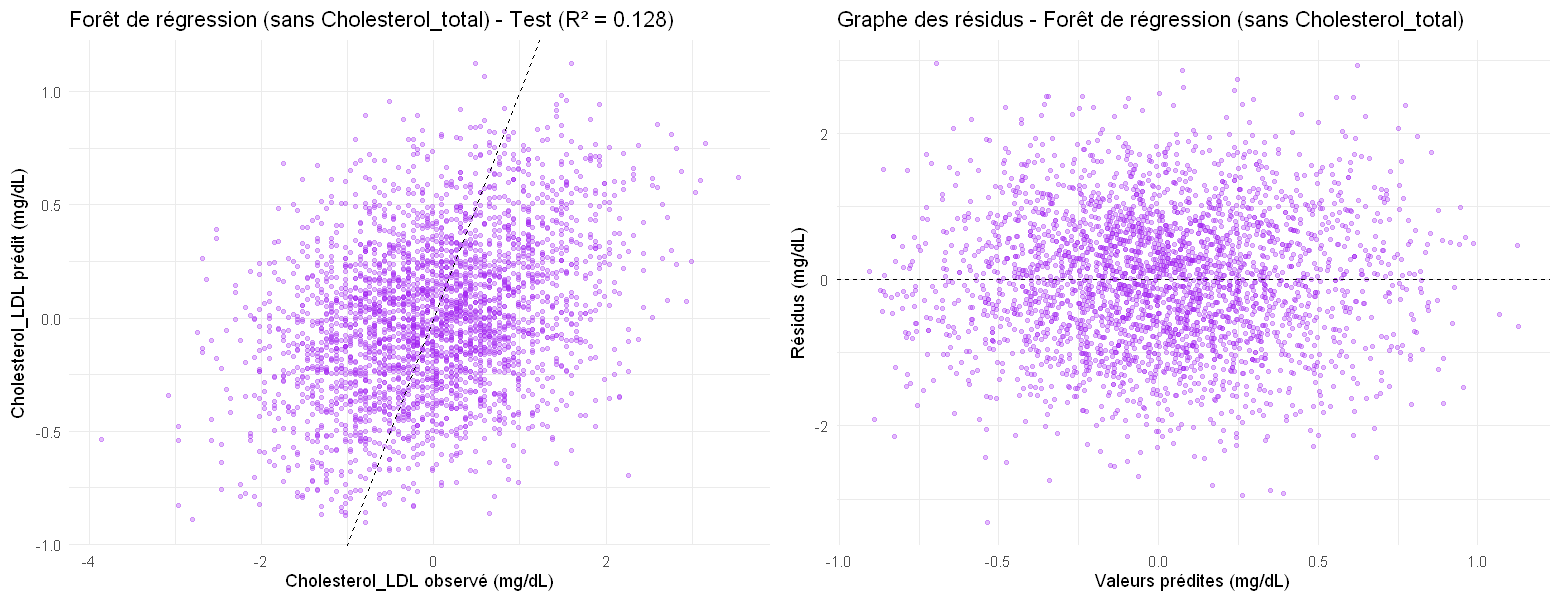

In [ ]:
# Graphes valeurs prédites et résidus (sans Cholesterol_total)
df_rf_reg.v2 <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_rf_reg_test.v2,
  residus  = datestr$Cholesterol_LDL - pred_rf_reg_test.v2
)

p3 <- ggplot(df_rf_reg.v2, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Forêt de régression (sans Cholesterol_total) - Test (R² = %.3f)", r2_rf_reg.v2)) +
  theme_minimal()

p4 <- ggplot(df_rf_reg.v2, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Forêt de régression (sans Cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p3, p4, ncol = 2)

### 4.4.3 Importance des variables

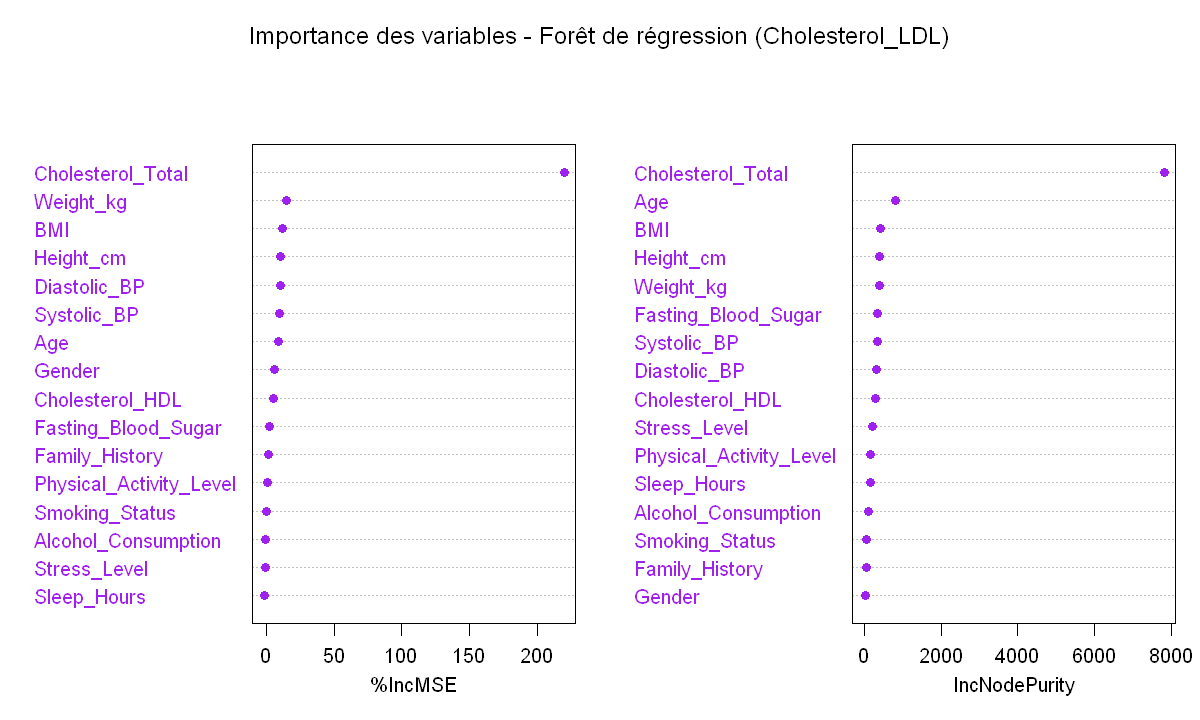

In [ ]:
# Graphe d'importance des variables (forêt de régression)
options(repr.plot.width = 10, repr.plot.height = 6)
varImpPlot(
  rf.reg,
  main = "Importance des variables - Forêt de régression (Cholesterol_LDL)",
  col  = "purple",
  pch  = 16
)

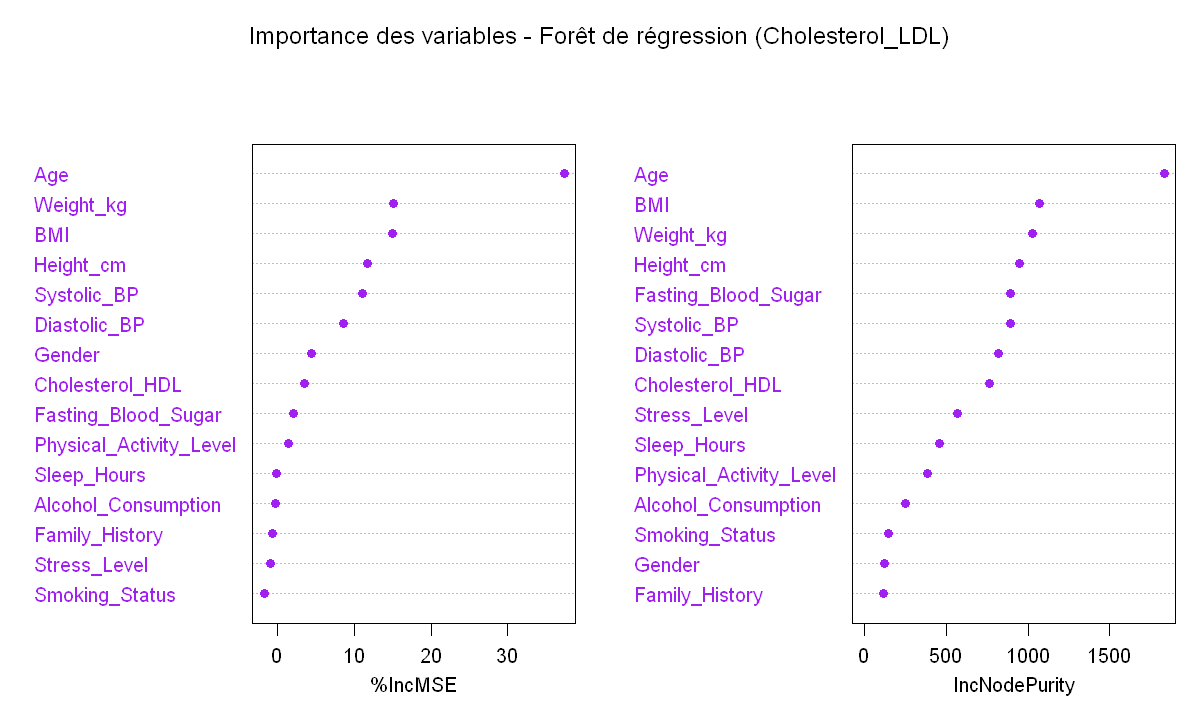

In [ ]:
# Graphe d'importance des variables (forêt de régression) (sans Cholesterol_total)
options(repr.plot.width = 10, repr.plot.height = 6)
varImpPlot(
  rf.reg.v2,
  main = "Importance des variables - Forêt de régression (Cholesterol_LDL)",
  col  = "purple",
  pch  = 16
)

### 4.4.4 Bilan - Régression forêt aléatoire (`Cholesterol_LDL`)

In [ ]:
# Tableau récapitulatif (régression)
resultats_reg <- data.frame(
  Modele = c("Forêt aléatoire", "Forêt aléatoire (sans CT)"),
  RMSE   = round(c(rmse_rf_reg, rmse_rf_reg.v2), 4),
  MAE    = round(c(mae_rf_reg, mae_rf_reg.v2), 4),
  R2     = round(c(r2_rf_reg, r2_rf_reg.v2), 4)
)
print(resultats_reg)

                             Modele   RMSE    MAE     R2
1               Arbre CART (élagué) 0.5620 0.4469 0.6767
2     Arbre CART (élagué) (sans CT) 0.9183 0.7363 0.1367
3 Arbre CART (élagué) (sans CT+HDL) 0.9182 0.7360 0.1369
4                   Forêt aléatoire 0.5661 0.4504 0.6719
5         Forêt aléatoire (sans CT) 0.9228 0.7403 0.1283


## 4.5 Prévision par réseaux de neurones

La méthodologie employée pour la régression est identique à celle utilisée pour la classification. La seule différence réside dans la nature de la variable cible : continue (Cholesterol_LDL) au lieu de binaire (Heart_Disease_Risk).

In [ ]:
datappr$Patient_ID <- NULL
datestr$Patient_ID <- NULL

### 4.5.1 Première optimisation grossière

Les paramètres testés sont les suivants. size (nombre de neurones dans la couche cachée) prend les valeurs 2, 5, 8 et 10. decay (coefficient de régularisation L2) prend les valeurs 0.001, 0.01, 0.1 et 1.

Plusieurs spécificités sont à noter pour la régression. L'option linout = TRUE est activée car la couche de sortie utilise une fonction d'activation linéaire , ce qui est essentiel puisque la variable cible Cholesterol_LDL est continue.

,size,decay
,<dbl>,<dbl>
1,2,0.001


[1] 0.3116498

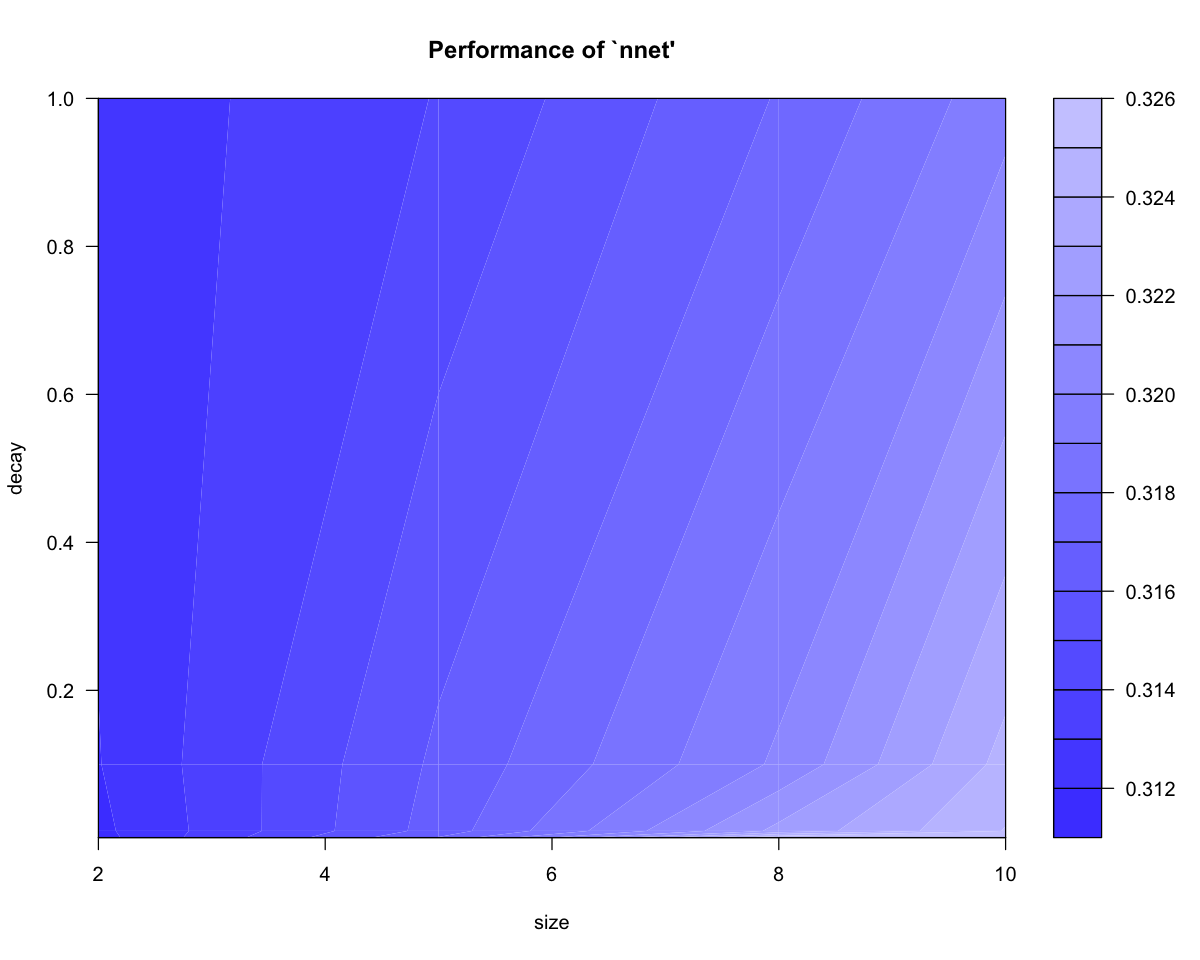

In [ ]:
set.seed(101)

tune.reg.optim1 <- tune.nnet(Cholesterol_LDL ~ .,
                              data    = datappr,
                              size    = c(2, 5, 8, 10),
                              decay   = c(0.001, 0.01, 0.1, 1),
                              maxit   = 500,
                              linout  = TRUE,
                              tunecontrol = tune.control(cross = 5))

plot(tune.reg.optim1)
tune.reg.optim1$best.parameters
tune.reg.optim1$best.performance  #MSE par défaut

Meilleurs paramètres : size = 2, decay = 0.01. 

MSE minimale : 0.3118

### 4.5.2 Optimisation fine

Suite aux résultats de la première optimisation, une seconde optimisation plus ciblée est réalisée en resserrant l'espace de recherche autour des valeurs prometteuses identifiées.

,size,decay
,<dbl>,<dbl>
1,1,0.005


[1] 0.3109776

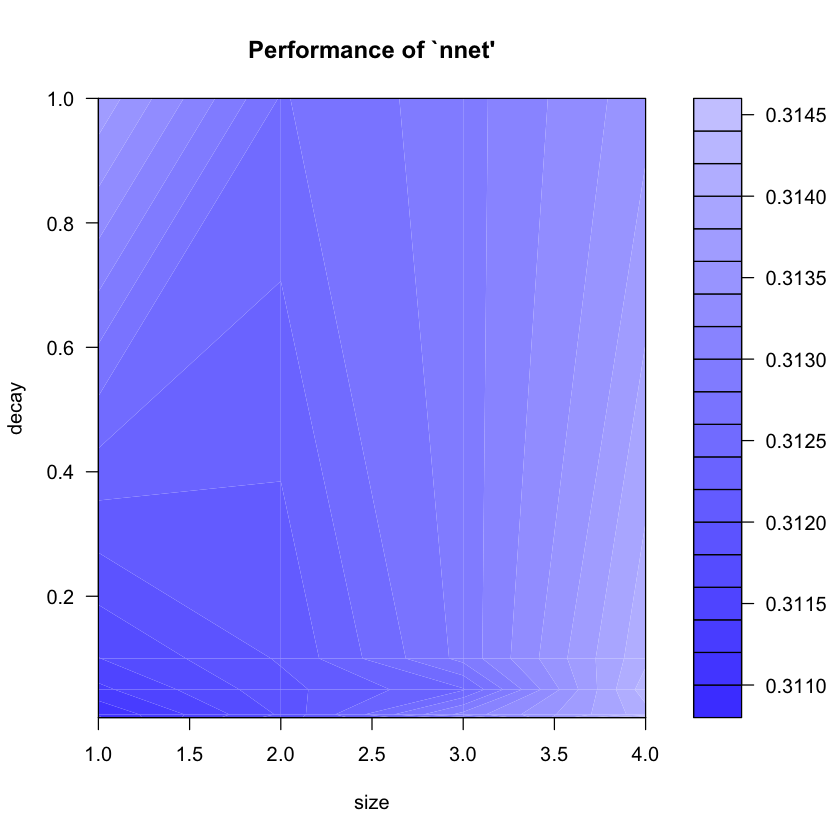

In [ ]:
set.seed(101)
#optimisation fine
tune.reg.optim2 <- tune.nnet(Cholesterol_LDL ~ .,
                        data    = datappr,
                        size  = c(1, 2, 3, 4),
                        decay = c(0.005, 0.01, 0.05, 0.1, 1),
                        maxit = 500,
                        linout  = TRUE)

plot(tune.reg.optim2)
tune.reg.optim2$best.parameters
tune.reg.optim2$best.performance

Meilleurs paramètres : size = 1 et decay = 0.005. 

Meilleure performance (MSE) : 0.3110

 La MSE est passée de 0.3118 à 0.3110, soit une réduction négligeable. L'optimisaiton fine a été utile pour simplifier l'architecture en passant à un résaux à 1 seul neuronne dans la couche cachée. 
 

### 4.5.3 Entraînement du modèle final de régression 

In [ ]:
#Model final
best_size_reg  <- tune.reg.optim2$best.parameters$size
best_decay_reg <- tune.reg.optim2$best.parameters$decay
cat("Optimal size :", best_size_reg, "\n")
cat("Optimal decay:", best_decay_reg, "\n")

set.seed(101)

nnet.reg.final <- nnet(Cholesterol_LDL ~ .,
                        data    = datappr,
                        size    = best_size_reg,
                        decay   = best_decay_reg,
                        maxit   = 500,
                        linout  = TRUE)

summary(nnet.reg.final)

Optimal size : 1 
Optimal decay: 0.005 
# weights:  22
initial  value 17498.465865 
iter  10 value 8830.441174
iter  20 value 7760.342823
iter  30 value 5771.244303
iter  40 value 4694.968425
iter  50 value 4214.919976
iter  60 value 4051.690308
iter  70 value 3876.371649
iter  80 value 3759.434906
iter  90 value 3731.571714
iter 100 value 3729.628578
iter 110 value 3729.430422
iter 120 value 3723.803567
iter 130 value 3721.828825
iter 140 value 3721.492721
final  value 3721.489901 
converged


a 19-1-1 network with 22 weights
options were - linear output units  decay=0.005
  b->h1  i1->h1  i2->h1  i3->h1  i4->h1  i5->h1  i6->h1  i7->h1  i8->h1  i9->h1 
   0.05    0.00    0.00    0.00   -0.01    0.01    0.00    0.00    0.20    0.00 
i10->h1 i11->h1 i12->h1 i13->h1 i14->h1 i15->h1 i16->h1 i17->h1 i18->h1 i19->h1 
   0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00 
 b->o h1->o 
-8.57 16.76 

### 4.5.4 Évaluation du modèle final sur l'échantillon test

RMSE : 9.9975 mg/dL
R²   : 0.6826 


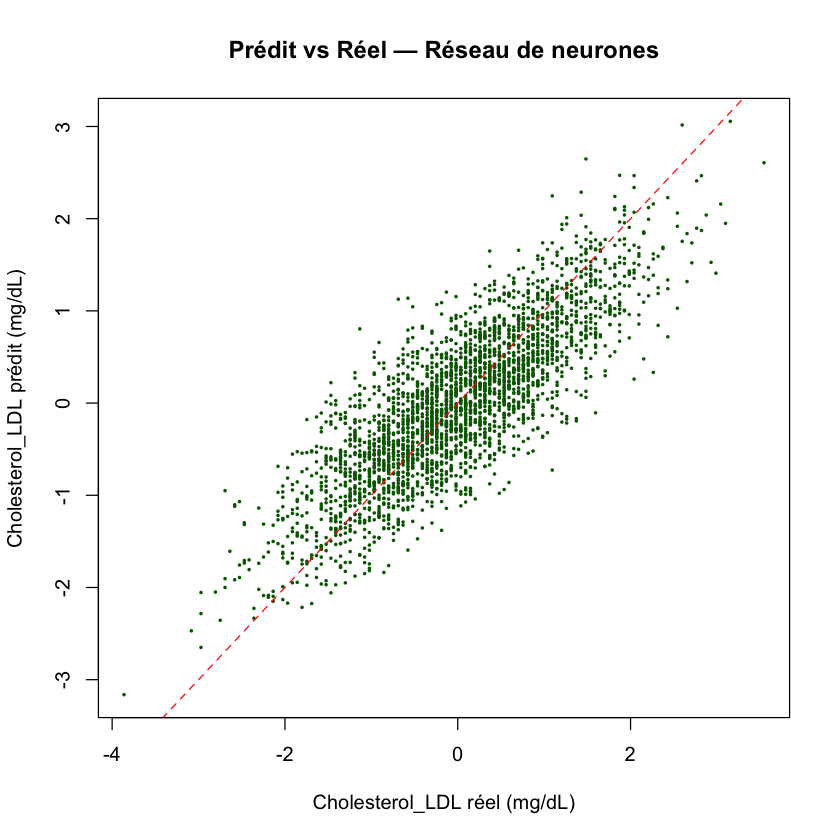

In [ ]:
# Prédictions
pred.reg <- predict(nnet.reg.final, newdata = datestr)
# Valeurs réelles
true.reg <- datestr$Cholesterol_LDL

rmse <- sqrt(mean((pred.reg - true.reg)^2))
sd_ldl <- sd(data[appri, "Cholesterol_LDL"])  # écart-type original
ss_res <- sum((pred.reg - true.reg)^2)
ss_tot <- sum((mean(true.reg) - true.reg)^2)
r2   <- 1 - ss_res / ss_tot

cat("RMSE :", round(rmse* sd_ldl, 4), "mg/dL\n")
cat("R²   :", round(r2,   4), "\n")

# Graphique prédit vs réel
plot(true.reg, pred.reg,
     xlab = "Cholesterol_LDL réel (mg/dL)",
     ylab = "Cholesterol_LDL prédit (mg/dL)",
     main = "Prédit vs Réel — Réseau de neurones",
     col  = "darkgreen", pch = 16, cex = 0.4)
abline(a = 0, b = 1, col = "red", lty = 2)



>Le modèle se trompe en moyenne de 10 mg/dL
>Le modèle explique 68.3% de la variance de Cholesterol_LDL -> modèle acceptable